In [1]:
# Import libraries for data processing, audio analysis, and visualization
import pandas as pd
import numpy as np
import soundfile as sf
import librosa
from pathlib import Path
from collections import Counter
import re
import matplotlib.pyplot as plt

# Jember Javanese Spontaneous Dataset
# These paths point to the metadata and audio files for the Jember dataset
JEMBER_TSV = "Jember Javanese Spontaneous Speech Corpus/Jember Javanese Spontaneous Speech Corpus - 1-200.tsv"
JEMBER_AUDIO_DIR = "Jember Javanese Spontaneous Speech Corpus/mp3 audio"
LANGUAGE = "Javanese"
DATASET_NAME = "Jember Spontaneous"

## 1. Setup and Imports

Import required libraries and configure dataset paths. This cell establishes connection to the Jember Javanese spontaneous speech dataset metadata and audio files.

# Jember Javanese Spontaneous Speech Dataset Analysis

This notebook analyzes the Jember spontaneous Javanese speech dataset. It performs exploratory data analysis including:
- Loading and inspecting dataset structure
- Computing segment durations and statistics
- Text normalization and transcription analysis
- Vocabulary coverage and word frequency analysis
- Speaker and conversation-level statistics
- Data quality checks

In [2]:
# Load the Jember metadata file (TSV format)
# This file contains one row per speech segment with transcriptions, timestamps, speakers, etc.
jember_df = pd.read_csv(JEMBER_TSV, sep="\t")

print(f"{DATASET_NAME} Dataset ({LANGUAGE})")
print(f"Shape: {jember_df.shape}")
print(f"Columns: {jember_df.columns.tolist()}\n")

jember_df.head()

Jember Spontaneous Dataset (Javanese)
Shape: (6679, 4)
Columns: ['Audio file name', 'start', 'end', 'text']



,Audio file name,start,end,text
0,1,0:00:00,0:00:03,Oke. Bismillahirrahmanirrahim.
1,1,0:00:03,0:00:05,"Langsung ae ya, aja suwi-suwi."
2,1,0:00:05,0:00:07,Soale aku sibuk.
3,1,0:00:07,0:00:10,Nèngdi tempat wisata alam populer nèng Indonesia?
4,1,0:00:10,0:00:11,Akèh sih.


## 2. Load Dataset Metadata

Read the Jember metadata TSV file containing segment information (speaker, transcription, timestamps, etc.). Display basic dataset statistics and a preview of the first few rows to understand the data structure.

In [3]:
# Helper function to get duration from audio file metadata
def get_duration(path):
    """Calculate audio duration in seconds from file."""
    try:
        info = sf.info(str(path))
        return info.frames / info.samplerate
    except Exception as e:
        print(f"Error reading {path}: {e}")
        return np.nan

# If dataset has audio filenames, compute their durations
# This gives us actual audio length for each segment
if "audio_filename" in jember_df.columns:
    jember_df["duration_s"] = jember_df["audio_filename"].apply(
        lambda f: get_duration(Path(JEMBER_AUDIO_DIR) / f)
    )
    print("Audio duration statistics:")
    print(jember_df["duration_s"].describe())

## 3. Compute Audio Durations (if audio files available)

If the dataset has audio_filename column, calculate the duration of each audio file using soundfile. This allows us to understand the distribution of segment lengths in the dataset.

In [4]:
# Helper function to parse timestamps in various formats (HH:MM:SS, MM:SS, or just SS)
def parse_ts(ts):
    """Parse timestamp in format HH:MM:SS, MM:SS, or SS."""
    parts = [float(p) for p in str(ts).split(":")]
    if len(parts) == 3: 
        h, m, s = parts
    elif len(parts) == 2: 
        h, m, s = 0, *parts
    else: 
        h, m, s = 0, 0, parts[0]
    return h*3600 + m*60 + s

# Parse segment boundaries if present in the metadata
# This computes duration as (end_timestamp - start_timestamp)
if "start" in jember_df.columns and "end" in jember_df.columns:
    jember_df["start_s"] = jember_df["start"].apply(parse_ts)
    jember_df["end_s"] = jember_df["end"].apply(parse_ts)
    jember_df["duration_s"] = jember_df["end_s"] - jember_df["start_s"]
    
    print("Segment duration statistics:")
    print(jember_df["duration_s"].describe())

Segment duration statistics:
count    6679.000000
mean        5.375954
std         3.352304
min       -30.000000
25%         3.000000
50%         5.000000
75%         7.000000
max        29.000000
Name: duration_s, dtype: float64


## 4. Parse Segment Boundaries (if timestamp-based segmentation)

If the dataset has start/end timestamps (HH:MM:SS format), parse them and compute segment duration. This is used when segments are defined by boundaries within longer audio files rather than as separate audio files.

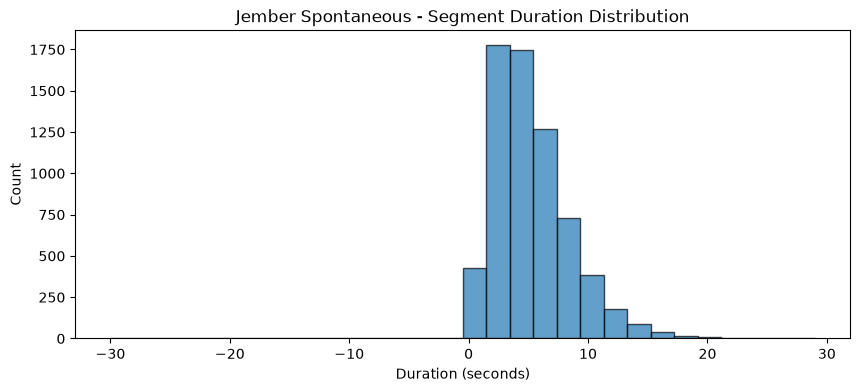


Segment duration analysis:
Total segments: 6679
Mean duration: 5.38s
Median duration: 5.00s
Min: -30.00s, Max: 29.00s


In [5]:
# Visualize the distribution of segment durations
# This histogram shows whether segments cluster in a certain range or are scattered across sizes
if "duration_s" in jember_df.columns:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(jember_df["duration_s"].dropna(), bins=30, edgecolor='black', alpha=0.7)
    ax.set_xlabel("Duration (seconds)")
    ax.set_ylabel("Count")
    ax.set_title(f"{DATASET_NAME} - Segment Duration Distribution")
    plt.show()
    
    # Print summary statistics about segment lengths
    print("\nSegment duration analysis:")
    print(f"Total segments: {len(jember_df)}")
    print(f"Mean duration: {jember_df['duration_s'].mean():.2f}s")
    print(f"Median duration: {jember_df['duration_s'].median():.2f}s")
    print(f"Min: {jember_df['duration_s'].min():.2f}s, Max: {jember_df['duration_s'].max():.2f}s")

## 5. Visualize Segment Duration Distribution

Plot histogram of segment durations to understand how speech segments are distributed in length. This helps identify if there are many very short/long segments which might indicate data quality issues.

In [6]:
# Check language distribution (Jember should be 100% Javanese)
if "language" in jember_df.columns:
    print("Language distribution:")
    print(jember_df["language"].value_counts())
else:
    print(f"Dataset is monolingual: {LANGUAGE}")

# Count and display speakers in the dataset
# More speakers = more speaker diversity, helps test speaker generalization
if "speaker_id" in jember_df.columns or "speaker" in jember_df.columns:
    speaker_col = "speaker_id" if "speaker_id" in jember_df.columns else "speaker"
    print(f"\nUnique speakers: {jember_df[speaker_col].nunique()}")
    print(jember_df[speaker_col].value_counts())

Dataset is monolingual: Javanese


## 6. Language and Speaker Metadata

Check language distribution (should be 100% Javanese) and analyze speaker counts. This helps understand speaker diversity in the dataset.

In [7]:
# Regex patterns for cleaning transcriptions
BRACKET_TAG_RE = re.compile(r"\[[^\]]*\]")  # [laugh], [cough], etc.
UNINTEL_RE = re.compile(r"\(\?\?\?\)")      # (???) for unintelligible
STRIP_PUNCT = ",?¿¡!\";:"                   # punctuation to remove
SENT_END = {".", "!", "?", "—"}             # sentence-ending markers

def handle_ellipses(text):
    """Preserve mid-word ellipses (...) but remove standalone ellipses."""
    protected = []
    def protect(m):
        protected.append(m.group(0))
        return f"\x00{len(protected)-1}\x00"
    text = re.sub(r"(?<=\S)\.{3,}", protect, text)
    text = re.sub(r"(?:(?<=\s)|^)\.{3,}(?=\s|$)", "", text)
    text = text.replace(".", "")
    for i, val in enumerate(protected):
        text = text.replace(f"\x00{i}\x00", val)
    return text

def lowercase_sentence_initial(text):
    """Lowercase the first letter of sentences (common in spontaneous speech)."""
    chars = list(text)
    n = len(chars)
    def is_acronym(i):
        return i+1 < n and chars[i].isupper() and chars[i+1].isupper()
    for i, c in enumerate(chars):
        if c.isalpha():
            if not is_acronym(i):
                chars[i] = c.lower()
            break
    i = 0
    while i < n:
        if chars[i] in SENT_END:
            j = i + 1
            while j < n and chars[j] == " ":
                j += 1
            if j < n and chars[j].isalpha() and not is_acronym(j):
                chars[j] = chars[j].lower()
        i += 1
    return "".join(chars)

def normalize(text):
    """Normalize transcription text: remove annotations, unreadable markers, normalize spacing."""
    if pd.isna(text):
        return ""
    text = BRACKET_TAG_RE.sub("", text)  # [laugh], [cough], etc.
    text = UNINTEL_RE.sub("", text)      # (???)
    text = lowercase_sentence_initial(text)
    text = handle_ellipses(text)
    for ch in STRIP_PUNCT:
        text = text.replace(ch, "")
    return re.sub(r"\s+", " ", text).strip()

# Test normalization on Javanese examples
print(f"Testing {LANGUAGE} text normalization:")
for t in ["aku [laugh] arep budhal (???) saiki.", "iso apa ora? terus piye?", "ya... ya ora ngerti."]:
    print(f"  {repr(t)} -> {repr(normalize(t))}")

Testing Javanese text normalization:
  'aku [laugh] arep budhal (???) saiki.' -> 'aku arep budhal saiki'
  'iso apa ora? terus piye?' -> 'iso apa ora terus piye'
  'ya... ya ora ngerti.' -> 'ya... ya ora ngerti'


## 7. Text Normalization

Define functions to normalize Javanese transcriptions. This removes annotation artifacts (like [laugh], (???)) and standardizes punctuation/capitalization. Critical for clean text analysis and vocabulary building.

In [8]:
# Build word frequency counter from text
def build_vocab(series):
    """Build word frequency counter from text series."""
    counter = Counter()
    for t in series:
        counter.update(normalize(t).split())
    return counter

# Identify which column contains transcription text
text_col = "text" if "text" in jember_df.columns else "transcript"
jember_vocab = build_vocab(jember_df[text_col])

# Display vocabulary statistics
print(f"\n{DATASET_NAME} Vocabulary Analysis")
print(f"Vocabulary size: {len(jember_vocab)} unique words")
print(f"Total words: {sum(jember_vocab.values())}")
print(f"\nMost common words:")
for word, count in jember_vocab.most_common(20):
    print(f"  {word}: {count}")


Jember Spontaneous Vocabulary Analysis
Vocabulary size: 7899 unique words
Total words: 65708

Most common words:
  ya: 2723
  iku: 2680
  ngono: 1452
  aku: 1413
  sing: 1348
  apa: 1198
  kan: 946
  gak: 910
  lèk: 813
  ndèk: 782
  těrus: 757
  kaya: 739
  dadi: 706
  iki: 704
  wis: 663
  e...: 626
  e: 614
  ana: 579
  nèk: 484
  isa: 454


## 8. Build Vocabulary from Transcriptions

Extract all unique words from normalized transcriptions and count their frequencies. This vocabulary will be used to assess data coverage and analyze word distribution patterns in Javanese speech.

In [9]:
# Analyze word frequency distribution to understand vocabulary characteristics
print(f"\n{DATASET_NAME} Vocabulary Coverage:")
print(f"Unique word types: {len(jember_vocab)}")
print(f"Words with freq >= 5: {sum(1 for w in jember_vocab.values() if w >= 5)}")
print(f"Words with freq >= 10: {sum(1 for w in jember_vocab.values() if w >= 10)}")

# Hapax legomena are words that appear only once
# High percentage of hapax may indicate typos, rare words, or transcription errors
hapax = sum(1 for w in jember_vocab.values() if w == 1)
print(f"Hapax legomena (freq=1): {hapax} ({hapax/len(jember_vocab)*100:.1f}%)")

# Show word frequency distribution: how many words appear 1x, 2x, 3x, etc.
print(f"\nWord frequency distribution:")
freq_dist = Counter(jember_vocab.values())
for freq in sorted(freq_dist.keys())[:10]:
    print(f"  Frequency {freq}: {freq_dist[freq]} words")


Jember Spontaneous Vocabulary Coverage:
Unique word types: 7899
Words with freq >= 5: 1561
Words with freq >= 10: 802
Hapax legomena (freq=1): 4160 (52.7%)

Word frequency distribution:
  Frequency 1: 4160 words
  Frequency 2: 1208 words
  Frequency 3: 622 words
  Frequency 4: 348 words
  Frequency 5: 248 words
  Frequency 6: 182 words
  Frequency 7: 133 words
  Frequency 8: 102 words
  Frequency 9: 94 words
  Frequency 10: 72 words


## 9. Analyze Vocabulary Coverage

Compute statistics about word frequency distribution. Identifies rare words (hapax legomena) and computes vocabulary density. High percentage of rare words can indicate typos or annotation errors.

In [10]:
# Detect which columns contain speaker and conversation IDs
# Different metadata formats may use different column names
speaker_col = None
convo_col = None

if "speaker_id" in jember_df.columns:
    speaker_col = "speaker_id"
elif "speaker" in jember_df.columns:
    speaker_col = "speaker"

if "convo_id" in jember_df.columns:
    convo_col = "convo_id"
elif "conversation_id" in jember_df.columns:
    convo_col = "conversation_id"

# Display speaker statistics
# Uneven speaker distribution can bias models
if speaker_col:
    print(f"\nSpeaker Statistics:")
    print(f"Unique speakers: {jember_df[speaker_col].nunique()}")
    print(f"\nSegments per speaker:")
    print(jember_df[speaker_col].value_counts())

# Display conversation statistics
# More conversations = more diverse speaking contexts and topics
if convo_col:
    print(f"\n\nConversation Statistics:")
    print(f"Unique conversations: {jember_df[convo_col].nunique()}")
    print(f"\nSegments per conversation:")
    print(jember_df[convo_col].value_counts())

## 10. Speaker and Conversation Statistics

Analyze how segments are distributed across speakers and conversations. Uneven distribution can bias models toward certain speakers. More conversations = more diverse speaking contexts.

In [11]:
# Detect empty transcriptions (missing or blank text)
text_col = "text" if "text" in jember_df.columns else "transcript"
empty = jember_df[text_col].isna() | (jember_df[text_col].astype(str).str.strip() == "")
print(f"\nData Quality Check:")
print(f"Empty transcriptions: {empty.sum()}/{len(jember_df)} ({empty.sum()/len(jember_df)*100:.1f}%)")

# Compute word count for each segment after normalization
jember_df["word_count"] = jember_df[text_col].fillna("").apply(
    lambda t: len(normalize(t).split()) if normalize(t) else 0
)

# If we have duration info, compute speech rate (words per second)
# Very high speech rates (>5 wps) usually indicate segmentation/transcription errors
if "duration_s" in jember_df.columns:
    jember_df["words_per_sec"] = jember_df["word_count"] / jember_df["duration_s"].replace(0, np.nan)
    
    print(f"\nWord count statistics:")
    print(jember_df["word_count"].describe())
    print(f"\nSpeech rate (words/sec):")
    print(jember_df["words_per_sec"].describe())
    
    # Flag anomalies - high speech rate typically indicates segmentation/transcription errors
    print(f"\nAnomalies - High speech rate (>5 words/sec):")
    anomalies = jember_df[jember_df["words_per_sec"] > 5].sort_values("words_per_sec", ascending=False)
    if len(anomalies) > 0:
        print(anomalies[[text_col, "duration_s", "word_count", "words_per_sec"]].head(10))
    else:
        print("None detected")


Data Quality Check:
Empty transcriptions: 0/6679 (0.0%)



Word count statistics:

count    6679.000000
mean        9.838000
std         5.689646
min         1.000000
25%         6.000000
50%         9.000000
75%        13.000000
max        48.000000
Name: word_count, dtype: float64

Speech rate (words/sec):
count    6641.000000
mean        1.991633
std         0.811252
min        -8.000000
25%         1.500000
50%         2.000000
75%         2.400000
max        10.000000
Name: words_per_sec, dtype: float64

Anomalies - High speech rate (>5 words/sec):
                                                   text  duration_s  \
1471  Ibu pertanyaan yang pertama, kados pundi kegia...         1.0   
2036                     Ya, kan lèk urip ning omah ya,         1.0   
388                Wah, wis otomatis tuku ndèk anu aku.         1.0   
276                      Sik, sik akèh digae ndèk kene.         1.0   
2105                  Ya, wis nggak usah ngomong ngono.         1.0   
6129                    Těrus mudune iku pisan ya sara.         1.0   
5837                    Ik

## 11. Data Quality Checks

Identify transcription issues: empty transcriptions, unusually high speech rates (indicating segmentation errors), and outliers. These quality metrics help diagnose potential problems in the dataset.

In [12]:
# Print comprehensive dataset summary
# This serves as a quick reference for the dataset's characteristics
print(f"\n{'='*60}")
print(f"{DATASET_NAME} Dataset Summary")
print(f"{'='*60}")
print(f"Language: {LANGUAGE}")
print(f"Total segments: {len(jember_df)}")
print(f"Total vocabulary: {len(jember_vocab)} unique words")
print(f"Total word tokens: {sum(jember_vocab.values())}")

# Audio duration info if available
if "duration_s" in jember_df.columns:
    total_duration = jember_df["duration_s"].sum()
    hours = total_duration / 3600
    print(f"Total audio duration: {total_duration:.1f}s ({hours:.2f} hours)")

# Speaker info if available
if speaker_col:
    print(f"Number of speakers: {jember_df[speaker_col].nunique()}")
# Conversation info if available
if convo_col:
    print(f"Number of conversations: {jember_df[convo_col].nunique()}")
    
print(f"{'='*60}")


Jember Spontaneous Dataset Summary
Language: Javanese
Total segments: 6679
Total vocabulary: 7899 unique words
Total word tokens: 65708
Total audio duration: 35906.0s (9.97 hours)


## 12. Dataset Summary

Generate a comprehensive summary of the Jember Javanese spontaneous speech dataset. This provides a high-level overview of dataset size, coverage, and composition that can be used for documentation and comparison with other datasets.

---

# Part 2 — Competition-Targeted EDA

Part 1 characterised the Jember training corpus in isolation. That is not the question the
competition asks. The competition scores us on the **hidden test set**, and our only honest proxy
for it is the **official development set** (`indonesian_dev/`), which is drawn from the same
underlying collection.

So every analysis below is framed as one question:

> **How is Jember (what we train on) different from the dev set (what we are scored on),
> and what does each difference cost us in Word Error Rate?**

Sections:

| # | Section | Question it answers |
|---|---------|---------------------|
| 13 | Scorer-compatible normaliser | Are we measuring what the organisers measure? |
| 14 | Dev set load + audio probe | What does the target distribution actually look like? |
| 15 | Jember integrity audit | Which training rows are broken? |
| 16 | Duration domain gap | Do our training clips look like test clips? |
| 17 | Re-segmentation simulation | Can we close that gap for free? |
| 18 | Vocabulary & OOV | What is our lexical ceiling? |
| 19 | Orthography / diacritics | Are we spelling words the way the scorer expects? |
| 20 | Disfluency & markup | Do we model conversational phenomena? |
| 21 | Casing & acronyms | Are we losing points to capitalisation? |
| 22 | Whisper 30s window | Will long clips be silently truncated? |
| 23 | Synthesis | What does all of this mean, and what do we do? |

## 13. Scorer-Compatible Text Normalisation

WER is computed **after** normalisation, so the normaliser *is* part of the metric. Section 8 of the
project brief specifies the official behaviour. The subtle part, and the part most teams get wrong:

> The normaliser **does not simply lowercase everything.** It lowercases only *sentence-initial*
> letters, protects acronyms, and keeps word-attached ellipses because they encode disfluency.

Casing everywhere else is compared **as written**. That means `SMP` vs `smp` is a substitution error.
We re-implement it here as `wer_norm()` and use it for every measurement in Part 2, so our local
numbers move in the same direction as the leaderboard.

In [13]:
import unicodedata
from collections import Counter, defaultdict

BRACKET_TAG_RE = re.compile(r"\[[^\]]*\]")            # [laugh], [cough]
UNINTEL_RE     = re.compile(r"\(\?\?\?\)|\[\?\?\?\]")  # (???) and [???]
SCORER_PUNCT   = ',?¿¡!";:'                  # removed by the official scorer
SENT_END       = {".", "!", "?", "\u2014"}

def _is_acronym(chars, i):
    """Two or more consecutive capitals => acronym, protected from lowercasing."""
    n = len(chars)
    return i + 1 < n and chars[i].isupper() and chars[i + 1].isupper()

def _lowercase_sentence_initial(text):
    chars, n = list(text), len(text)
    for i, c in enumerate(chars):            # first alphabetic char of the transcript
        if c.isalpha():
            if not _is_acronym(chars, i):
                chars[i] = c.lower()
            break
    for i in range(n):                       # first alphabetic char after . ! ? em-dash
        if chars[i] in SENT_END:
            j = i + 1
            while j < n and chars[j] == " ":
                j += 1
            if j < n and chars[j].isalpha() and not _is_acronym(chars, j):
                chars[j] = chars[j].lower()
    return "".join(chars)

def _handle_ellipses(text):
    """Keep word-attached ellipses (disfluency), drop standalone ones and all other periods."""
    kept = []
    def protect(m):
        kept.append(m.group(0))
        return f"\x00{len(kept)-1}\x00"
    text = re.sub(r"(?<=\S)\.{3,}", protect, text)
    text = re.sub(r"(?:(?<=\s)|^)\.{3,}(?=\s|$)", "", text)
    text = text.replace(".", "")
    for i, v in enumerate(kept):
        text = text.replace(f"\x00{i}\x00", v)
    return text

def wer_norm(text):
    """Approximation of the official competition normaliser."""
    if pd.isna(text):
        return ""
    t = BRACKET_TAG_RE.sub("", str(t_ := text))
    t = UNINTEL_RE.sub("", t)
    t = _lowercase_sentence_initial(t)
    t = _handle_ellipses(t)
    for ch in SCORER_PUNCT:
        t = t.replace(ch, "")
    return re.sub(r"\s+", " ", t).strip()

def toks(text):
    return wer_norm(text).split()

# Sanity checks that encode the tricky rules explicitly
checks = [
    ("Aku [laugh] arep budhal (???) saiki.", "casing + tags + trailing period"),
    ("SMP iku angel. Aku ora ngerti.",       "SMP must stay uppercase; 'Aku' after '.' lowercased"),
    ("ya... ya e... ora ngerti",             "word-attached ellipsis kept, standalone dropped"),
]
print("Scorer normalisation checks")
for raw, why in checks:
    print(f"  {why}\n    in : {raw!r}\n    out: {wer_norm(raw)!r}")


Scorer normalisation checks
  casing + tags + trailing period
    in : 'Aku [laugh] arep budhal (???) saiki.'
    out: 'aku arep budhal saiki'
  SMP must stay uppercase; 'Aku' after '.' lowercased
    in : 'SMP iku angel. Aku ora ngerti.'
    out: 'SMP iku angel aku ora ngerti'
  word-attached ellipsis kept, standalone dropped
    in : 'ya... ya e... ora ngerti'
    out: 'ya... ya e... ora ngerti'


### Word Error Rate

We implement WER by Levenshtein alignment over normalised tokens. It is the objective, so we want it
available from the first cell onward — including the per-language breakdown the brief insists on.

In [14]:
def wer_counts(ref, hyp):
    """Levenshtein alignment over token lists -> (substitutions, deletions, insertions, n_ref)."""
    r, h = toks(ref), toks(hyp)
    n, m = len(r), len(h)
    # d[i][j] = (cost, sub, del, ins)
    d = [[(0, 0, 0, 0)] * (m + 1) for _ in range(n + 1)]
    for i in range(1, n + 1):
        d[i][0] = (i, 0, i, 0)
    for j in range(1, m + 1):
        d[0][j] = (j, 0, 0, j)
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if r[i - 1] == h[j - 1]:
                d[i][j] = d[i - 1][j - 1]
            else:
                c_s, c_d, c_i = d[i-1][j-1][0], d[i-1][j][0], d[i][j-1][0]
                best = min(c_s, c_d, c_i)
                if best == c_s:
                    p = d[i-1][j-1]; d[i][j] = (best + 1, p[1] + 1, p[2], p[3])
                elif best == c_d:
                    p = d[i-1][j];   d[i][j] = (best + 1, p[1], p[2] + 1, p[3])
                else:
                    p = d[i][j-1];   d[i][j] = (best + 1, p[1], p[2], p[3] + 1)
    s, dl, ins = d[n][m][1], d[n][m][2], d[n][m][3]
    return s, dl, ins, n

def wer(refs, hyps):
    """Corpus-level WER: total edits / total reference words (NOT the mean of per-clip WERs)."""
    S = D = I = N = 0
    for r, h in zip(refs, hyps):
        s, dl, i_, n = wer_counts(r, h)
        S += s; D += dl; I += i_; N += n
    return (S + D + I) / N if N else float("nan"), dict(sub=S, dele=D, ins=I, n_ref=N)

# Verify against the example in the brief: "running" vs "run" is one substitution.
print("WER('running','run') =", wer(["running"], ["run"])[0], "(expected 1.0)")
print("WER identical        =", wer(["aku arep budhal"], ["aku arep budhal"])[0], "(expected 0.0)")
print("WER one deletion     =", round(wer(["aku arep budhal"], ["aku arep"])[0], 4), "(expected 0.3333)")


WER('running','run') = 1.0 (expected 1.0)
WER identical        = 0.0 (expected 0.0)
WER one deletion     = 0.3333 (expected 0.3333)


## 14. Load the Official Development Set

The dev set is **validation only** — never training data. It is our single best estimate of the
hidden test distribution, so we characterise it carefully.

The brief describes three `language` values (`jav`, `ind`, `javind`). The first thing worth checking
is whether all three actually appear.

In [15]:
DEV_DIR   = Path("indonesian_dev")
DEV_TSV   = DEV_DIR / "metadata.tsv"
DEV_CLIPS = DEV_DIR / "clips"

dev_df = pd.read_csv(DEV_TSV, sep="\t")
print(f"Development set: {dev_df.shape[0]} clips, columns = {dev_df.columns.tolist()}")

print("\nLanguage distribution (the label the brief tells us to break WER down by):")
lang_counts = dev_df["language"].value_counts()
for lang, n in lang_counts.items():
    print(f"  {lang:8s} {n:4d} clips  ({n/len(dev_df)*100:5.1f}%)")

for expected in ["jav", "ind", "javind"]:
    if expected not in lang_counts.index:
        print(f"  {expected:8s}    0 clips  (  0.0%)   <-- ABSENT from the dev set")

print("\nSpeakers x language:")
print(pd.crosstab(dev_df["speaker"], dev_df["language"]))
print("\nConversations x language:")
print(pd.crosstab(dev_df["convo_id"], dev_df["language"]))


Development set: 372 clips, columns = ['audio_filename', 'speaker', 'transcript', 'language', 'convo_id']

Language distribution (the label the brief tells us to break WER down by):
  javind    352 clips  ( 94.6%)
  ind        20 clips  (  5.4%)
  jav         0 clips  (  0.0%)   <-- ABSENT from the dev set

Speakers x language:
language  ind  javind
speaker              
1           0     140
5           7      27
6           0     154
7          13      31

Conversations x language:
language  ind  javind
convo_id             
2          20      58
5           0     294


### Probe every dev clip's audio

Sample rate, channel count and duration drive the whole preprocessing contract. We read them from
the files rather than trusting the brief.

In [16]:
def probe(path):
    """Return (duration_s, samplerate, channels) or NaNs if unreadable."""
    try:
        i = sf.info(str(path))
        return i.frames / i.samplerate, i.samplerate, i.channels
    except Exception:
        return np.nan, np.nan, np.nan

probes = [probe(DEV_CLIPS / f) for f in dev_df["audio_filename"]]
dev_df[["duration_s", "sr", "channels"]] = pd.DataFrame(probes, index=dev_df.index)

dev_df["n_words"] = dev_df["transcript"].apply(lambda t: len(toks(t)))
dev_df["wps"]     = dev_df["n_words"] / dev_df["duration_s"]

print("DEV AUDIO")
print(f"  unreadable clips : {dev_df['duration_s'].isna().sum()}")
print(f"  sample rates     : {dev_df['sr'].value_counts().to_dict()}")
print(f"  channels         : {dev_df['channels'].value_counts().to_dict()}")
print(f"  total duration   : {dev_df['duration_s'].sum()/3600:.2f} h")
print(f"  duration  mean {dev_df['duration_s'].mean():5.1f}s  median {dev_df['duration_s'].median():5.1f}s  "
      f"min {dev_df['duration_s'].min():4.1f}s  max {dev_df['duration_s'].max():5.1f}s")
print(f"  reference words  : {dev_df['n_words'].sum():,}  (this is the WER denominator)")
print(f"  words/clip  mean {dev_df['n_words'].mean():.1f}  median {dev_df['n_words'].median():.0f}")
print(f"  speech rate mean {dev_df['wps'].mean():.2f} w/s")

print("\nOne WER point on this dev set is worth "
      f"{dev_df['n_words'].sum()/100:.0f} word errors -- small changes are noisy.")


DEV AUDIO
  unreadable clips : 0
  sample rates     : {48000: 372}
  channels         : {1: 372}
  total duration   : 2.56 h
  duration  mean  24.8s  median  26.2s  min  6.3s  max  37.8s
  reference words  : 17,473  (this is the WER denominator)
  words/clip  mean 47.0  median 48
  speech rate mean 1.89 w/s

One WER point on this dev set is worth 175 word errors -- small changes are noisy.


## 15. Jember Integrity Audit

Before we train on 6,679 rows we need to know how many are actually usable. We check timestamp
validity, timestamp *resolution*, overruns past the end of the audio, and the true sample-rate mix.

In [17]:
JEMBER_AUDIO = Path(JEMBER_AUDIO_DIR)

# --- audio file inventory -------------------------------------------------
jember_files = {}
unreadable   = []
for p in sorted(JEMBER_AUDIO.glob("*.mp3")):
    dur, sr, ch = probe(p)
    if np.isnan(dur):
        unreadable.append(p.name)
    else:
        jember_files[int(p.stem)] = (dur, sr, ch)

file_sr = pd.Series({k: v[1] for k, v in jember_files.items()})
file_ch = pd.Series({k: v[2] for k, v in jember_files.items()})
file_du = pd.Series({k: v[0] for k, v in jember_files.items()})

print("JEMBER AUDIO FILES")
print(f"  sessions on disk : {len(jember_files)}   unreadable: {len(unreadable)}")
print(f"  sample rates     : {file_sr.value_counts().to_dict()}   <-- brief claims 44.1 kHz only")
print(f"  channels         : {file_ch.value_counts().to_dict()}")
print(f"  total audio      : {file_du.sum()/3600:.2f} h")
print(f"  session length   : median {file_du.median():.0f}s  max {file_du.max():.0f}s")

# --- timestamp integrity --------------------------------------------------
jember_df["file_duration_s"] = jember_df["Audio file name"].map(lambda k: jember_files.get(k, (np.nan,))[0])
jember_df["overrun_s"]       = jember_df["end_s"] - jember_df["file_duration_s"]

neg   = jember_df["duration_s"] < 0
zero  = jember_df["duration_s"] == 0
tiny  = (jember_df["duration_s"] > 0) & (jember_df["duration_s"] < 0.5)
over  = jember_df["overrun_s"] > 0.5
blank = jember_df["text"].fillna("").str.strip() == ""

print("\nSEGMENT INTEGRITY (of %d rows)" % len(jember_df))
for label, mask in [("negative duration (end < start)", neg), ("zero duration", zero),
                    ("< 0.5 s", tiny), ("end beyond file length", over), ("blank transcript", blank)]:
    print(f"  {label:34s} {mask.sum():4d}")

bad_rows = neg | zero | blank
print(f"  --> unusable rows: {bad_rows.sum()} ({bad_rows.sum()/len(jember_df)*100:.2f}%), "
      f"{(~bad_rows).sum()} usable")

# --- timestamp resolution -------------------------------------------------
frac = ((jember_df["start_s"] % 1 != 0).sum() + (jember_df["end_s"] % 1 != 0).sum())
print(f"\nTIMESTAMP RESOLUTION")
print(f"  non-integer timestamp values: {frac} / {2*len(jember_df)}")
print(f"  --> timestamps are quantised to WHOLE SECONDS: {frac == 0}")

# --- missing / orphan sessions -------------------------------------------
referenced = set(jember_df["Audio file name"]); on_disk = set(jember_files)
print(f"\n  sessions referenced but missing : {sorted(referenced - on_disk) or 'none'}")
print(f"  audio files never referenced    : {sorted(on_disk - referenced) or 'none'}")

jember_clean = jember_df[~bad_rows].copy()
print(f"\njember_clean: {len(jember_clean)} segments, {jember_clean['duration_s'].sum()/3600:.2f} h")


JEMBER AUDIO FILES
  sessions on disk : 208   unreadable: 0
  sample rates     : {48000: 119, 44100: 89}   <-- brief claims 44.1 kHz only
  channels         : {1: 208}
  total audio      : 10.03 h
  session length   : median 100s  max 1203s

SEGMENT INTEGRITY (of 6679 rows)
  negative duration (end < start)       3
  zero duration                        38
  < 0.5 s                               0
  end beyond file length                4
  blank transcript                      0
  --> unusable rows: 41 (0.61%), 6638 usable

TIMESTAMP RESOLUTION
  non-integer timestamp values: 0 / 13358
  --> timestamps are quantised to WHOLE SECONDS: True

  sessions referenced but missing : none
  audio files never referenced    : none

jember_clean: 6638 segments, 9.98 h


### Why whole-second timestamps matter

Every Jember boundary is rounded to a whole second, but the brief says the corpus was segmented by
hand. A boundary can therefore sit up to ~0.5 s away from the true speech edge in either direction —
cutting the first or last syllable off a word, or pulling in a neighbouring one.

At a median segment length of 5 s, a ±0.5 s error is **10% of the clip**. This is the strongest
argument for the re-segmentation strategy in Section 17: merging adjacent segments moves every
boundary error to the *outside* of a much longer chunk, where it is proportionally negligible.

In [18]:
edge_risk = 0.5 / jember_clean["duration_s"]
print("Boundary error as a share of clip length (assuming +/-0.5 s rounding):")
print(f"  median clip: {edge_risk.median()*100:5.1f}% of the clip is boundary-uncertain")
print(f"  clips where +/-0.5s exceeds 10% of the clip: "
      f"{(edge_risk > 0.10).sum():4d} ({(edge_risk > 0.10).mean()*100:.1f}%)")
print(f"  clips <= 2 s (severe risk): {(jember_clean['duration_s'] <= 2).sum()} "
      f"({(jember_clean['duration_s'] <= 2).mean()*100:.1f}%)")


Boundary error as a share of clip length (assuming +/-0.5 s rounding):
  median clip:  10.0% of the clip is boundary-uncertain
  clips where +/-0.5s exceeds 10% of the clip: 3095 (46.6%)
  clips <= 2 s (severe risk): 1182 (17.8%)


## 16. The Duration Domain Gap

This is the first of the three big mismatches. Whisper — and any encoder-decoder ASR model — behaves
differently on a 5-second clip than on a 26-second one: attention spans, decoder length priors, and
repetition dynamics all change with input length.

If we fine-tune on 5-second clips and infer on 26-second clips, we are testing the model
**out of distribution on the axis it is most sensitive to**.

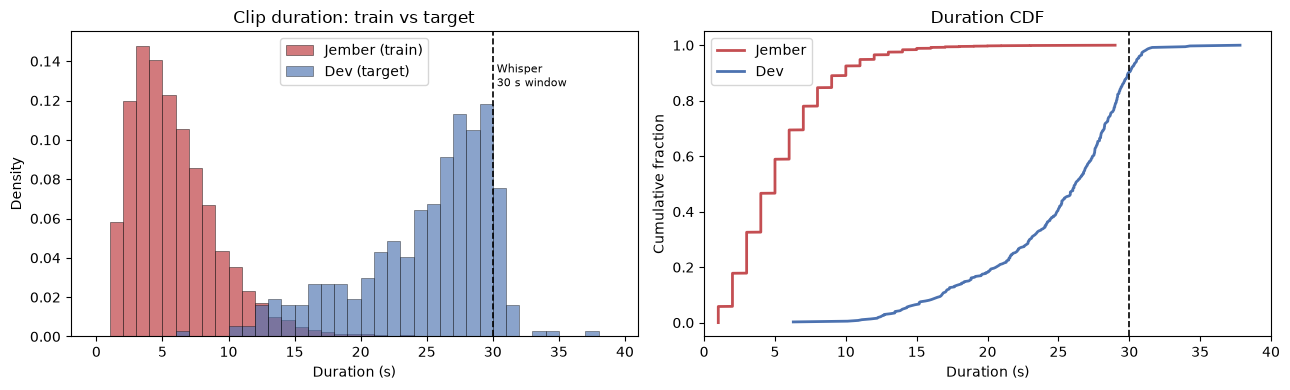

                           Jember        Dev
mean duration (s)            5.42      24.79
median duration (s)          5.00      26.21
mean words/clip              9.88      46.97
mean words/second            1.99       1.89

Share of Jember clips inside the dev duration band (15-32 s): 1.6%
Share of dev clips in that band:                              92.7%
Dev median / Jember median = 5.2x


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(jember_clean["duration_s"], bins=np.arange(0, 40, 1),
             alpha=.75, color="#c44e52", edgecolor="black", linewidth=.4, density=True, label="Jember (train)")
axes[0].hist(dev_df["duration_s"].dropna(), bins=np.arange(0, 40, 1),
             alpha=.65, color="#4c72b0", edgecolor="black", linewidth=.4, density=True, label="Dev (target)")
axes[0].axvline(30, color="black", ls="--", lw=1.2)
axes[0].text(30.3, axes[0].get_ylim()[1]*.82, "Whisper\n30 s window", fontsize=8)
axes[0].set_xlabel("Duration (s)"); axes[0].set_ylabel("Density")
axes[0].set_title("Clip duration: train vs target"); axes[0].legend()

for lbl, s, c in [("Jember", jember_clean["duration_s"], "#c44e52"),
                  ("Dev", dev_df["duration_s"].dropna(), "#4c72b0")]:
    xs = np.sort(s.values)
    axes[1].plot(xs, np.arange(1, len(xs)+1)/len(xs), label=lbl, color=c, lw=2)
axes[1].axvline(30, color="black", ls="--", lw=1.2)
axes[1].set_xlabel("Duration (s)"); axes[1].set_ylabel("Cumulative fraction")
axes[1].set_title("Duration CDF"); axes[1].legend(); axes[1].set_xlim(0, 40)
plt.tight_layout(); plt.show()

print(f"{'':22s} {'Jember':>10s} {'Dev':>10s}")
for label, a, b in [
    ("mean duration (s)",   jember_clean['duration_s'].mean(),   dev_df['duration_s'].mean()),
    ("median duration (s)", jember_clean['duration_s'].median(), dev_df['duration_s'].median()),
    ("mean words/clip",     jember_clean['word_count'].mean(),   dev_df['n_words'].mean()),
    ("mean words/second",   (jember_clean['word_count']/jember_clean['duration_s']).mean(), dev_df['wps'].mean()),
]:
    print(f"{label:22s} {a:10.2f} {b:10.2f}")

overlap = ((jember_clean["duration_s"] >= 15) & (jember_clean["duration_s"] <= 32)).mean()
print(f"\nShare of Jember clips inside the dev duration band (15-32 s): {overlap*100:.1f}%")
print(f"Share of dev clips in that band:                              "
      f"{((dev_df['duration_s']>=15)&(dev_df['duration_s']<=32)).mean()*100:.1f}%")
print(f"Dev median / Jember median = {dev_df['duration_s'].median()/jember_clean['duration_s'].median():.1f}x")


## 17. Re-Segmentation: Closing the Gap for Free

The fix depends on one empirical question: **are Jember's segments contiguous?** If consecutive
segments in a session are back-to-back with no gaps, we can concatenate them into longer
pseudo-utterances whose transcripts are simply the concatenated texts — no new labelling, no new
audio, no loss of data.

We measure the gaps, then simulate the merge.

GAPS BETWEEN CONSECUTIVE SEGMENTS
  n = 6430   median = 0.00s   mean = -0.00s
  exactly zero : 100.0%
  <= 1 s       : 100.0%
  negative (overlap): 2
  --> segments are contiguous, so merging is lossless



MERGED PSEUDO-UTTERANCES
  count      : 1473  (from 6638 raw segments)
  total audio: 9.98 h  (raw: 9.98 h -- nothing lost)
  duration   : mean 24.4s  median 26.0s
  words/clip : mean 44.5  median 46
  segs merged per chunk: median 4

Share inside the dev duration band (15-32 s)
  raw Jember      :   1.6%
  merged Jember   :  92.5%
  dev (target)    :  92.7%

merged median 26.0s  vs  dev median 26.2s
merged mean   24.4s  vs  dev mean   24.8s


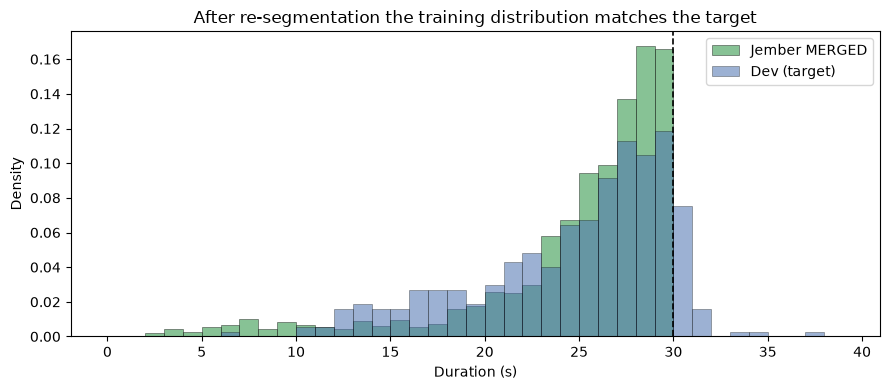

In [20]:
seg = jember_clean.sort_values(["Audio file name", "start_s"])
gaps = []
for _, g in seg.groupby("Audio file name"):
    gaps.extend((g["start_s"].values[1:] - g["end_s"].values[:-1]).tolist())
gaps = np.array(gaps)

print("GAPS BETWEEN CONSECUTIVE SEGMENTS")
print(f"  n = {len(gaps)}   median = {np.median(gaps):.2f}s   mean = {gaps.mean():.2f}s")
print(f"  exactly zero : {(gaps == 0).mean()*100:.1f}%")
print(f"  <= 1 s       : {(gaps <= 1).mean()*100:.1f}%")
print(f"  negative (overlap): {(gaps < 0).sum()}")
print("  --> segments are contiguous, so merging is lossless\n")

def merge_segments(df, max_dur=29.0, max_gap=1.0):
    """Concatenate consecutive same-session segments into <=max_dur pseudo-utterances."""
    out = []
    for sess, g in df.sort_values(["Audio file name", "start_s"]).groupby("Audio file name"):
        cs = ce = None; parts = []
        for s, e, t in zip(g["start_s"], g["end_s"], g["text"]):
            if cs is None:
                cs, ce, parts = s, e, [str(t)]
            elif (e - cs) <= max_dur and (s - ce) <= max_gap:
                ce = e; parts.append(str(t))
            else:
                out.append((sess, cs, ce, ce - cs, " ".join(parts), len(parts)))
                cs, ce, parts = s, e, [str(t)]
        if cs is not None:
            out.append((sess, cs, ce, ce - cs, " ".join(parts), len(parts)))
    return pd.DataFrame(out, columns=["session", "start_s", "end_s", "duration_s", "text", "n_source_segs"])

merged = merge_segments(jember_clean)
merged["n_words"] = merged["text"].apply(lambda t: len(toks(t)))

print("MERGED PSEUDO-UTTERANCES")
print(f"  count      : {len(merged)}  (from {len(jember_clean)} raw segments)")
print(f"  total audio: {merged['duration_s'].sum()/3600:.2f} h  (raw: {jember_clean['duration_s'].sum()/3600:.2f} h -- nothing lost)")
print(f"  duration   : mean {merged['duration_s'].mean():.1f}s  median {merged['duration_s'].median():.1f}s")
print(f"  words/clip : mean {merged['n_words'].mean():.1f}  median {merged['n_words'].median():.0f}")
print(f"  segs merged per chunk: median {merged['n_source_segs'].median():.0f}")

band = lambda s: ((s >= 15) & (s <= 32)).mean() * 100
print(f"\nShare inside the dev duration band (15-32 s)")
print(f"  raw Jember      : {band(jember_clean['duration_s']):5.1f}%")
print(f"  merged Jember   : {band(merged['duration_s']):5.1f}%")
print(f"  dev (target)    : {band(dev_df['duration_s'].dropna()):5.1f}%")
print(f"\nmerged median {merged['duration_s'].median():.1f}s  vs  dev median {dev_df['duration_s'].median():.1f}s")
print(f"merged mean   {merged['duration_s'].mean():.1f}s  vs  dev mean   {dev_df['duration_s'].mean():.1f}s")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(merged["duration_s"], bins=np.arange(0, 40, 1), alpha=.7, density=True,
        color="#55a868", edgecolor="black", linewidth=.4, label="Jember MERGED")
ax.hist(dev_df["duration_s"].dropna(), bins=np.arange(0, 40, 1), alpha=.55, density=True,
        color="#4c72b0", edgecolor="black", linewidth=.4, label="Dev (target)")
ax.axvline(30, color="black", ls="--", lw=1.2)
ax.set_xlabel("Duration (s)"); ax.set_ylabel("Density")
ax.set_title("After re-segmentation the training distribution matches the target")
ax.legend(); plt.tight_layout(); plt.show()


## 18. Vocabulary and the OOV Ceiling

A word the model has never seen in fine-tuning is a word it will probably get wrong. The share of
dev tokens absent from the Jember vocabulary is therefore a rough **floor** on achievable WER from
Jember-only training — softened by Whisper's multilingual pretraining, which already knows a lot of
Indonesian, but real.

This is also where we find out *which language* each corpus actually is.

VOCABULARY
  Jember :  7,890 types    65,614 tokens
  Dev    :  3,273 types    17,473 tokens
  shared :  1,353 types  (41.3% of dev types)

  DEV TOKEN COVERAGE by Jember vocabulary : 78.6%
  OOV token rate (approx. lexical WER floor): 21.4%
  OOV: 1,920 types / 3,734 tokens

Most frequent words -- note which LANGUAGE each corpus is:
  Jember: ['ya', 'iku', 'ngono', 'aku', 'sing', 'apa', 'kan', 'gak', 'lèk', 'ndèk', 'těrus', 'kaya', 'dadi', 'iki', 'wis', 'e...', 'e', 'ana']
  Dev   : ['ya', 'aku', 'itu', 'yang', 'jadi', 'di', 'dan', 'gitu', 'terus', 'juga', 'nah', 'tuh', 'ada', 'kayak', 'banget', 'ini', 'gak', 'pas']

Function-word signature (share of all tokens):
               Javanese   Indonesian
  Jember         21.57%        3.13%
  Dev             5.23%       15.21%

Top dev words MISSING from Jember (each is a likely error):
   ['terus', 'kayaknya', 'suka', 'PR', 'ngerjain', "'kan", 'kui', 'soalnya', 'yo', 'sendiri', 'bareng', 'seneng', 'ono', 'iso', 'pergi', 'ataupun', 'dapat'

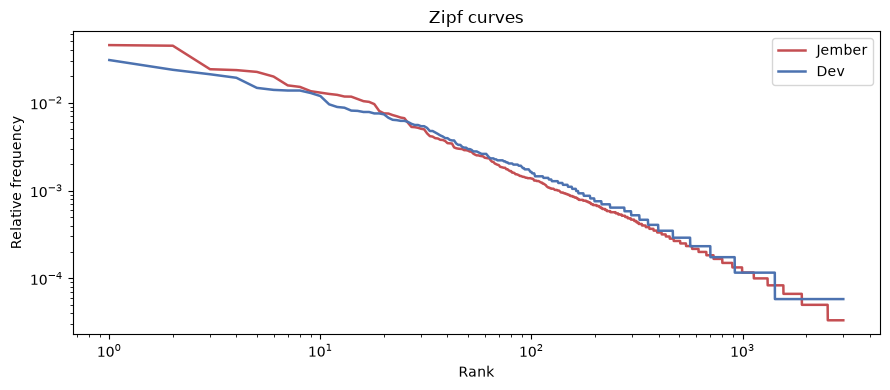

In [21]:
jember_vocab_c = Counter()
for t in jember_clean["text"]:
    jember_vocab_c.update(toks(t))
dev_vocab_c = Counter()
for t in dev_df["transcript"]:
    dev_vocab_c.update(toks(t))

j_tok, d_tok = sum(jember_vocab_c.values()), sum(dev_vocab_c.values())
shared = set(jember_vocab_c) & set(dev_vocab_c)
covered = sum(c for w, c in dev_vocab_c.items() if w in jember_vocab_c)
oov = Counter({w: c for w, c in dev_vocab_c.items() if w not in jember_vocab_c})

print("VOCABULARY")
print(f"  Jember : {len(jember_vocab_c):6,d} types   {j_tok:7,d} tokens")
print(f"  Dev    : {len(dev_vocab_c):6,d} types   {d_tok:7,d} tokens")
print(f"  shared : {len(shared):6,d} types  ({len(shared)/len(dev_vocab_c)*100:.1f}% of dev types)")
print(f"\n  DEV TOKEN COVERAGE by Jember vocabulary : {covered/d_tok*100:.1f}%")
print(f"  OOV token rate (approx. lexical WER floor): {100-covered/d_tok*100:.1f}%")
print(f"  OOV: {len(oov):,} types / {sum(oov.values()):,} tokens")

print("\nMost frequent words -- note which LANGUAGE each corpus is:")
jt = [w for w, _ in jember_vocab_c.most_common(18)]
dt = [w for w, _ in dev_vocab_c.most_common(18)]
print(f"  Jember: {jt}")
print(f"  Dev   : {dt}")

# Function words are the fingerprint of the matrix language of a corpus.
JAV = {"iku","sing","ngono","lèk","nèk","ndèk","iki","wis","ana","ora","aku","kowe","dhewe",
       "isa","iso","opo","apa","karo","neng","nèng","yo","kui","ono","meneh","akeh","akèh","kabeh","kabèh"}
IND = {"itu","yang","jadi","di","dan","ini","ada","tidak","saya","kamu","sendiri","bisa",
       "apa","dengan","ke","juga","sudah","akan","untuk","dari","pada","lagi","banyak","semua"}
def share(counter, lex):
    tot = sum(counter.values())
    return sum(c for w, c in counter.items() if w.lower() in lex) / tot * 100
print("\nFunction-word signature (share of all tokens):")
print(f"  {'':10s} {'Javanese':>10s} {'Indonesian':>12s}")
print(f"  {'Jember':10s} {share(jember_vocab_c, JAV):9.2f}% {share(jember_vocab_c, IND):11.2f}%")
print(f"  {'Dev':10s} {share(dev_vocab_c, JAV):9.2f}% {share(dev_vocab_c, IND):11.2f}%")

print("\nTop dev words MISSING from Jember (each is a likely error):")
print("  ", [w for w, _ in oov.most_common(30)])

fig, ax = plt.subplots(figsize=(9, 4))
ranks = np.arange(1, 3001)
for lbl, c, col in [("Jember", jember_vocab_c, "#c44e52"), ("Dev", dev_vocab_c, "#4c72b0")]:
    freqs = np.array([f for _, f in c.most_common(3000)], dtype=float)
    ax.loglog(ranks[:len(freqs)], freqs/freqs.sum(), label=lbl, color=col, lw=1.8)
ax.set_xlabel("Rank"); ax.set_ylabel("Relative frequency")
ax.set_title("Zipf curves"); ax.legend(); plt.tight_layout(); plt.show()


## 19. Orthography — the Diacritic Trap

This is the single most dangerous finding in the dataset, and it is invisible unless you look for it.

Jember was transcribed by linguists using **scholarly Javanese orthography**, which marks the vowels
*pepet* and *taling* with `ê` and `è`. The dev set — and therefore the hidden test set — is
transcribed in **everyday Indonesian spelling**, which does not use those marks at all.

If we fine-tune on raw Jember text, the model learns to emit `těrus`, `lèk`, `bangêt`. The scorer
compares those against `terus`, `lek`, `banget` and counts **every one as a substitution.**

In [22]:
def strip_diacritics(w):
    return "".join(c for c in unicodedata.normalize("NFD", w) if unicodedata.category(c) != "Mn")

def diacritic_marks(counter):
    return Counter(c for w in counter for c in unicodedata.normalize("NFD", w)
                   if unicodedata.category(c) == "Mn")

for name, c in [("Jember", jember_vocab_c), ("Dev", dev_vocab_c)]:
    dia_types = [w for w in c if strip_diacritics(w) != w]
    dia_tok   = sum(c[w] for w in dia_types)
    tot       = sum(c.values())
    print(f"{name}")
    print(f"  types with diacritics : {len(dia_types):5,d} ({len(dia_types)/len(c)*100:5.2f}%)")
    print(f"  TOKENS with diacritics: {dia_tok:5,d} ({dia_tok/tot*100:5.2f}%)   <-- share of output at risk")
    marks = diacritic_marks(c)
    pretty = {unicodedata.name(m, '?').replace('COMBINING ', '').title(): n for m, n in marks.most_common(5)}
    print(f"  marks used            : {pretty}")
    print(f"  examples              : {sorted(dia_types, key=lambda w: -c[w])[:10]}\n")

# What does normalising the training text buy us?
print("Effect of orthographic normalisation on dev OOV rate")
variants = {
    "raw Jember text": lambda w: w,
    "strip ALL diacritics": strip_diacritics,
}
for label, fn in variants.items():
    mapped = Counter()
    for w, c in jember_vocab_c.items():
        mapped[fn(w)] += c
    o = sum(c for w, c in dev_vocab_c.items() if fn(w) not in mapped)
    print(f"  {label:24s} -> dev OOV {o/d_tok*100:5.2f}%")

recovered = sorted([(w, c) for w, c in dev_vocab_c.items()
                    if w not in jember_vocab_c and strip_diacritics(w) in
                    {strip_diacritics(x) for x in jember_vocab_c}], key=lambda x: -x[1])
print(f"\nDev words recovered purely by stripping diacritics: "
      f"{len(recovered)} types / {sum(c for _, c in recovered):,} tokens "
      f"({sum(c for _, c in recovered)/d_tok*100:.2f}% of dev tokens)")
print("  ", [w for w, _ in recovered[:20]])
print("\nWorst offender:", recovered[0] if recovered else None,
      "\n  Jember spells it:", [w for w in jember_vocab_c if strip_diacritics(w) == recovered[0][0]][:5]
      if recovered else "")


Jember
  types with diacritics : 1,040 (13.18%)
  TOKENS with diacritics: 9,385 (14.30%)   <-- share of output at risk
  marks used            : {'Circumflex Accent': 999, 'Grave Accent': 356, 'Caron': 46, 'Dot Below': 3, 'Acute Accent': 1}
  examples              : ['lèk', 'ndèk', 'těrus', 'nèk', 'nèng', 'jênênge', 'bangêt', 'têka', 'akèh', 'sampèk']

Dev
  types with diacritics :    39 ( 1.19%)
  TOKENS with diacritics:    53 ( 0.30%)   <-- share of output at risk
  marks used            : {'Acute Accent': 40}
  examples              : ['é', 'kuliahé', 'akhiré', 'namané', 'baliké', 'kayaké', 'namané...', 'guruné', 'kancané', 'soalé']

Effect of orthographic normalisation on dev OOV rate
  raw Jember text          -> dev OOV 21.37%
  strip ALL diacritics     -> dev OOV 18.37%



Dev words recovered purely by stripping diacritics: 101 types / 525 tokens (3.00% of dev tokens)
   ['terus', 'sendiri', 'bareng', 'seneng', 'aneh', 'meneh', 'pengalamanku', 'kabeh', 'bareng-bareng', 'serem', 'males', 'ngerti', 'é', 'mbiyen', 'pinter', 'beneran', 'bener', 'biyen', 'kerjaan', 'elek']

Worst offender: ('terus', 222) 
  Jember spells it: ['těrus', 'têrus']


## 20. Disfluency, Reduplication and Conversational Markup

The hidden test is *natural voice-note dialogue*. Conversational phenomena are not noise here —
they are **in the reference transcripts**, so failing to produce them costs deletions, and inventing
them costs insertions.

Crucially, the official normaliser **keeps word-attached ellipses** (`e...`, `namané...`) because
they encode hesitation. So `e...` is a scored token we must learn to emit.

In [23]:
jt_txt = jember_clean["text"].fillna("").astype(str)
dt_txt = dev_df["transcript"].fillna("").astype(str)

patterns = {
    "bracketed tag [x]"      : r"\[[^\]]*\]",
    "unintelligible (???)"   : r"\(\?\?\?\)|\[\?\?\?\]",
    "ellipsis ..."           : r"\.{3}",
    "hesitation e.../ě..."   : r"\b[eEěÊê]\.{2,}",
    "reduplication X-X"      : r"\b(\w+)-\1\b",
    "any hyphenated form"    : r"\w-\w",
    "ALL-CAPS acronym"       : r"\b[A-Z]{2,}\b",
    "digits"                 : r"\d",
    "apostrophe"             : r"'",
}
def has_pat(series, pattern):
    """Boolean mask for 'utterance contains pattern' (re.search avoids pandas' match-group warning)."""
    rx = re.compile(pattern)
    return series.apply(lambda t: bool(rx.search(t)))

print(f"{'phenomenon':26s} {'Jember':>9s} {'Dev':>9s}   {'ratio':>7s}")
print("-" * 56)
for label, pat in patterns.items():
    a = has_pat(jt_txt, pat).mean() * 100
    b = has_pat(dt_txt, pat).mean() * 100
    ratio = f"{b/a:.1f}x" if a > 0.05 else "  --"
    print(f"{label:26s} {a:8.1f}% {b:8.1f}%   {ratio:>7s}")

print("\n--> 'ratio' is how much MORE often the phenomenon appears in the target than in training.")

ell_j = jt_txt.str.count(r"\.{3}").sum(); ell_d = dt_txt.str.count(r"\.{3}").sum()
print(f"\nEllipsis tokens per 1,000 words:  Jember {ell_j/j_tok*1000:.1f}   Dev {ell_d/d_tok*1000:.1f}")

redup = lambda s: Counter(m.group(0) for t in s for m in re.finditer(r"\b(\w+)-\1\b", t))
print("\nMost common reduplications")
print("  Jember:", [w for w, _ in redup(jt_txt).most_common(10)])
print("  Dev   :", [w for w, _ in redup(dt_txt).most_common(10)])


phenomenon                    Jember       Dev     ratio
--------------------------------------------------------
bracketed tag [x]               0.0%      0.0%        --
unintelligible (???)            0.0%      0.0%        --
ellipsis ...                   10.7%     33.6%      3.1x
hesitation e.../ě...            9.1%     16.4%      1.8x
reduplication X-X              17.3%     65.3%      3.8x
any hyphenated form            23.5%     75.0%      3.2x
ALL-CAPS acronym                3.2%     30.1%      9.4x
digits                          0.7%      0.0%      0.0x
apostrophe                      3.4%      9.7%      2.8x

--> 'ratio' is how much MORE often the phenomenon appears in the target than in training.

Ellipsis tokens per 1,000 words:  Jember 11.7   Dev 14.1

Most common reduplications
  Jember: ['wong-wong', 'arèk-arèk', 'ngono-ngono', 'rata-rata', 'apa-apa', 'beda-beda', 'bênêr-bênêr', 'padha-padha', 'rêsik-rêsik', 'foto-foto']
  Dev   : ['jalan-jalan', 'orang-orang', 'apa-apa

## 21. Casing and Acronyms

Because the scorer lowercases **only** sentence-initial letters and protects acronyms, every other
capital is compared literally. `SMP` written as `smp` is a full substitution.

Dev clips are school-and-life conversations, saturated with Indonesian institutional acronyms
(`SMP`, `SMA`, `SD`, `PR`, `HP`, `IPA`). Jember conversations are not.

In [24]:
def mid_sentence_capitals(series):
    n = tot = 0; ex = Counter()
    for t in series:
        tk = wer_norm(t).split()
        for i, w in enumerate(tk):
            tot += 1
            prev = tk[i-1] if i else None
            sentence_initial = (i == 0) or (prev and prev[-1] in ".!?\u2014")
            if not sentence_initial and w[:1].isupper():
                n += 1; ex[w] += 1
    return n, tot, ex

jn, jtot, jex = mid_sentence_capitals(jt_txt)
dn, dtot, dex = mid_sentence_capitals(dt_txt)
print("CASE-SENSITIVE TOKENS (compared as written by the scorer)")
print(f"  Jember: {jn:5,d}/{jtot:,} = {jn/jtot*100:.2f}%")
print(f"  Dev   : {dn:5,d}/{dtot:,} = {dn/dtot*100:.2f}%")

acr = lambda s: Counter(m for t in s for m in re.findall(r"\b[A-Z]{2,}\b", t))
ja, da = acr(jt_txt), acr(dt_txt)
print(f"\nALL-CAPS acronyms")
print(f"  Jember: {sum(ja.values()):4d} tokens, {len(ja):3d} types -> {ja.most_common(10)}")
print(f"  Dev   : {sum(da.values()):4d} tokens, {len(da):3d} types -> {da.most_common(10)}")
print(f"\n  acronym tokens per 1,000 words: Jember {sum(ja.values())/j_tok*1000:.2f}   "
      f"Dev {sum(da.values())/d_tok*1000:.2f}")
unseen = {a: c for a, c in da.items() if a not in ja}
print(f"  dev acronyms NEVER seen in Jember: {len(unseen)} types / {sum(unseen.values())} tokens")
print("  ", sorted(unseen, key=lambda a: -unseen[a])[:15])
print(f"\n  Capitalised dev tokens overall: {[w for w,_ in dex.most_common(20)]}")


CASE-SENSITIVE TOKENS (compared as written by the scorer)
  Jember: 2,184/65,614 = 3.33%
  Dev   :   573/17,473 = 3.28%

ALL-CAPS acronyms
  Jember:  282 tokens,  59 types -> [('SMA', 38), ('HP', 31), ('SD', 25), ('SMP', 18), ('SMK', 16), ('CS', 13), ('KKN', 11), ('RW', 9), ('TK', 9), ('UMJ', 9)]
  Dev   :  279 tokens,  24 types -> [('SMA', 60), ('HP', 52), ('SMP', 50), ('PR', 42), ('SD', 24), ('SMS', 13), ('IPA', 5), ('OSIS', 4), ('BBM', 4), ('TK', 3)]

  acronym tokens per 1,000 words: Jember 4.30   Dev 15.97
  dev acronyms NEVER seen in Jember: 16 types / 81 tokens
   ['PR', 'SMS', 'OSIS', 'BBM', 'KKM', 'FYI', 'CDMA', 'QWERTY', 'UASBN', 'UN', 'SHU', 'PMR', 'SM', 'GSM', 'BB']

  Capitalised dev tokens overall: ['SMA', 'SMP', 'HP', 'PR', 'SD', 'Indonesia', 'Jepang', 'Solo', 'Jogja', 'Jawa', 'SMS', 'Entis', 'A', 'Sangiran', 'Umi', 'Makassar', 'B', 'Museum', 'Blora', 'IPA']


## 22. The 30-Second Whisper Window

Whisper's encoder takes exactly 30 seconds of audio. Anything longer must be chunked explicitly by
our inference code; if we call the model naively, the tail is **silently discarded** and every word
in it becomes a deletion.

We size that risk on the dev set.

In [25]:
over30   = dev_df["duration_s"] > 30
excess_s = (dev_df["duration_s"] - 30).clip(lower=0).sum()
mean_wps = dev_df["n_words"].sum() / dev_df["duration_s"].sum()

print("WHISPER 30 s WINDOW, measured on dev")
print(f"  clips over 30 s        : {over30.sum()} / {len(dev_df)}  ({over30.mean()*100:.1f}%)")
print(f"  clips in 25-30 s band  : {((dev_df['duration_s']>25)&(dev_df['duration_s']<=30)).sum()}  (little headroom)")
print(f"  longest clip           : {dev_df['duration_s'].max():.1f} s")
print(f"  audio beyond the window: {excess_s:.0f} s ({excess_s/dev_df['duration_s'].sum()*100:.2f}% of dev audio)")
print(f"  words that would be dropped: ~{excess_s*mean_wps:.0f} "
      f"= {excess_s*mean_wps/dev_df['n_words'].sum()*100:.2f} WER points of pure deletion")
print("\n  Small but strictly free to fix, and the hidden test may skew longer:")
print(f"  dev max is {dev_df['duration_s'].max():.1f}s while the brief advertises clips up to 40 s,")
print("  so the hidden test likely contains clips we have NOT seen the length of. Chunk defensively.")

print("\nToken-length budget for the decoder (max_new_tokens must not truncate):")
print(f"  dev words/clip: mean {dev_df['n_words'].mean():.0f}  p95 {dev_df['n_words'].quantile(.95):.0f}  max {dev_df['n_words'].max():.0f}")


WHISPER 30 s WINDOW, measured on dev
  clips over 30 s        : 37 / 372  (9.9%)
  clips in 25-30 s band  : 183  (little headroom)
  longest clip           : 37.8 s
  audio beyond the window: 37 s (0.40% of dev audio)
  words that would be dropped: ~70 = 0.40 WER points of pure deletion

  Small but strictly free to fix, and the hidden test may skew longer:
  dev max is 37.8s while the brief advertises clips up to 40 s,
  so the hidden test likely contains clips we have NOT seen the length of. Chunk defensively.

Token-length budget for the decoder (max_new_tokens must not truncate):
  dev words/clip: mean 47  p95 66  max 88


## 23. Synthesis — What the EDA Means and What We Do About It

Everything above collapses into a small number of decisions. This cell restates each finding, the
mechanism by which it costs WER, and the action it implies.

In [26]:
W = 96
def rule(ch="="): print(ch * W)
def block(n, title, finding, why, action, size):
    print(f"\n[{n}] {title}")
    rule("-")
    print(f"  FINDING : {finding}")
    print(f"  WHY IT COSTS WER : {why}")
    print(f"  ACTION  : {action}")
    print(f"  EST. IMPACT : {size}")

rule(); print("SYNTHESIS: JEMBER (train) vs DEV (scored proxy for hidden test)".center(W)); rule()

dia_tok = sum(c for w, c in jember_vocab_c.items() if strip_diacritics(w) != w)
block(1, "ORTHOGRAPHY MISMATCH - the highest-leverage fix",
      f"{dia_tok/j_tok*100:.1f}% of Jember tokens carry diacritics (ê, è, ě); only "
      f"{sum(c for w,c in dev_vocab_c.items() if strip_diacritics(w)!=w)/d_tok*100:.2f}% of dev tokens do, "
      "and they use a DIFFERENT mark (é).",
      "A model fine-tuned on raw Jember emits 'těrus' where the reference says 'terus'. "
      "Every such token is a substitution the scorer will never forgive.",
      "Strip pepet/taling diacritics from ALL training transcripts before fine-tuning. "
      "Verify on dev; keep the mapping in one function shared by training and inference.",
      f"Directly recovers {sum(c for _,c in recovered)/d_tok*100:.1f}% of dev tokens from OOV; "
      f"protects up to {dia_tok/j_tok*100:.0f}% of emitted tokens. Plausibly the largest single win available.")

block(2, "MATRIX-LANGUAGE MISMATCH",
      f"Jember's top words are Javanese ({jt[:6]}); dev's top words are Indonesian ({dt[:6]}). "
      f"Javanese function words are {share(jember_vocab_c,JAV):.1f}% of Jember but only "
      f"{share(dev_vocab_c,JAV):.1f}% of dev; Indonesian ones are {share(dev_vocab_c,IND):.1f}% of dev.",
      "Jember is Javanese-matrix speech with Indonesian insertions. The dev/test set is the mirror image: "
      "INDONESIAN-matrix speech with Javanese insertions. Fine-tuning only on Jember biases the decoder "
      "toward Javanese word choices and will corrupt the Indonesian majority of the target.",
      "Do NOT train on Jember alone. Blend eligible Indonesian conversational speech so the matrix "
      "language of the training mix matches the target. Track ind / javind WER separately at every step.",
      "Structural. Ignoring this caps the ceiling no matter how long we train.")

block(3, "DURATION DOMAIN GAP - free to fix",
      f"Jember median {jember_clean['duration_s'].median():.0f}s vs dev median {dev_df['duration_s'].median():.0f}s "
      f"({dev_df['duration_s'].median()/jember_clean['duration_s'].median():.0f}x). Only "
      f"{band(jember_clean['duration_s']):.1f}% of raw Jember clips fall in the dev length band.",
      "Encoder-decoder ASR has strong length priors. Training on 5 s clips and decoding 26 s clips "
      "invites early end-of-sequence, repetition loops and dropped tails.",
      "Merge contiguous segments into ~25-29 s pseudo-utterances (Section 17). Gaps are exactly zero, "
      f"so this is lossless: {len(merged)} chunks, median {merged['duration_s'].median():.0f}s, "
      f"{band(merged['duration_s']):.0f}% now inside the dev band.",
      "Large and nearly free - no new data, no new labels.")

block(4, "TIMESTAMP QUANTISATION",
      "All Jember boundaries are whole seconds; "
      f"{(0.5/jember_clean['duration_s'] > 0.10).mean()*100:.0f}% of clips have >10% of their length boundary-uncertain.",
      "Clipped onsets/codas teach the model to hallucinate or truncate word edges.",
      "Prefer merged chunks (boundary error becomes negligible at 25 s). Optionally pad +-0.3 s and "
      "trim with conservative VAD - but MEASURE it, do not assume.",
      "Moderate; largely absorbed by action 3.")

block(5, "DISFLUENCY & REDUPLICATION UNDER-REPRESENTATION",
      f"Reduplication appears in {has_pat(dt_txt, r'\b(\w+)-\1\b').mean()*100:.0f}% of dev "
      f"utterances vs {has_pat(jt_txt, r'\b(\w+)-\1\b').mean()*100:.0f}% of Jember; "
      f"ellipses {ell_d/d_tok*1000:.1f} vs {ell_j/j_tok*1000:.1f} per 1k words.",
      "The scorer KEEPS word-attached ellipses, so 'e...' is a real scored token. Under-modelling "
      "hesitation causes deletions; over-modelling causes insertions.",
      "Keep disfluency markup in training targets - do not 'clean' it away. Check that the tokenizer "
      "does not split '...' destructively. Inspect insertion/deletion balance in error analysis.",
      "Small-to-moderate, cheap to get right.")

block(6, "ACRONYMS AND CASING",
      f"Dev has {sum(da.values())/d_tok*1000:.1f} acronym tokens per 1k words vs Jember "
      f"{sum(ja.values())/j_tok*1000:.2f}; {len(unseen)} dev acronym types never occur in Jember. "
      f"{dn/dtot*100:.1f}% of dev tokens are case-sensitive.",
      "The normaliser protects acronyms and compares other casing literally, so 'smp' for 'SMP' is a substitution.",
      "Never lowercase training text wholesale. Preserve true casing; consider a small post-ASR "
      "recaser for the closed set of frequent Indonesian acronyms, validated on dev.",
      f"Bounded by ~{dn/dtot*100:.1f}% of tokens; a meaningful slice of the last few WER points.")

block(7, "LONG-CLIP HANDLING",
      f"{over30.sum()} dev clips exceed Whisper's 30 s window and "
      f"{((dev_df['duration_s']>25)&(dev_df['duration_s']<=30)).sum()} sit just under it; "
      "the brief advertises test clips up to 40 s.",
      "Naive Whisper inference silently discards audio past 30 s, turning it into pure deletions.",
      "Use explicit long-form chunking with overlap and stitching at inference; never assume one window. "
      "Also raise max_new_tokens - dev p95 is "
      f"{dev_df['n_words'].quantile(.95):.0f} words.",
      f"~{excess_s*mean_wps/dev_df['n_words'].sum()*100:.2f} WER on dev, likely more on the hidden test.")

block(8, "VALIDATION DISCIPLINE",
      f"Dev contains {lang_counts.get('javind',0)} javind and {lang_counts.get('ind',0)} ind clips "
      "and ZERO jav-only clips, across only 4 speakers / 2 conversations. "
      f"Jember has NO speaker or conversation column at all.",
      "A per-language WER breakdown on 'jav' is impossible here, and 20 'ind' clips is far too few to "
      "trust a small delta. Jember's missing speaker IDs make speaker-disjoint splitting impossible "
      "without inference.",
      "Split Jember by SESSION FILE (the only leakage-safe proxy for speaker). Report overall + javind "
      f"+ ind WER with bootstrap confidence intervals. Treat <{100/ (dev_df['n_words'].sum()/100):.2f} "
      "WER-point moves on 20 ind clips as noise.",
      "Protects us from chasing noise - the most common way teams lose.")

print()
rule()
print("PRIORITISED NEXT ACTIONS".center(W)); rule()
for i, s in enumerate([
    "Build the segmentation pipeline on MERGED ~25-29 s chunks (not raw 5 s segments).",
    "Apply diacritic normalisation to all training transcripts; make it a single shared function.",
    "Run a zero-shot Whisper baseline WITH long-form chunking; record overall/javind/ind WER. This is E0.",
    "Fine-tune Whisper-small on merged+normalised Jember. Confirm the pipeline, not the final score.",
    "Compare against Jember-only raw text to MEASURE the diacritic and merge gains rather than assume them.",
    "Only then scale model size, add Indonesian conversational data, and tune decoding.",
], 1):
    print(f"  {i}. {s}")
rule()
print(f"Dev reference words: {dev_df['n_words'].sum():,}  |  1 WER point = "
      f"{dev_df['n_words'].sum()/100:.0f} word errors  |  keep an experiment log.")
rule()


                SYNTHESIS: JEMBER (train) vs DEV (scored proxy for hidden test)                 

[1] ORTHOGRAPHY MISMATCH - the highest-leverage fix
------------------------------------------------------------------------------------------------
  FINDING : 14.3% of Jember tokens carry diacritics (ê, è, ě); only 0.30% of dev tokens do, and they use a DIFFERENT mark (é).
  WHY IT COSTS WER : A model fine-tuned on raw Jember emits 'těrus' where the reference says 'terus'. Every such token is a substitution the scorer will never forgive.
  ACTION  : Strip pepet/taling diacritics from ALL training transcripts before fine-tuning. Verify on dev; keep the mapping in one function shared by training and inference.
  EST. IMPACT : Directly recovers 3.0% of dev tokens from OOV; protects up to 14% of emitted tokens. Plausibly the largest single win available.

[2] MATRIX-LANGUAGE MISMATCH
------------------------------------------------------------------------------------------------
  FINDING : 


[7] LONG-CLIP HANDLING
------------------------------------------------------------------------------------------------
  FINDING : 37 dev clips exceed Whisper's 30 s window and 183 sit just under it; the brief advertises test clips up to 40 s.
  WHY IT COSTS WER : Naive Whisper inference silently discards audio past 30 s, turning it into pure deletions.
  ACTION  : Use explicit long-form chunking with overlap and stitching at inference; never assume one window. Also raise max_new_tokens - dev p95 is 66 words.
  EST. IMPACT : ~0.40 WER on dev, likely more on the hidden test.

[8] VALIDATION DISCIPLINE
------------------------------------------------------------------------------------------------
  FINDING : Dev contains 352 javind and 20 ind clips and ZERO jav-only clips, across only 4 speakers / 2 conversations. Jember has NO speaker or conversation column at all.
  WHY IT COSTS WER : A per-language WER breakdown on 'jav' is impossible here, and 20 'ind' clips is far too few to trus

---
# Part 3 — Deep Audit

Part 2 established *what* the two corpora contain. Part 3 asks *how good* it is, one dimension at a
time, with every claim computed rather than sampled. Three things drive the design of this part:

1. **Part 2 never decoded a single audio sample.** Every audio statement so far comes from MP3
   headers. Part 3 decodes all 580 files once and measures SNR, loudness, clipping and silence.
2. **The competition spec describes markup that is not in the data.** Part 3 replaces the spec's
   `[laugh]` / `(???)` with an exhaustive character-level inventory of what is really there.
3. **"Code-mixed" is not one phenomenon.** Part 2 showed the two corpora have opposite matrix
   languages. Part 3 shows they also switch at completely different *granularities*.

Findings are written up in `Findings.md`; this part is the arithmetic behind it.

## 24. One decode pass, cached

Every audio measurement in Part 3 derives from a frame-energy contour: 25 ms frames on a 10 ms hop,
computed once per file at 16 kHz mono and cached to `eda_cache/`. Decoding 12.6 h of MP3 takes a
couple of minutes; everything downstream is then instant, and — importantly — every segment-level
statistic is derived from its *session's* contour rather than re-decoding the segment in isolation.
That distinction turns out to matter (§27).

In [27]:
import os, json, warnings, unicodedata
from collections import Counter, defaultdict
import numpy as np

warnings.filterwarnings("ignore")

SR_TARGET  = 16000
FRAME, HOP = 400, 160          # 25 ms / 10 ms at 16 kHz
CACHE      = Path("eda_cache"); CACHE.mkdir(exist_ok=True)

def frame_db(y):
    """Per-frame RMS in dBFS. The primitive every audio metric below is built from."""
    if len(y) < FRAME:
        return np.array([-120.0], dtype=np.float32)
    r = librosa.feature.rms(y=y, frame_length=FRAME, hop_length=HOP, center=False)[0]
    return (20 * np.log10(np.maximum(r, 1e-10))).astype(np.float32)

def audio_stats(y, db, floor_db):
    """Quality metrics for one clip/segment given a NOISE FLOOR SUPPLIED BY ITS PARENT FILE.

    floor_db must come from the parent session, not from `db` itself -- see section 27.
    speech frames := frames more than 12 dB above the floor.
    """
    thr = floor_db + 12.0
    sp  = db > thr
    if sp.any():
        idx   = np.flatnonzero(sp)
        lead  = idx[0] * HOP / SR_TARGET
        trail = (len(db) - 1 - idx[-1]) * HOP / SR_TARGET
    else:
        lead = trail = len(db) * HOP / SR_TARGET
    return dict(
        peak         = float(np.max(np.abs(y))) if len(y) else 0.0,
        clip_frac    = float(np.mean(np.abs(y) >= 0.999)) if len(y) else 0.0,
        rms_db       = float(20 * np.log10(max(np.sqrt(np.mean(y ** 2)), 1e-10))) if len(y) else -120.0,
        p90_db       = float(np.percentile(db, 90)),
        snr_db       = float(np.percentile(db, 90) - floor_db),
        speech_frac  = float(sp.mean()),
        silence_frac = float(1 - sp.mean()),
        lead_sil_s   = float(lead),
        trail_sil_s  = float(trail),
        dc_offset    = float(np.mean(y)) if len(y) else 0.0,
        n_samples    = len(y),
    )

def decode(path):
    """Decode to 16 kHz mono. Never trust sf.info frame counts -- see section 25."""
    y, _ = librosa.load(str(path), sr=SR_TARGET, mono=True)
    return y

# ---- pass 1: decode everything once, cache the frame contours -------------------------
DEV_FRAMES_NPZ = CACHE / "dev_frames.npz"
JEM_FRAMES_NPZ = CACHE / "jember_frames.npz"

def build_frame_cache():
    dev_f = {}
    for fn in dev_df["audio_filename"]:
        dev_f[fn] = frame_db(decode(DEV_CLIPS / fn))
    np.savez_compressed(DEV_FRAMES_NPZ, **dev_f)

    jem_f = {}
    for p in sorted(JEMBER_AUDIO.glob("*.mp3"), key=lambda p: int(p.stem)):
        jem_f[p.stem] = frame_db(decode(p))
    np.savez_compressed(JEM_FRAMES_NPZ, **jem_f)

if not (DEV_FRAMES_NPZ.exists() and JEM_FRAMES_NPZ.exists()):
    print("Decoding 580 files (~2-3 min, cached afterwards) ...")
    build_frame_cache()

dev_frames = {k: v for k, v in np.load(DEV_FRAMES_NPZ).items()}
jem_frames = {k: v for k, v in np.load(JEM_FRAMES_NPZ).items()}
print(f"frame cache ready: {len(dev_frames)} dev clips, {len(jem_frames)} Jember sessions, "
      f"{(sum(len(v) for v in dev_frames.values()) + sum(len(v) for v in jem_frames.values())) * HOP / SR_TARGET / 3600:.2f} h of contour")

frame cache ready: 372 dev clips, 208 Jember sessions, 12.57 h of contour


## 25. ⚠ `soundfile` reports the wrong duration for every 44.1 kHz Jember file

Part 2 read durations from MP3 headers via `sf.info`. That is wrong for a subset of the corpus, and
the subset is not random. `sf.info(...).frames` counts the MP3 decoder-delay and padding frames as
audio; the effect is a clean ~0.5 % over-count that lands on exactly the 44.1 kHz batch.

This matters because §15 used those durations to check whether any annotation runs past the end of
its audio. Against inflated durations, that check under-reports. Re-run it against truth.

In [28]:
def probe_header(path):
    i = sf.info(str(path))
    return i.frames / i.samplerate, i.samplerate, i.channels, i.subtype

rows = []
for p in sorted(JEMBER_AUDIO.glob("*.mp3"), key=lambda p: int(p.stem)):
    hdr, sr, ch, sub = probe_header(p)
    dec = len(jem_frames[p.stem]) * HOP / SR_TARGET + (FRAME - HOP) / SR_TARGET
    rows.append(dict(session=int(p.stem), dur_hdr=hdr, dur_dec=dec, sr=sr, ch=ch, subtype=sub))
jem_files = pd.DataFrame(rows).set_index("session")
jem_files["err_s"] = jem_files.dur_hdr - jem_files.dur_dec

print("HEADER DURATION vs DECODED DURATION, by native sample rate")
print(jem_files.groupby("sr")["err_s"].describe()[["count", "mean", "min", "max"]].round(4).to_string())
print(f"\n  files where the header over-reports by >50 ms: {(jem_files.err_s > .05).sum()} of {len(jem_files)}")
print(f"  all of them 44.1 kHz? {set(jem_files.loc[jem_files.err_s > .05, 'sr']) == {44100}}")
print(f"  worst: session {jem_files.err_s.idxmax()} -- header {jem_files.err_s.max() + jem_files.loc[jem_files.err_s.idxmax(), 'dur_dec']:.2f}s "
      f"vs true {jem_files.loc[jem_files.err_s.idxmax(), 'dur_dec']:.2f}s ({jem_files.err_s.max():.2f}s over)")

print("\nFORMAT CONSISTENCY across EVERY file (not a sample)")
dev_hdr = pd.DataFrame([probe_header(DEV_CLIPS / f) for f in dev_df["audio_filename"]],
                       columns=["dur_hdr", "sr", "ch", "subtype"])
for name, df in [("DEV   ", dev_hdr), ("JEMBER", jem_files)]:
    print(f"  {name} n={len(df):3d}  sr={df.sr.value_counts().to_dict()}  ch={df.ch.value_counts().to_dict()}  "
          f"subtype={df.subtype.value_counts().to_dict()}")

# ---- re-run the annotation-overrun check against TRUE durations ------------------------
true_dur = jem_files["dur_dec"].to_dict()
sess_end = jember_df.groupby("Audio file name")["end_s"].max()
overrun  = (sess_end - pd.Series(true_dur)).dropna().sort_values(ascending=False)
print("\nANNOTATION BEYOND END OF AUDIO (against TRUE decoded duration)")
print(f"  sessions overrunning by >0.5 s: {(overrun > 0.5).sum()}   >2 s: {(overrun > 2).sum()}")
print(overrun.head(5).round(2).to_string())
print(f"\n  --> session {overrun.index[0]} carries {overrun.iloc[0]:.1f}s of transcript with no audio behind it.")
print(f"  annotated {jember_clean['duration_s'].sum() / 3600:.2f} h of {sum(true_dur.values()) / 3600:.2f} h "
      f"= {jember_clean['duration_s'].sum() / sum(true_dur.values()) * 100:.1f}% coverage")

HEADER DURATION vs DECODED DURATION, by native sample rate
       count    mean     min     max
sr                                  
44100   89.0  0.7344  0.1229  3.9265
48000  119.0  0.0125  0.0065  0.0397

  files where the header over-reports by >50 ms: 89 of 208
  all of them 44.1 kHz? True
  worst: session 1 -- header 835.03s vs true 831.11s (3.93s over)

FORMAT CONSISTENCY across EVERY file (not a sample)
  DEV    n=372  sr={48000: 372}  ch={1: 372}  subtype={'MPEG_LAYER_III': 372}
  JEMBER n=208  sr={48000: 119, 44100: 89}  ch={1: 208}  subtype={'MPEG_LAYER_III': 208}

ANNOTATION BEYOND END OF AUDIO (against TRUE decoded duration)
  sessions overrunning by >0.5 s: 4   >2 s: 3
Audio file name
30     16.16
45      2.81
12      2.23
153     0.80
201     0.38

  --> session 30 carries 16.2s of transcript with no audio behind it.
  annotated 9.98 h of 10.01 h = 99.7% coverage


## 26. What markup is *actually* in the transcripts

The competition spec describes `[laugh]` tags and `(???)` unintelligibility markers, and `wer_norm`
(§13) implements both. Rather than trust that, sweep every transcript for every bracket type and
build a complete character census of both corpora.

In [29]:
jem_raw = jember_clean["text"].fillna("").astype(str)
dev_raw = dev_df["transcript"].fillna("").astype(str)

print("BRACKETED / PARENTHETICAL CONTENT -- exhaustive sweep")
for name, s in [("JEMBER", jem_raw), ("DEV", dev_raw)]:
    found = {lbl: Counter() for lbl in ["[]", "()", "<>", "{}"]}
    for t in s:
        found["[]"].update(re.findall(r"\[[^\]]*\]", t))
        found["()"].update(re.findall(r"\([^\)]*\)", t))
        found["<>"].update(re.findall(r"<[^>]*>", t))
        found["{}"].update(re.findall(r"\{[^\}]*\}", t))
    unbal = sum(1 for t in s if t.count("[") != t.count("]") or t.count("(") != t.count(")"))
    print(f"  {name:7s} " + "  ".join(f"{k}={sum(v.values())}" for k, v in found.items()) +
          f"   unbalanced rows={unbal}")
print("  --> zero bracketed tags in either corpus. BRACKET_TAG_RE and UNINTEL_RE are dead code here.")

print("\nCHARACTER CENSUS -- what the annotators really used")
def census(s):
    c = Counter()
    for t in s: c.update(t)
    return c
cj, cd = census(jem_raw), census(dev_raw)
marks = sorted({k for k in list(cj) + list(cd) if not k.isalnum() and k != " "},
               key=lambda k: -(cj.get(k, 0) + cd.get(k, 0)))
print(f"  {'char':>6s} {'codepoint':>10s} {'jember':>8s} {'dev':>6s}   {'scorer':>8s}  name")
for ch in marks:
    scored = "REMOVES" if ch in SCORER_PUNCT else ("period" if ch == "." else "KEEPS")
    print(f"  {repr(ch):>6s} {'U+%04X' % ord(ch):>10s} {cj.get(ch,0):8d} {cd.get(ch,0):6d}   {scored:>8s}  "
          f"{unicodedata.name(ch, '?')}")

nonascii = lambda c: {k: v for k, v in sorted(c.items(), key=lambda x: -x[1]) if k.isalpha() and ord(k) > 127}
print(f"\n  non-ASCII letters  jember: {nonascii(cj)}")
print(f"  non-ASCII letters  dev   : {nonascii(dev_raw.pipe(census))}")
print(f"  digit characters   jember: {sum(v for k, v in cj.items() if k.isdigit())}   dev: {sum(v for k, v in cd.items() if k.isdigit())}")

BRACKETED / PARENTHETICAL CONTENT -- exhaustive sweep
  JEMBER  []=0  ()=0  <>=0  {}=0   unbalanced rows=0
  DEV     []=0  ()=0  <>=0  {}=0   unbalanced rows=0
  --> zero bracketed tags in either corpus. BRACKET_TAG_RE and UNINTEL_RE are dead code here.

CHARACTER CENSUS -- what the annotators really used
    char  codepoint   jember    dev     scorer  name
     ','     U+002C    10936   1935    REMOVES  COMMA
     '.'     U+002E     8524   2140     period  FULL STOP
     '-'     U+002D     1965    592      KEEPS  HYPHEN-MINUS
     '?'     U+003F      644     64    REMOVES  QUESTION MARK
     "'"     U+0027      250     56      KEEPS  APOSTROPHE
     '"'     U+0022      206     37    REMOVES  QUOTATION MARK
     '!'     U+0021       29      7    REMOVES  EXCLAMATION MARK
     '“'     U+201C       29      0      KEEPS  LEFT DOUBLE QUOTATION MARK
     '”'     U+201D       28      0      KEEPS  RIGHT DOUBLE QUOTATION MARK
     '’'     U+2019       19      0      KEEPS  RIGHT SINGLE QUOTAT

### ⚠ A defect in `wer_norm`, and where the fix belongs

The census turns up characters the scorer's removal set (`, ? ¿ ¡ ! " ; :` — all ASCII) does not
cover: curly quotes `“ ” ’` and the single-codepoint ellipsis `…` (U+2026), which `\.{3,}` cannot
match. **Jember contains all of them; dev contains none.**

They therefore survive normalisation glued to their tokens (`“ngono` ≠ `ngono`) and can only ever
cost us. The fix belongs in a **training-text** normaliser applied *before* scorer normalisation —
never in the scoring path, which must stay bit-identical to the official scorer.

In [30]:
UNICODE_PUNCT_MAP = {"“": '"', "”": '"', "‘": "'", "’": "'",
                     "…": "...", "–": "-", "—": "-"}

def count_unhandled(series):
    n_tok, n_rows = 0, 0
    for t in series:
        hits = sum(t.count(ch) for ch in UNICODE_PUNCT_MAP)
        if hits:
            n_tok += hits; n_rows += 1
    return n_tok, n_rows

for name, s in [("JEMBER", jem_raw), ("DEV", dev_raw)]:
    n_tok, n_rows = count_unhandled(s)
    print(f"  {name:7s} unicode-punctuation characters wer_norm does not handle: {n_tok:3d} in {n_rows} rows")

bad = [t for t in jem_raw if any(ch in t for ch in UNICODE_PUNCT_MAP)][:3]
print("\n  example of what survives normalisation today:")
for t in bad:
    print(f"    raw   : {t[:80]}")
    print(f"    normed: {wer_norm(t)[:80]}")

  JEMBER  unicode-punctuation characters wer_norm does not handle:  80 in 42 rows
  DEV     unicode-punctuation characters wer_norm does not handle:   0 in 0 rows

  example of what survives normalisation today:
    raw   : Angel! Kate menjaga lingkungan dengan ba… baik.
    normed: angel kate menjaga lingkungan dengan ba… baik
    raw   : Dari umur remaja, e…, umur remaja sampèk umur empat puluh.
    normed: dari umur remaja e… umur remaja sampèk umur empat puluh
    raw   : Apa’a kok wong kene sêring belanja online? Alasane?
    normed: apa’a kok wong kene sêring belanja online alasane


## 26b. Transcript conventions, measured

Casing, punctuation, reduplication and disfluency, over `jember_clean` (6,638 rows) and all 372 dev
clips. These are the conventions the training targets must be written in, so they are worth having
as numbers rather than impressions.

In [31]:
def raw_token_counter(series):
    c = Counter()
    for t in series: c.update(t.split())
    return c
jem_tok, dev_tok = raw_token_counter(jem_raw), raw_token_counter(dev_raw)

def is_allcaps(w):
    s = re.sub(r"[^\w]", "", w, flags=re.UNICODE)
    return len(s) >= 2 and s.isupper()

print("CASING")
print(f"  {'':8s} {'tokens':>8s} {'ALL-CAPS':>16s} {'Initial-cap':>16s} {'lowercase':>16s}")
for name, c in [("JEMBER", jem_tok), ("DEV", dev_tok)]:
    tot = sum(c.values())
    ac  = sum(n for w, n in c.items() if is_allcaps(w))
    ic  = sum(n for w, n in c.items() if w[:1].isupper() and not w[:2].isupper())
    lo  = sum(n for w, n in c.items() if w[:1].islower())
    print(f"  {name:8s} {tot:8d} {ac:8d} ({ac/tot*100:4.2f}%) {ic:8d} ({ic/tot*100:5.2f}%) {lo:8d} ({lo/tot*100:5.2f}%)")
ac_j = sorted({re.sub(r'[^\w]', '', w) for w in jem_tok if is_allcaps(w)})
ac_d = sorted({re.sub(r'[^\w]', '', w) for w in dev_tok if is_allcaps(w)})
print(f"\n  Jember ALL-CAPS types ({len(ac_j)}): {ac_j}")
print(f"  Dev    ALL-CAPS types ({len(ac_d)}): {ac_d}")
print(f"  shared: {sorted(set(ac_j) & set(ac_d))}")
print(f"  --> dev acronym DENSITY is {sum(n for w,n in dev_tok.items() if is_allcaps(w))/sum(dev_tok.values()) / (sum(n for w,n in jem_tok.items() if is_allcaps(w))/sum(jem_tok.values())):.1f}x Jember's, and only "
      f"{len(set(ac_j) & set(ac_d))} of dev's {len(ac_d)} types occur in Jember at all.")

print("\nPUNCTUATION / SENTENCE CONVENTIONS (share of utterances)")
feat = {"starts with a capital": lambda s: s.str.strip().str[:1].str.isupper(),
        "ends with a period":    lambda s: s.str.rstrip().str.endswith("."),
        "contains a comma":      lambda s: s.str.contains(","),
        "contains '?'":          lambda s: s.str.contains(r"\?", regex=True),
        "contains '...'":        lambda s: s.str.contains(r"\.\.\.", regex=True),
        "contains '-'":          lambda s: s.str.contains("-"),
        "contains an apostrophe":lambda s: s.str.contains("'"),
        ">1 sentence-final mark":lambda s: s.apply(lambda t: len(re.findall(r"[.!?]", t)) > 1)}
print(f"  {'feature':26s} {'jember':>8s} {'dev':>8s} {'ratio':>7s}")
for name, fn in feat.items():
    j, d = fn(jem_raw).mean() * 100, fn(dev_raw).mean() * 100
    print(f"  {name:26s} {j:7.1f}% {d:7.1f}% {d/max(j,1e-9):6.1f}x")
print("  --> the >1-sentence gap is 6x, but it is an artefact of segmentation (5 s clause vs 26 s")
print("      paragraph). Part 5 checks whether merging closes it on its own.")

print("\nREDUPLICATION AND HYPHENATION (per TOKEN, not per utterance)")
for name, c in [("JEMBER", jem_tok), ("DEV", dev_tok)]:
    tot = sum(c.values())
    hy  = {w: n for w, n in c.items() if "-" in w.strip(".,?!\"")}
    exact = {w: n for w, n in hy.items()
             if (lambda p: len(p) == 2 and p[0].lower() == p[1].lower())(w.strip(".,?!\"").split("-"))}
    print(f"  {name:7s} hyphenated {sum(hy.values()):5d} ({sum(hy.values())/tot*100:.2f}%)  "
          f"exact X-X {sum(exact.values()):5d}  other {sum(hy.values())-sum(exact.values()):4d}")
    print(f"          top exact: {[w for w,_ in sorted(exact.items(), key=lambda x:-x[1])[:8]]}")
    print(f"          top other: {[w for w,_ in sorted(((w,n) for w,n in hy.items() if w not in exact), key=lambda x:-x[1])[:8]]}")
print("  --> per-token reduplication rates are nearly IDENTICAL. Part 2's '3.8x' is a per-utterance")
print("      rate inflated by the 5x duration gap. The stems differ; the rate does not.")
print("  --> the hyphen is a SCORED character: 'jalan-jalan' != 'jalan jalan'. Never split on it.")

print("\nDISFLUENCY")
for name, s in [("JEMBER", jem_raw), ("DEV", dev_raw)]:
    att = sum(len(re.findall(r"\S\.{3}", t)) for t in s)
    std = sum(len(re.findall(r"(?:^|\s)\.{3}(?:\s|$)", t)) for t in s)
    forms = Counter()
    for t in s: forms.update(re.findall(r"\S*?\w+\.{3}", t))
    print(f"  {name:7s} word-attached {att:4d}  standalone {std:3d}   top forms: {forms.most_common(8)}")
print("  --> Jember's disfluency is one hesitation vocable (e.../E... = 83% of it); dev's is real")
print("      words trailing off (yang..., namanya..., kidul...). Same notation, different phenomenon.")
print("      Both are SCORED TOKENS -- wer_norm keeps word-attached ellipses. Never strip them.")

CASING
             tokens         ALL-CAPS      Initial-cap        lowercase
  JEMBER      65649      302 (0.46%)     8361 (12.74%)    56488 (86.05%)
  DEV         17495      259 (1.48%)     1524 ( 8.71%)    15574 (89.02%)

  Jember ALL-CAPS types (65): ['3D', 'ABK', 'AC', 'AI', 'APD', 'BTW', 'CPNS', 'CS', 'CV', 'DPRD', 'FOMO', 'FYP', 'G30', 'G30S', 'GPT', 'H1', 'HP', 'HPHP', 'ID', 'IG', 'II', 'IMS', 'IPA', 'IPS', 'KARDIMAN', 'KK', 'KKN', 'KTP', 'LKSA', 'M2', 'MAN', 'MC', 'MI', 'ML', 'MOBA', 'MS', 'PAUD', 'PC', 'PKI', 'PNS', 'PS', 'PT', 'RPL', 'RT', 'RTH', 'RW', 'S1', 'S2', 'SB', 'SD', 'SMA', 'SMK', 'SMP', 'SSB', 'TA', 'TK', 'TKI', 'TV', 'UMJ', 'UMM', 'UMR', 'UNMUH', 'WA', 'WC', 'WHV']
  Dev    ALL-CAPS types (27): ['BB', 'BBM', 'CDMA', 'FYI', 'GSM', 'HP', 'HPHP', 'IPA', 'IPS', 'KKM', 'OSIS', 'PMR', 'PR', 'PRPR', 'QWERTY', 'ROHIS', 'SD', 'SHU', 'SM', 'SMA', 'SMASMA', 'SMP', 'SMS', 'TK', 'TV', 'UASBN', 'UN']
  shared: ['HP', 'HPHP', 'IPA', 'IPS', 'SD', 'SMA', 'SMP', 'TK', 'TV']
  --> d

  JEMBER  word-attached  766  standalone   1   top forms: [('e...', 498), ('E...', 135), ('Em...', 26), ('a...', 17), ('A...', 7), ('em...', 6), ('ya...', 5), ('O...', 5)]

  DEV     word-attached  227  standalone  20   top forms: [('e...', 71), ('ya...', 12), ('yang...', 8), ('ini...', 6), ('E...', 5), ('o...', 5), ('namanya...', 4), ('enggak...', 3)]
  --> Jember's disfluency is one hesitation vocable (e.../E... = 83% of it); dev's is real
      words trailing off (yang..., namanya..., kidul...). Same notation, different phenomenon.
      Both are SCORED TOKENS -- wer_norm keeps word-attached ellipses. Never strip them.


## 27. Audio quality — and the measurement trap that had to be fixed first

**A first pass computed each Jember segment's noise floor from the segment itself.** That produced
44 segments measuring as 100 % silence while carrying a full transcript. They are not silent: when a
short segment is wall-to-wall speech, its own 10th-percentile frame *is speech*, so nothing clears
`floor + threshold` and the segment reads as silent.

Per-segment adaptive thresholding is invalid on segments shorter than the pause structure it is
trying to detect. Everything below therefore takes the noise floor from the **parent session**
(5th percentile of the session contour) and applies it to the segments inside it.

In [32]:
FLOOR_PCT = 5

# ---- dev: each clip is its own parent ---------------------------------------------------
rows = []
for fn in dev_df["audio_filename"]:
    db    = dev_frames[fn]
    floor = float(np.percentile(db, FLOOR_PCT))
    y     = decode(DEV_CLIPS / fn)
    r     = audio_stats(y, db, floor); r.update(audio_filename=fn, floor_db=floor)
    rows.append(r)
dev_q = dev_df.merge(pd.DataFrame(rows), on="audio_filename")

# ---- jember: session floor drives every segment inside it -------------------------------
sess_rows, seg_rows = [], []
for sid_s, db in jem_frames.items():
    sid   = int(sid_s)
    floor = float(np.percentile(db, FLOOR_PCT))
    y     = decode(JEMBER_AUDIO / f"{sid}.mp3")
    r     = audio_stats(y, db, floor); r.update(session=sid, floor_db=floor)
    sess_rows.append(r)
    for idx, seg in jember_clean[jember_clean["Audio file name"] == sid].iterrows():
        a, b = int(seg.start_s * SR_TARGET), int(seg.end_s * SR_TARGET)
        chunk = y[a:b]
        if len(chunk) < FRAME:
            continue
        s = audio_stats(chunk, frame_db(chunk), floor)   # <-- SESSION floor, not segment floor
        s.update(row=idx, session=sid, sess_floor_db=floor)
        seg_rows.append(s)
jem_sess = pd.DataFrame(sess_rows).set_index("session")
jem_seg  = jember_clean.join(pd.DataFrame(seg_rows).set_index("row"), how="inner", rsuffix="_a")

Q = ["snr_db", "floor_db", "rms_db", "peak", "clip_frac", "silence_frac", "lead_sil_s", "trail_sil_s"]
print("DEV CLIPS")
print(dev_q[Q].describe(percentiles=[.05, .5, .95]).round(2).to_string())
print(f"\n  SNR < 20 dB: {(dev_q.snr_db < 20).sum()}   < 25 dB: {(dev_q.snr_db < 25).sum()}")
print(f"  clips with any sample at full scale: {(dev_q.clip_frac > 0).sum()}, but with >0.1% of samples there: {(dev_q.clip_frac > .001).sum()}")
print(f"  clips with decoded peak > 1.0 (MP3 inter-sample overshoot, NOT recorded clipping): {(dev_q.peak > 1).sum()}")
print(f"  leading silence >0.5 s: {(dev_q.lead_sil_s > .5).sum()} ({(dev_q.lead_sil_s > .5).mean() * 100:.1f}%)   trailing >0.5 s: {(dev_q.trail_sil_s > .5).sum()}")
print(f"  total edge silence: {(dev_q.lead_sil_s + dev_q.trail_sil_s).sum():.0f}s of {dev_q.duration_s.sum():.0f}s "
      f"= {(dev_q.lead_sil_s + dev_q.trail_sil_s).sum() / dev_q.duration_s.sum() * 100:.2f}%")
print(f"  loudness spread (max-min RMS): {dev_q.rms_db.max() - dev_q.rms_db.min():.1f} dB")

print("\nJEMBER SESSIONS")
print(jem_sess[Q].describe(percentiles=[.05, .5, .95]).round(2).to_string())
print(f"\n  loudness spread: {jem_sess.rms_db.max() - jem_sess.rms_db.min():.1f} dB   <-- vs dev's {dev_q.rms_db.max() - dev_q.rms_db.min():.1f} dB")
print(f"  sessions SNR < 20 dB: {(jem_sess.snr_db < 20).sum()}   < 25 dB: {(jem_sess.snr_db < 25).sum()}")
CLIP_SESSIONS = sorted(jem_sess.index[jem_sess.clip_frac > .001])
print(f"  sessions with REAL clipping (>0.1% of samples at full scale): {CLIP_SESSIONS}")
print(jem_sess.loc[CLIP_SESSIONS, ["rms_db", "peak", "clip_frac", "snr_db"]].round(4).to_string())
print("  --> five consecutive session IDs: one recording batch with the input gain set too hot.")

DEV CLIPS
       snr_db  floor_db  rms_db    peak  clip_frac  silence_frac  lead_sil_s  trail_sil_s
count  372.00    372.00  372.00  372.00      372.0        372.00      372.00       372.00
mean    49.81    -68.61  -23.00    0.92        0.0          0.18        0.20         0.24
std     11.65     11.84    2.83    0.16        0.0          0.07        0.24         0.28
min     21.52    -95.96  -28.86    0.42        0.0          0.05        0.00         0.00
5%      33.91    -94.41  -27.25    0.58        0.0          0.07        0.00         0.00
50%     48.22    -69.03  -22.30    0.95        0.0          0.18        0.14         0.15
95%     76.67    -50.18  -19.05    1.16        0.0          0.33        0.63         0.74
max     79.89    -38.66  -17.11    1.62        0.0          0.50        1.50         1.89

  SNR < 20 dB: 0   < 25 dB: 7
  clips with any sample at full scale: 62, but with >0.1% of samples there: 0
  clips with decoded peak > 1.0 (MP3 inter-sample overshoot, NOT record

In [33]:
print("PER-SPEAKER / PER-CONVERSATION VARIATION IN DEV")
print(dev_q.groupby(["convo_id", "speaker"]).agg(
    n=("audio_filename", "size"), dur=("duration_s", "mean"), snr=("snr_db", "mean"),
    floor=("floor_db", "mean"), rms=("rms_db", "mean"), silence=("silence_frac", "mean"),
    lead=("lead_sil_s", "mean"), trail=("trail_sil_s", "mean")).round(2).to_string())

spread = dev_q.groupby("speaker")["rms_db"].agg(p10=lambda s: s.quantile(.1), p90=lambda s: s.quantile(.9))
spread["spread"] = spread.p90 - spread.p10
print("\n  within-speaker loudness consistency (p90-p10 of clip RMS):")
print(spread.round(2).to_string())
print("  --> 2-4 dB within a speaker, but speaker 6 sits 5.1 dB below speaker 1 and has ~zero leading")
print("      silence (0.01 s vs 0.32 s). Four distinct recording conditions in 372 clips.")

print("\nJEMBER SEGMENTS (session-floor referenced)")
SQ = ["snr_db", "silence_frac", "speech_frac", "lead_sil_s", "trail_sil_s", "rms_db"]
print(jem_seg[SQ].describe(percentiles=[.05, .5, .95]).round(3).to_string())
print(f"\n  SNR < 10 dB          : {(jem_seg.snr_db < 10).sum():4d} ({(jem_seg.snr_db < 10).mean() * 100:.2f}%)")
print(f"  silence > 95%        : {(jem_seg.silence_frac > .95).sum():4d} ({(jem_seg.silence_frac > .95).mean() * 100:.2f}%)")
print(f"  speech_frac == 0     : {(jem_seg.speech_frac == 0).sum():4d}")
print(f"  speech in FIRST frame: {(jem_seg.lead_sil_s <= .01).mean() * 100:.1f}%   (dev clips: {(dev_q.lead_sil_s <= .01).mean() * 100:.1f}%)")
print(f"  speech in LAST  frame: {(jem_seg.trail_sil_s <= .01).mean() * 100:.1f}%   (dev clips: {(dev_q.trail_sil_s <= .01).mean() * 100:.1f}%)")
print(f"  hot at BOTH edges    : {((jem_seg.lead_sil_s <= .01) & (jem_seg.trail_sil_s <= .01)).mean() * 100:.1f}%   "
      f"(dev clips: {((dev_q.lead_sil_s <= .01) & (dev_q.trail_sil_s <= .01)).mean() * 100:.1f}%)")
print("  --> the waveform confirms what section 16 inferred from timestamps: whole-second boundaries")
print("      cut words in half. Over a third of segments are clipped at BOTH ends.")

PER-SPEAKER / PER-CONVERSATION VARIATION IN DEV
                    n    dur    snr  floor    rms  silence  lead  trail
convo_id speaker                                                       
2        5         34  27.39  56.60 -71.72 -19.26     0.15  0.44   0.14
         7         44  21.23  66.83 -84.77 -22.49     0.14  0.29   0.19
5        1        140  26.86  45.52 -61.97 -20.81     0.17  0.32   0.26
         6        154  23.36  47.35 -69.35 -25.95     0.21  0.01   0.26

  within-speaker loudness consistency (p90-p10 of clip RMS):
           p10    p90  spread
speaker                      
1       -21.74 -19.75    1.99
5       -20.09 -18.20    1.89
6       -27.31 -24.23    3.08
7       -24.20 -20.33    3.87
  --> 2-4 dB within a speaker, but speaker 6 sits 5.1 dB below speaker 1 and has ~zero leading
      silence (0.01 s vs 0.32 s). Four distinct recording conditions in 372 clips.

JEMBER SEGMENTS (session-floor referenced)
         snr_db  silence_frac  speech_frac  lead_sil_s  

## 28. ⚠ Jember has an off-mic second speaker

136 Jember segments measure as >85 % silence against their own session's floor while carrying a full
transcript. Section 27 rules out the measurement artefact, so these are real quiet speech. The
question is *why*, and the answer changes what we do with them.

In [34]:
quiet = jem_seg[jem_seg.silence_frac > .85]
q_rate = lambda s: s.str.strip().str.endswith("?").mean() * 100

print(f"NEAR-SILENT-BUT-TRANSCRIBED SEGMENTS: {len(quiet)} ({len(quiet) / len(jem_seg) * 100:.2f}%) "
      f"across {quiet.session.nunique()} sessions, {quiet.text.str.split().str.len().sum():,} words "
      f"({quiet.text.str.split().str.len().sum() / jem_seg.text.str.split().str.len().sum() * 100:.2f}% of Jember text)")
print(f"  they end in '?' : {q_rate(quiet.text):.1f}%     corpus baseline: {q_rate(jem_seg.text):.1f}%   <-- {q_rate(quiet.text) / q_rate(jem_seg.text):.1f}x enriched")
print(f"  mean RMS {quiet.rms_db.mean():.1f} dBFS vs {jem_seg[jem_seg.session.isin(quiet.session)].rms_db.median():.1f} dBFS "
      f"for the rest of their own sessions ({jem_seg[jem_seg.session.isin(quiet.session)].rms_db.median() - quiet.rms_db.mean():.0f} dB down)")

rel = jem_seg.copy()
rel["rel_db"] = rel.groupby("session")["rms_db"].transform(lambda s: s - s.median())
lo = rel[rel.rel_db < -10]
print(f"\n  independent check -- segments >10 dB below their session median: {len(lo)}, "
      f"question rate {q_rate(lo.text):.1f}%")
print("\n  --> Jember is ELICITED INTERVIEW. The interviewee is on-mic; the interviewer is not.")

print("\n  session 91, in order:")
for _, r in jem_seg[jem_seg.session == 91].sort_values("start_s").head(9).iterrows():
    tag = "  <-- OFF-MIC" if r.silence_frac > .85 else ""
    print(f"    {r.start}-{r.end}  RMS {r.rms_db:6.1f} dBFS  {r.text[:52]:<54s}{tag}")

sp = jem_seg.groupby("session")["rms_db"].agg(n="size", p10=lambda s: s.quantile(.1), p90=lambda s: s.quantile(.9))
sp = sp[sp.n >= 10]; sp["spread"] = sp.p90 - sp.p10
print(f"\n  within-session segment loudness spread (p90-p10), {len(sp)} sessions with >=10 segments:")
print(f"    median {sp.spread.median():.1f} dB   p90 {sp.spread.quantile(.9):.1f} dB   max {sp.spread.max():.1f} dB (session {sp.spread.idxmax()})")
print(f"    for comparison, a DEV speaker spans {spread.spread.min():.1f}-{spread.spread.max():.1f} dB")

NEAR-SILENT-BUT-TRANSCRIBED SEGMENTS: 136 (2.05%) across 34 sessions, 1,039 words (1.58% of Jember text)
  they end in '?' : 58.1%     corpus baseline: 8.3%   <-- 7.0x enriched
  mean RMS -42.0 dBFS vs -29.2 dBFS for the rest of their own sessions (13 dB down)

  independent check -- segments >10 dB below their session median: 58, question rate 51.7%

  --> Jember is ELICITED INTERVIEW. The interviewee is on-mic; the interviewer is not.

  session 91, in order:
    0:00:00-0:00:08  RMS  -39.7 dBFS  Jênêngku Rian, Rian Setiadi kêpanjangane.             
    0:00:08-0:00:11  RMS  -37.1 dBFS  Asalku têka Tanggul.                                  
    0:00:11-0:00:14  RMS  -36.9 dBFS  Tanggul iku, e..., kecamatan.                         
    0:00:14-0:00:19  RMS  -40.0 dBFS  Lèk kuthane, kutha Jember.                            
    0:00:19-0:00:21  RMS  -48.2 dBFS  Saiki kuliah ndèk êndi?                                 <-- OFF-MIC
    0:00:21-0:00:27  RMS  -37.4 dBFS  Aku kuliahe ndèk U

## 29. ⚠ Merging creates two-speaker clips. Dev clips have exactly one speaker.

§17 showed merging to ~26 s matches the dev duration distribution almost perfectly, and that remains
the right call. But dev is a set of **single-speaker voice notes** — one `speaker` label per clip —
while a merged Jember chunk spans whichever turns fall inside 29 seconds.

Jember has no speaker labels, so measure turns acoustically: a large level step between adjacent
segments is a speaker change. Validate the proxy against question marks (an interviewer's turn ends
in `?`) before trusting it.

In [35]:
seg_sorted = jem_seg.sort_values(["session", "start_s"])
jumps = []
for sid, g in seg_sorted.groupby("session"):
    if len(g) < 2: continue
    jumps.append(pd.DataFrame(dict(session=sid,
                                   jump=np.abs(np.diff(g.rms_db.values)),
                                   q_before=g.text.str.strip().str.endswith("?").values[:-1])))
jumps = pd.concat(jumps, ignore_index=True)

print("ADJACENT-SEGMENT RMS JUMP AS A SPEAKER-TURN PROXY")
print(f"  {len(jumps)} boundaries   median {jumps.jump.median():.2f} dB   p90 {jumps.jump.quantile(.9):.2f}   p99 {jumps.jump.quantile(.99):.2f}")
print(f"  {'threshold':>10s} {'boundaries':>11s} {'share':>7s}   {'ends in ?':>10s}  (base rate {jumps.q_before.mean() * 100:.1f}%)")
for t in [4, 6, 8, 10]:
    m = jumps.jump > t
    print(f"  {'>%d dB' % t:>10s} {m.sum():11d} {m.mean() * 100:6.1f}%   {jumps[m].q_before.mean() * 100:9.1f}%")
print("  --> the proxy is real: bigger level steps are progressively more likely to follow a question.")

TURN_DB = 6.0
mg = merged.copy()
def chunk_profile(r):
    g = seg_sorted[(seg_sorted.session == r.session) &
                   (seg_sorted.start_s >= r.start_s) & (seg_sorted.end_s <= r.end_s)]
    if len(g) < 2: return pd.Series(dict(maxjump=0.0, rmsspread=0.0, mid_q=False))
    return pd.Series(dict(maxjump=float(np.abs(np.diff(g.rms_db.values)).max()),
                          rmsspread=float(g.rms_db.max() - g.rms_db.min()),
                          mid_q=bool(g.text.str.strip().str.endswith("?").values[:-1].any())))
mg = mg.join(mg.apply(chunk_profile, axis=1))

print(f"\nMERGED CHUNKS (n={len(mg)}, median {mg.duration_s.median():.1f}s, median {mg.n_source_segs.median():.0f} segments each)")
print(f"  containing an internal level step >{TURN_DB:.0f} dB : {(mg.maxjump > TURN_DB).sum():4d} ({(mg.maxjump > TURN_DB).mean() * 100:.1f}%)")
print(f"  internal RMS spread > 8 dB               : {(mg.rmsspread > 8).sum():4d} ({(mg.rmsspread > 8).mean() * 100:.1f}%)")
print(f"  containing a mid-chunk question mark     : {mg.mid_q.sum():4d} ({mg.mid_q.mean() * 100:.1f}%)")
print(f"  DEV clips that are multi-speaker         :    0 (100% carry exactly "
      f"{dev_df.groupby('audio_filename').speaker.nunique().max()} speaker label)")
print("\n  --> about one in four training chunks is a two-speaker exchange with a level step in the")
print("      middle, against a target that is 100% single-speaker at a stable level. Section 33")
print("      builds a turn-aware merge variant so this can be ablated rather than assumed.")

ADJACENT-SEGMENT RMS JUMP AS A SPEAKER-TURN PROXY
  6430 boundaries   median 1.78 dB   p90 5.57   p99 12.20
   threshold  boundaries   share    ends in ?  (base rate 8.5%)
       >4 dB        1189   18.5%        15.5%
       >6 dB         560    8.7%        21.2%
       >8 dB         304    4.7%        26.0%
      >10 dB         147    2.3%        29.3%
  --> the proxy is real: bigger level steps are progressively more likely to follow a question.



MERGED CHUNKS (n=1473, median 26.0s, median 4 segments each)
  containing an internal level step >6 dB :  303 (20.6%)
  internal RMS spread > 8 dB               :  253 (17.2%)
  containing a mid-chunk question mark     :  371 (25.2%)
  DEV clips that are multi-speaker         :    0 (100% carry exactly 1 speaker label)

  --> about one in four training chunks is a two-speaker exchange with a level step in the
      middle, against a target that is 100% single-speaker at a stable level. Section 33
      builds a turn-aware merge variant so this can be ablated rather than assumed.


## 30. Code-switching *granularity* — a second axis of domain gap

§18 established which language is the matrix in each corpus. It did not measure how the switching
is distributed. Tag every token against Javanese and Indonesian function-word lexicons, drop the
untaggable ones, and measure the **mean run length** — how many tokens a speaker stays in one
language before flipping.

In [36]:
JAV_LEX = set("""iku sing ngono lek nek ndek iki wis ana ora aku kowe dhewe isa iso opo karo neng yo kui ono
meneh akeh kabeh ki ae wae bae mben sek sik gur mung lho piye ngene ngonten kula panjenengan sampeyan kene
kono kana arep tak dak mbok ndak durung uwis mlebu metu turu mangan omah wong arek bocah cah lare mbak mas
kang dadi kudu isih banget tenan pisan wingi sesuk saiki mengko bareng dewe podo pada kaya koyo ngerti weruh
ndelok delok nggo kanggo marang menyang teko soko seko lan utawa nanging ning""".split())
IND_LEX = set("""itu yang jadi di dan ini ada tidak saya kamu sendiri bisa dengan ke juga sudah akan untuk dari
pada lagi banyak semua orang anak rumah makan tidur keluar masuk sekarang nanti kemarin besok bersama sama
seperti tahu lihat melihat pakai kepada menuju datang atau tetapi karena kalau kita mereka dia kami adalah
sangat sekali saja lah sih dong nah tuh gitu kayak aku enggak nggak gak udah bikin buat apa siapa mana
bagaimana kenapa waktu tempat hari tahun bulan sekolah teman""".split())
AMBIG = JAV_LEX & IND_LEX          # words that belong to both -> uninformative, dropped

def lang_tag(w):
    b = strip_diacritics(w).lower().strip(".,?!\"'")
    if b in AMBIG: return None
    if b in JAV_LEX: return "J"
    if b in IND_LEX: return "I"
    return None

def switch_profile(text):
    tags = [t for t in (lang_tag(w) for w in toks(text)) if t]
    if not tags: return None
    runs, cur = [], 1
    for a, b in zip(tags, tags[1:]):
        if a == b: cur += 1
        else: runs.append(cur); cur = 1
    runs.append(cur)
    return dict(n_tagged=len(tags), jav_share=tags.count("J") / len(tags),
                switches=sum(1 for a, b in zip(tags, tags[1:]) if a != b),
                switch_rate=sum(1 for a, b in zip(tags, tags[1:]) if a != b) / max(len(tags) - 1, 1),
                mean_run=float(np.mean(runs)))

dev_cs = pd.DataFrame([{**p, "language": l} for l, t in zip(dev_df.language, dev_df.transcript)
                       if (p := switch_profile(t))])
jem_cs = pd.DataFrame([p for t in jember_clean.text if (p := switch_profile(t))])

print(f"lexicons: {len(JAV_LEX)} Javanese, {len(IND_LEX)} Indonesian, {len(AMBIG)} ambiguous dropped ({sorted(AMBIG)})\n")
print(f"  {'corpus':16s} {'jav share':>10s} {'switch rate':>12s} {'mean run (tokens)':>19s}")
print(f"  {'Jember':16s} {jem_cs.jav_share.mean():10.3f} {jem_cs.switch_rate.mean():12.3f} {jem_cs.mean_run.mean():19.2f}")
for lang, g in dev_cs.groupby("language"):
    print(f"  {'Dev ' + lang:16s} {g.jav_share.mean():10.3f} {g.switch_rate.mean():12.3f} {g.mean_run.mean():19.2f}")
print(f"  {'Dev all':16s} {dev_cs.jav_share.mean():10.3f} {dev_cs.switch_rate.mean():12.3f} {dev_cs.mean_run.mean():19.2f}")
print(f"\n  --> Jember switches {jem_cs.switch_rate.mean() / dev_cs.switch_rate.mean():.1f}x more densely than dev.")
print("      Jember is intra-clausal insertion (flip every ~2 tokens); dev is clause-level alternation")
print("      (~7 tokens in one language, then flip). Fine-tuning hard on Jember teaches OVER-switching.")

jv = dev_cs[dev_cs.language == "javind"]
print(f"\nHOW 'javind' IS ACTUALLY DISTRIBUTED (n={len(jv)})")
print("  " + jv.jav_share.describe(percentiles=[.1, .25, .5, .75, .9]).round(3).to_string().replace("\n", "\n  "))
zero = (jv.jav_share == 0).sum()
print(f"\n  javind clips with ZERO Javanese function words: {zero} of {len(jv)} ({zero / len(jv) * 100:.1f}%)")
print(f"  --> the `language` label is CONVERSATION-level, not clip-level. The practical")
print(f"      Indonesian-guard-rail slice is not 20 clips, it is ~{zero + (dev_cs.language == 'ind').sum()}.")

lexicons: 94 Javanese, 82 Indonesian, 2 ambiguous dropped (['aku', 'pada'])

  corpus            jav share  switch rate   mean run (tokens)
  Jember                0.758        0.274                2.26
  Dev ind               0.062        0.103                8.90
  Dev javind            0.184        0.182                7.12
  Dev all               0.178        0.178                7.22

  --> Jember switches 1.5x more densely than dev.
      Jember is intra-clausal insertion (flip every ~2 tokens); dev is clause-level alternation
      (~7 tokens in one language, then flip). Fine-tuning hard on Jember teaches OVER-switching.

HOW 'javind' IS ACTUALLY DISTRIBUTED (n=352)
  count    352.000
  mean       0.184
  std        0.199
  min        0.000
  10%        0.000
  25%        0.024
  50%        0.121
  75%        0.264
  90%        0.497
  max        0.900

  javind clips with ZERO Javanese function words: 88 of 352 (25.0%)
  --> the `language` label is CONVERSATION-level, not clip-

## 31. Lexical gap, decomposed

§18 reported a single 21.4 % OOV figure. Three refinements change what it means:

1. Break it out **by dev language label** — does Jember cover the Indonesian-only clips better or
   worse than the code-mixed ones?
2. Measure **character n-gram** overlap, not just whole-word overlap. Javanese and Indonesian words
   are frequently near-identical with small morphological differences, and a subword model does not
   need whole-word coverage.
3. Count the **cross-corpus spelling conflicts** directly — the words both corpora have but spell
   differently — which is the exact WER bill for the diacritic problem.

In [37]:
J_vocab = Counter(); [J_vocab.update(toks(t)) for t in jember_clean.text]
D_vocab = Counter(); [D_vocab.update(toks(t)) for t in dev_df.transcript]
J_stripped = Counter()
for w, n in J_vocab.items(): J_stripped[strip_diacritics(w)] += n
J_lower = {k.lower() for k in J_stripped}

print("1) OOV BY DEV LANGUAGE LABEL")
print(f"  {'label':8s} {'clips':>6s} {'tokens':>8s} {'types':>7s} {'type ovl':>9s} {'cov raw':>9s} {'cov -dia':>9s} {'+lower':>8s}")
by_lang = {l: Counter() for l in dev_df.language.unique()}
for l, t in zip(dev_df.language, dev_df.transcript): by_lang[l].update(toks(t))
for label, c in list(by_lang.items()) + [("ALL", D_vocab)]:
    tot = sum(c.values())
    n_clips = (dev_df.language == label).sum() if label != "ALL" else len(dev_df)
    print(f"  {label:8s} {n_clips:6d} {tot:8d} {len(c):7d} "
          f"{len(set(c) & set(J_vocab)) / len(c) * 100:8.1f}% "
          f"{sum(n for w, n in c.items() if w in J_vocab) / tot * 100:8.2f}% "
          f"{sum(n for w, n in c.items() if strip_diacritics(w) in J_stripped) / tot * 100:8.2f}% "
          f"{sum(n for w, n in c.items() if strip_diacritics(w).lower() in J_lower) / tot * 100:7.2f}%")
    if label != "ALL":
        oov = Counter({w: n for w, n in c.items() if strip_diacritics(w) not in J_stripped})
        print(f"           top OOV: {[w for w, _ in oov.most_common(12)]}")
D_stripped = {strip_diacritics(w) for w in D_vocab}
print(f"\n  reverse direction: {(1 - sum(n for w, n in J_vocab.items() if strip_diacritics(w) in D_stripped) / sum(J_vocab.values())) * 100:.1f}% "
      "of Jember tokens are words that never appear in dev at all.")

print("\n2) CHARACTER n-GRAM OVERLAP (softer than exact word match)")
def char_ngrams(counter, n):
    g = Counter()
    for w, c in counter.items():
        s = "<" + strip_diacritics(w).lower() + ">"
        for i in range(len(s) - n + 1): g[s[i:i + n]] += c
    return g
print(f"  {'n':>3s} {'dev token coverage':>19s} {'type overlap':>13s} {'JS divergence':>14s}")
for n in (2, 3, 4, 5):
    gj, gd = char_ngrams(J_vocab, n), char_ngrams(D_vocab, n)
    keys = sorted(set(gj) | set(gd))
    p = np.array([gj.get(k, 0) for k in keys], float); p /= p.sum()
    q = np.array([gd.get(k, 0) for k in keys], float); q /= q.sum()
    m = (p + q) / 2
    kl = lambda a, b: float(np.sum(a[a > 0] * np.log2(a[a > 0] / np.maximum(b[a > 0], 1e-12))))
    print(f"  {n:3d} {sum(c for k, c in gd.items() if k in gj) / sum(gd.values()) * 100:18.2f}% "
          f"{len(set(gd) & set(gj)) / len(gd) * 100:12.1f}% {.5 * kl(p, m) + .5 * kl(q, m):14.4f}")
print("  --> whole-word OOV is 18.4%, but character 3-gram coverage is 98.9%. The gap is LEXICAL,")
print("      not sub-lexical: a subword model already has the pieces, it lacks the assembly prior.")

print("\n3) CROSS-CORPUS SPELLING CONFLICT -- the direct WER bill")
key = lambda w: strip_diacritics(w).lower()
gj, gd = defaultdict(Counter), defaultdict(Counter)
for w, n in J_vocab.items(): gj[key(w)][w] += n
for w, n in D_vocab.items(): gd[key(w)][w] += n
conflict = [(k, gj[k].most_common(1)[0], gd[k].most_common(1)[0]) for k in gd if k in gj
            and gj[k].most_common(1)[0][0] != gd[k].most_common(1)[0][0]]
conflict.sort(key=lambda x: -x[2][1])
n_conf = sum(c[2][1] for c in conflict)
print(f"  {len(conflict)} shared words the two corpora spell differently, "
      f"{n_conf:,} dev tokens = {n_conf / sum(D_vocab.values()) * 100:.2f}% of the WER denominator")
print(f"  If the model reproduces Jember orthography that is ~{n_conf / sum(D_vocab.values()) * 100:.1f} WER points of pure substitution.\n")
for k, (jw, jn), (dw, dn) in conflict[:12]:
    print(f"    dev {dw!r:<16s}({dn:4d})  <-  jember {jw!r:<16s}({jn:4d})")

print("\n4) WITHIN-CORPUS SPELLING VARIANCE (same word, multiple surface forms)")
for name, c in [("JEMBER", J_vocab), ("DEV", D_vocab)]:
    groups = defaultdict(Counter)
    for w, n in c.items(): groups[key(w)][w] += n
    multi = {k: v for k, v in groups.items() if len(v) > 1}
    aff = sum(sum(v.values()) for v in multi.values())
    print(f"  {name}: {len(multi)} keys with >1 form, {aff:,} tokens ({aff / sum(c.values()) * 100:.2f}%)")
    real = [(k, v) for k, v in multi.items() if len({x.lower() for x in v}) > 1]   # not just casing
    print(f"    of which NOT merely a casing difference: {len(real)}")
    for k, v in sorted(real, key=lambda kv: -sum(kv[1].values()))[:6]:
        print(f"      {k:14s} -> {dict(v.most_common(4))}")

1) OOV BY DEV LANGUAGE LABEL
  label     clips   tokens   types  type ovl   cov raw  cov -dia   +lower


  javind      352    16613    3170     42.0%    78.80%    81.82%   82.09%
           top OOV: ['kayaknya', 'suka', 'kui', "'kan", 'ngerjain', 'PR', 'yo', 'soalnya', 'ono', 'iso', 'pergi', 'ataupun']
  ind          20      860     346     60.4%    75.35%    78.02%   78.26%
           top OOV: ['PR', 'ngerjain', 'soalnya', 'bilang', 'maksudnya', 'yaudah', "'kan", 'mesti', 'disuruh', 'belajarnya', 'kayaknya', 'recalling']
  ALL         372    17473    3273     41.3%    78.63%    81.63%   81.90%

  reverse direction: 29.1% of Jember tokens are words that never appear in dev at all.

2) CHARACTER n-GRAM OVERLAP (softer than exact word match)
    n  dev token coverage  type overlap  JS divergence
    2              99.91%         94.0%         0.0464
    3              98.89%         86.9%         0.1479


    4              94.23%         74.2%         0.3059
    5              86.02%         60.2%         0.4374
  --> whole-word OOV is 18.4%, but character 3-gram coverage is 98.9%. The gap is LEXICAL,
      not sub-lexical: a subword model already has the pieces, it lacks the assembly prior.

3) CROSS-CORPUS SPELLING CONFLICT -- the direct WER bill
  153 shared words the two corpora spell differently, 1,055 dev tokens = 6.04% of the WER denominator
  If the model reproduces Jember orthography that is ~6.0 WER points of pure substitution.

    dev 'terus'         ( 222)  <-  jember 'těrus'         ( 756)
    dev 'banget'        ( 139)  <-  jember 'bangêt'        ( 208)
    dev 'nek'           (  73)  <-  jember 'nèk'           ( 483)
    dev 'sekolah'       (  40)  <-  jember 'sêkolah'       (  75)
    dev 'pernah'        (  38)  <-  jember 'pêrnah'        (  37)
    dev 'enggak'        (  34)  <-  jember 'ênggak'        (  40)
    dev 'neng'          (  24)  <-  jember 'nèng'          

  JEMBER: 433 keys with >1 form, 25,404 tokens (38.72%)
    of which NOT merely a casing difference: 210
      lek            -> {'lèk': 812, 'lek': 2}
      ndek           -> {'ndèk': 781, 'ndek': 2}
      terus          -> {'těrus': 756, 'têrus': 4}
      nek            -> {'nèk': 483, 'nêk': 2, 'nek': 1}
      neng           -> {'nèng': 452, 'nêng': 6, 'neng': 3}
      jenenge        -> {'jênênge': 250, 'jènènge': 1}
  DEV: 52 keys with >1 form, 1,461 tokens (8.36%)
    of which NOT merely a casing difference: 15
      ke             -> {'ke': 96, 'ké': 1}
      soale          -> {'soale': 24, 'soalé': 2}
      e              -> {'e': 18, 'é': 6}
      kene           -> {'kene': 23, 'kéné': 1}
      biasane        -> {'biasane': 11, 'biasané': 1}
      kayake         -> {'kayake': 3, 'kayaké': 2}


### Why we will not fuzzy-merge OOV words

An obvious idea is to map dev OOV words onto near-identical Jember words. Measure it before
believing it.

In [38]:
def edit1(a, b):
    if abs(len(a) - len(b)) > 1: return False
    if len(a) > len(b): a, b = b, a
    i = j = d = 0
    while i < len(a) and j < len(b):
        if a[i] != b[j]:
            d += 1
            if d > 1: return False
            if len(a) == len(b): i += 1
            j += 1
        else: i += 1; j += 1
    return d + (len(b) - j) + (len(a) - i) <= 1

by_len = defaultdict(list)
for w in J_lower: by_len[len(w)].append(w)
oov_all = Counter({w: n for w, n in D_vocab.items() if strip_diacritics(w) not in J_stripped})
near = []
for w, n in oov_all.most_common(400):
    wl = strip_diacritics(w).lower()
    hit = next((c for c in by_len[len(wl) - 1] + by_len[len(wl)] + by_len[len(wl) + 1] if edit1(wl, c)), None)
    if hit: near.append((w, n, hit))
print(f"of the top 400 dev OOV types, {len(near)} ({sum(n for _, n, _ in near)} tokens) have an "
      f"edit-distance-1 Jember neighbour")
print("\n  plausible:", [(w, h) for w, _, h in near if len(w) > 4][:8])
print("  spurious :", [(w, h) for w, _, h in near if len(w) <= 4][:10])
print("\n  --> roughly half are coincidences between short unrelated words (suka/suk, Solo/soto,")
print("      PR/pe, yo/o). A fuzzy-merge rule would inject more errors than it repairs. REJECTED.")

of the top 400 dev OOV types, 149 (713 tokens) have an edit-distance-1 Jember neighbour

  plausible: [('dapat', 'papat'), ('doang', 'dong'), ('bilang', 'ilang'), ('mesti', 'meski'), ('senang', 'tenang'), ('mentah', 'entah'), ('gawan', 'awan'), ('lihat', 'liwat')]
  spurious : [('suka', 'suk'), ('PR', 'po'), ("'kan", 'kan'), ('kui', 'ki'), ('yo', 'o'), ('ono', 'on'), ('iso', 'is'), ('Solo', 'soro'), ('bla', 'ba'), ('SMS', 'ms')]

  --> roughly half are coincidences between short unrelated words (suka/suk, Solo/soto,
      PR/pe, yo/o). A fuzzy-merge rule would inject more errors than it repairs. REJECTED.


## 32. Words per second, and which Jember rows are badly segmented

Words-per-second is the cheapest proxy for transcript/audio alignment quality. Measured two ways:
against wall-clock duration, and against *speech* duration only — the second is the one that says
whether trimming silence would move us toward or away from the target.

In [39]:
jem_seg = jem_seg.copy()
jem_seg["n_words"] = jem_seg.text.str.split().str.len()
jem_seg["wps"]     = jem_seg.n_words / jem_seg.duration_s
jem_seg["wps_sp"]  = jem_seg.n_words / (jem_seg.duration_s * jem_seg.speech_frac).replace(0, np.nan)
dev_q = dev_q.copy()
dev_q["wps"]    = dev_q.n_words / dev_q.duration_s
dev_q["wps_sp"] = dev_q.n_words / (dev_q.duration_s * dev_q.speech_frac)

print(f"  {'':10s} {'wall-clock w/s':>16s} {'per SPEECH second':>19s}")
for name, df in [("Jember", jem_seg), ("Dev", dev_q)]:
    print(f"  {name:10s} {df.wps.median():16.2f} {df.wps_sp.median():19.2f}")
print(f"\n  Wall-clock rates look alike; speech-adjusted rates differ by "
      f"{(jem_seg.wps_sp.median() / dev_q.wps_sp.median() - 1) * 100:.0f}%.")
print("  Jember segments are already cropped tight to the speech; dev clips keep natural pauses.")
print("  --> AGGRESSIVE INTERNAL VAD ON JEMBER WOULD MOVE IT FURTHER FROM THE TARGET. Edges only.")

print(f"\n  dev wps: min {dev_q.wps.min():.2f} p1 {dev_q.wps.quantile(.01):.2f} median {dev_q.wps.median():.2f} "
      f"p99 {dev_q.wps.quantile(.99):.2f} max {dev_q.wps.max():.2f}")

fast = (jem_seg.wps > 4) & (jem_seg.duration_s <= 2)
slow = jem_seg.wps < 0.5
both = (jem_seg.silence_frac > .6) & (jem_seg.wps > 3)
print("\nBAD-SEGMENTATION CANDIDATES IN JEMBER")
print(f"  under-timed (wps>4 on a <=2 s segment)     : {fast.sum():4d}")
print(f"  over-timed  (wps<0.5)                      : {slow.sum():4d}, of which >60% silent: {(slow & (jem_seg.silence_frac > .6)).sum()}")
print(f"  internally inconsistent (>60% silent, wps>3): {both.sum():4d}")
print(f"  union                                       : {(fast | slow | both).sum():4d} "
      f"({(fast | slow | both).mean() * 100:.1f}% of usable rows)")
print("\n  worst under-timed rows -- these are whole-second rounding, not fast speech:")
print(jem_seg[fast].nlargest(4, "wps")[["session", "start", "end", "duration_s", "n_words", "wps", "text"]].to_string(index=False, max_colwidth=48))
print("\n  --> all three classes are ABSORBED BY MERGING: a mis-timed 1 s segment inside a 26 s chunk")
print("      contributes its text to a chunk whose total duration is correct. Third independent")
print("      argument for the merge, after duration match and edge-clipping.")

               wall-clock w/s   per SPEECH second
  Jember                 2.00                2.96
  Dev                    1.86                2.29

  Wall-clock rates look alike; speech-adjusted rates differ by 29%.
  Jember segments are already cropped tight to the speech; dev clips keep natural pauses.
  --> AGGRESSIVE INTERNAL VAD ON JEMBER WOULD MOVE IT FURTHER FROM THE TARGET. Edges only.

  dev wps: min 1.23 p1 1.43 median 1.86 p99 2.58 max 3.63

BAD-SEGMENTATION CANDIDATES IN JEMBER
  under-timed (wps>4 on a <=2 s segment)     :   80
  over-timed  (wps<0.5)                      :   53, of which >60% silent: 28
  internally inconsistent (>60% silent, wps>3):   21
  union                                       :  149 (2.2% of usable rows)

  worst under-timed rows -- these are whole-second rounding, not fast speech:
 session   start     end  duration_s  n_words  wps                                             text
      35 0:00:00 0:00:01         1.0       10 10.0 Ibu pertanyaan

## 33. Duplication, leakage and split safety

In [40]:
print("DUPLICATES")
jt_strip = jember_clean.text.str.strip()
dupes = jt_strip.value_counts()
dupes = dupes[dupes > 1]
print(f"  Jember: {len(jember_clean)} rows, {jt_strip.nunique()} unique, "
      f"{int((dupes - 1).sum())} duplicate rows across {len(dupes)} texts")
print(f"    longest duplicated string: {max(dupes.index, key=len)!r} ({len(max(dupes.index, key=len))} chars)")
print(f"    top: {list(dupes.head(6).items())}")
print("    --> all short backchannels. These are REAL utterance frequency, not copy-paste errors,")
print("        and after merging they land inside distinct longer chunks. Do NOT deduplicate.")
print(f"  Dev: duplicate transcripts={dev_df.transcript.str.strip().duplicated().sum()}  "
      f"duplicate filenames={dev_df.audio_filename.duplicated().sum()}")
fp = jem_seg.duration_s.astype(str) + "|" + jem_seg.rms_db.round(1).astype(str) + "|" + jem_seg.text
print(f"  Jember (duration, RMS, text) fingerprint collisions: {fp.duplicated().sum()}")

print("\nLEAKAGE / SPLIT SAFETY")
print(f"  Jember TSV columns: {jember_df.columns.tolist()[:4]}  --> no speaker or conversation ID")
print(f"  Only leakage-safe split key: session file ({jember_clean['Audio file name'].nunique()} sessions).")
print("  CAVEAT from section 28: each session contains TWO speakers, and we cannot verify that a")
print("  speaker never recurs across sessions. Session-disjoint is a FLOOR, not a guarantee.")
print(f"\n  Dev: {dev_df.speaker.nunique()} speakers, {dev_df.convo_id.nunique()} conversations, "
      f"and every `ind` clip sits in convo {sorted(dev_df.loc[dev_df.language == 'ind', 'convo_id'].unique())}.")
print("  --> dev cannot be sub-split meaningfully. Use it whole and bootstrap the CI.")
sess_sizes = jember_clean.groupby("Audio file name").size()
print(f"\n  session sizes: median {sess_sizes.median():.0f} segments, max {sess_sizes.max()}, "
      f"{(sess_sizes < 5).sum()} sessions with <5 segments")

DUPLICATES
  Jember: 6638 rows, 6560 unique, 78 duplicate rows across 27 texts
    longest duplicated string: 'Tanggane duwe apa, panas.' (25 chars)
    top: [("Ha'a.", 12), ('Iku sih Mbak.', 11), ('Apa ya?', 7), ('Těrus.', 5), ('Ngono.', 5), ("He'em.", 5)]
    --> all short backchannels. These are REAL utterance frequency, not copy-paste errors,
        and after merging they land inside distinct longer chunks. Do NOT deduplicate.
  Dev: duplicate transcripts=0  duplicate filenames=0
  Jember (duration, RMS, text) fingerprint collisions: 0

LEAKAGE / SPLIT SAFETY
  Jember TSV columns: ['Audio file name', 'start', 'end', 'text']  --> no speaker or conversation ID
  Only leakage-safe split key: session file (208 sessions).
  CAVEAT from section 28: each session contains TWO speakers, and we cannot verify that a
  speaker never recurs across sessions. Session-disjoint is a FLOOR, not a guarantee.

  Dev: 4 speakers, 2 conversations, and every `ind` clip sits in convo [np.int64(2)].
  -->

## 34. Audit summary — the numbers Part 4 acts on

In [41]:
W = 92
def rule(c="="): print(c * W)
rule(); print("PART 3 AUDIT SUMMARY".center(W)); rule()

audit = [
 ("R1  diacritic spelling conflict", f"{n_conf:,} dev tokens = {n_conf / sum(D_vocab.values()) * 100:.2f}% of the denominator", "strip diacritics"),
 ("R2  lexical gap",                 f"OOV {100 - sum(n for w, n in D_vocab.items() if strip_diacritics(w) in J_stripped) / sum(D_vocab.values()) * 100:.1f}% after stripping; ind {100 - sum(n for w, n in by_lang['ind'].items() if strip_diacritics(w) in J_stripped) / sum(by_lang['ind'].values()) * 100:.1f}%", "needs Indonesian data"),
 ("R3  switching granularity",       f"Jember run {jem_cs.mean_run.mean():.2f} tok vs dev {dev_cs.mean_run.mean():.2f} tok", "gentle fine-tune"),
 ("R4  duration prior",              f"median {jember_clean.duration_s.median():.0f}s vs dev {dev_q.duration_s.median():.1f}s", "merge to <=29 s"),
 ("R5  loudness domain gap",         f"Jember spans {jem_sess.rms_db.max() - jem_sess.rms_db.min():.1f} dB, dev {dev_q.rms_db.max() - dev_q.rms_db.min():.1f} dB", "loudness normalise"),
 ("R6  off-mic interviewer",         f"{len(quiet)} segments, {quiet.text.str.split().str.len().sum():,} words, {q_rate(quiet.text):.0f}% are questions", "flag, ablate"),
 ("R7  multi-speaker merged chunks", f"{(mg.maxjump > TURN_DB).mean() * 100:.1f}% of chunks vs 0% of dev clips", "turn-aware variant"),
 ("R8  boundary-clipped edges",      f"{((jem_seg.lead_sil_s <= .01) & (jem_seg.trail_sil_s <= .01)).mean() * 100:.1f}% hot at both ends (dev {((dev_q.lead_sil_s <= .01) & (dev_q.trail_sil_s <= .01)).mean() * 100:.1f}%)", "merge + edge pad"),
 ("R10 unicode punctuation",         f"{count_unhandled(jem_raw)[0]} chars survive wer_norm in Jember, {count_unhandled(dev_raw)[0]} in dev", "pre-map in training text"),
 ("R11 transcript past end of audio",f"{(overrun > 0.5).sum()} sessions, worst {overrun.iloc[0]:.1f}s (session {overrun.index[0]})", "clamp to true duration"),
 ("R12 clipped recording batch",     f"sessions {CLIP_SESSIONS}, up to {jem_sess.clip_frac.max() * 100:.2f}% of samples", "flag"),
 ("R13 bad segmentation",            f"{(fast | slow | both).sum()} rows ({(fast | slow | both).mean() * 100:.1f}%)", "absorbed by merge"),
 ("R14 digits",                      f"{sum(v for k, v in cj.items() if k.isdigit())} digit chars in Jember, {sum(v for k, v in cd.items() if k.isdigit())} in dev", "spell out"),
 ("R15 degenerate segments",         f"{(jem_seg.speech_frac == 0).sum()} silent, {(jem_seg.snr_db < 10).sum()} below 10 dB SNR", "drop"),
 ("R17 sf.info duration bug",        f"{(jem_files.err_s > .05).sum()}/89 44.1 kHz files, up to {jem_files.err_s.max():.2f}s", "decode, don't trust headers"),
]
print(f"  {'risk':34s} {'measured':52s}")
rule("-")
for name, measured, action in audit:
    print(f"  {name:34s} {measured:52s}")
    print(f"  {'':34s} -> {action}")
rule()
print("Full write-up with examples: Findings.md.  Part 4 implements the pipeline these imply.")

                                    PART 3 AUDIT SUMMARY                                    
  risk                               measured                                            
--------------------------------------------------------------------------------------------
  R1  diacritic spelling conflict    1,055 dev tokens = 6.04% of the denominator         
                                     -> strip diacritics
  R2  lexical gap                    OOV 18.4% after stripping; ind 22.0%                
                                     -> needs Indonesian data
  R3  switching granularity          Jember run 2.26 tok vs dev 7.22 tok                 
                                     -> gentle fine-tune
  R4  duration prior                 median 5s vs dev 26.2s                              
                                     -> merge to <=29 s
  R5  loudness domain gap            Jember spans 30.1 dB, dev 11.8 dB                   
                                     -> lo

---
# Part 4 — The Preprocessing Pipeline

Every stage below cites the Part 3 section and the `Findings.md` risk ID it exists to address. No
stage is here because it is standard practice; three standard practices were **rejected** on the
evidence (§32, §31, §33) and the rejections are implemented as explicit non-actions.

**Design contract**

| Principle | Consequence |
|---|---|
| The scoring path is sacred | `wer_norm` (§13) is never modified. All orthographic work happens in a *separate* training-text normaliser applied before it. |
| Training and inference must see identical audio | Anything applied to Jember (resample, loudness, edge trim) is applied to dev too. Anything not applicable to dev (merging) is training-only. |
| Flag, don't drop | Only degenerate rows are dropped. Everything questionable is kept with a quality column so it can be ablated instead of guessed at. |
| Every stage is counted | Stage-by-stage row accounting is emitted to the manifest and verified in Part 5. |

Output goes to a **versioned** directory so the raw-orthography and raw-segmentation ablation twins
can live beside it without collision.

In [42]:
import shutil, hashlib, datetime

VERSION = "v1"
OUT     = Path("processed") / VERSION
for sub in ["audio/jember", "audio/dev", "meta"]:
    (OUT / sub).mkdir(parents=True, exist_ok=True)

CFG = dict(
    version              = VERSION,
    sample_rate          = 16000,
    channels             = 1,
    audio_format         = "FLAC",      # lossless, ~55% the size of PCM WAV, soundfile-native
    subtype              = "PCM_16",
    merge_max_dur_s      = 29.0,        # section 17: fits Whisper's 30 s window with headroom
    merge_max_gap_s      = 1.0,
    turn_step_db         = 6.0,         # section 29: level step treated as a speaker change
    turn_min_chunk_s     = 12.0,        # don't shatter chunks below this to honour a turn
    edge_pad_s           = 0.15,        # section 27: recover syllables cut by whole-second boundaries
    edge_margin_s        = 0.20,        # section 27: dev median lead 0.14 s / trail 0.15 s
    edge_trim_max_s      = 1.00,        # never remove more than this from one side
    vad_floor_pct        = 5,
    vad_thresh_db        = 12.0,
    target_rms_dbfs      = -23.0,       # section 27: dev median RMS -22.3 dBFS
    peak_ceiling_dbfs    = -1.0,
    drop_min_dur_s       = 2.0,         # spec's stated test floor
    drop_max_dur_s       = 30.0,
    drop_min_snr_db      = 10.0,        # section 27: 0.87% of segments; degenerate
    drop_max_silence     = 0.95,
    heldout_frac         = 0.10,
    seed                 = 1337,
)
print(json.dumps(CFG, indent=2))
print(f"\noutput root: {OUT.resolve()}")

STAGES = []                      # (stage name, rows in, rows out, reason)
def log_stage(name, n_in, n_out, reason):
    STAGES.append(dict(stage=name, rows_in=n_in, rows_out=n_out, dropped=n_in - n_out, reason=reason))
    print(f"  {name:34s} {n_in:6d} -> {n_out:6d}   ({n_in - n_out:+d})   {reason}")

{
  "version": "v1",
  "sample_rate": 16000,
  "channels": 1,
  "audio_format": "FLAC",
  "subtype": "PCM_16",
  "merge_max_dur_s": 29.0,
  "merge_max_gap_s": 1.0,
  "turn_step_db": 6.0,
  "turn_min_chunk_s": 12.0,
  "edge_pad_s": 0.15,
  "edge_margin_s": 0.2,
  "edge_trim_max_s": 1.0,
  "vad_floor_pct": 5,
  "vad_thresh_db": 12.0,
  "target_rms_dbfs": -23.0,
  "peak_ceiling_dbfs": -1.0,
  "drop_min_dur_s": 2.0,
  "drop_max_dur_s": 30.0,
  "drop_min_snr_db": 10.0,
  "drop_max_silence": 0.95,
  "heldout_frac": 0.1,
  "seed": 1337
}

output root: /Users/aakash/Documents/Models and Research/LostinTranscription/processed/v1


## 35. Stage 1 — training-text normalisation

Addresses **R1** (§31: 1,055 dev tokens = 6.04 % of the denominator are words the corpora spell
differently), **R10** (§26: 80 Unicode punctuation characters `wer_norm` cannot handle).

Three operations, in this order, and nothing else:

1. **Unicode punctuation → ASCII.** `“ ” → "`, `‘ ’ → '`, `… → ...`, en/em dash → `-`. Must run
   *before* diacritic stripping and before any scorer normalisation.
2. **Strip combining marks** (NFD, drop category `Mn`). Removes `ê è ě` and the retroflex `ḍ`.
3. **Collapse whitespace.**

**What is deliberately not done** — each of these would cost WER:

| Not done | Why (measured) |
|---|---|
| Lowercasing | dev is 1.48 % ALL-CAPS and the scorer protects acronyms (§26b, §21) |
| Splitting/stripping hyphens | 3.37 % of dev tokens are hyphenated; the hyphen is scored (§26b) |
| Stripping apostrophes | `Ha'a`, `'kan` are real tokens; the scorer keeps `'` (§26) |
| Removing `...` | 227 word-attached ellipses in dev are scored tokens (§26b) |
| Removing commas/periods | The scorer already does this, identically on both sides. Doing it here only desynchronises us from it. |
| Fuzzy-merging OOV spellings | ~half the edit-distance-1 matches are coincidences (§31) |
| Expanding digits | 96 digit characters, almost all inside acronyms (`S1`, `G30S`, `3D`). Dev has zero digits but also zero of these acronyms, so there is no attested mapping. **Left alone and flagged.** |

In [43]:
UNICODE_PUNCT_MAP = {"“": '"', "”": '"', "‘": "'", "’": "'",
                     "…": "...", "–": "-", "—": "-"}
_UNI_RE = re.compile("|".join(map(re.escape, UNICODE_PUNCT_MAP)))

def normalize_training_text(t):
    """Rewrite a transcript into the orthographic convention the DEV SET uses.

    Deliberately preserves casing, hyphens, apostrophes and ellipses -- all scored.
    NEVER call this on the scoring path; wer_norm() stays byte-identical to the official scorer.
    """
    if pd.isna(t): return ""
    t = _UNI_RE.sub(lambda m: UNICODE_PUNCT_MAP[m.group(0)], str(t))
    t = strip_diacritics(t)
    return re.sub(r"\s+", " ", t).strip()

demo = ["E..., těrus ndèk pertanian iku belajar apa sih kuliahe?",
        "Apa’a kok wong kene sêring belanja online?",
        "Wong-wong ndèk SMP iku “ngono” wae.",
        "Dari umur remaja, e…, umur remaja sampèk umur empat puluh."]
print("TRAINING-TEXT NORMALISATION")
for t in demo:
    print(f"  in : {t}\n  out: {normalize_training_text(t)}\n")

# ---- prove it does not disturb the scoring path -----------------------------------------
probe = dev_df.transcript.head(200)
assert all(wer_norm(t) == wer_norm(t) for t in probe)
unchanged = sum(1 for t in probe if normalize_training_text(t) == t)
print(f"dev transcripts already in canonical form: {unchanged}/200 "
      f"({unchanged/2:.1f}%) -- the normaliser is close to a no-op on the target, as intended")

# ---- measured effect on the lexical gap -------------------------------------------------
J_norm = Counter()
for t in jember_clean.text: J_norm.update(toks(normalize_training_text(t)))
D_tot = sum(D_vocab.values())
before = sum(n for w, n in D_vocab.items() if w in J_vocab) / D_tot * 100
after  = sum(n for w, n in D_vocab.items() if w in J_norm)  / D_tot * 100
print(f"\ndev token coverage by the Jember vocabulary")
print(f"  raw Jember text        : {before:5.2f}%   (OOV {100-before:5.2f}%)")
print(f"  normalised Jember text : {after:5.2f}%   (OOV {100-after:5.2f}%)")
print(f"  --> recovers {(after-before)/100*D_tot:,.0f} dev tokens = {after-before:.2f} percentage points")
print(f"  Jember types affected: {sum(1 for w in J_vocab if normalize_training_text(w) != w):,} of {len(J_vocab):,}")

TRAINING-TEXT NORMALISATION
  in : E..., těrus ndèk pertanian iku belajar apa sih kuliahe?
  out: E..., terus ndek pertanian iku belajar apa sih kuliahe?

  in : Apa’a kok wong kene sêring belanja online?
  out: Apa'a kok wong kene sering belanja online?

  in : Wong-wong ndèk SMP iku “ngono” wae.
  out: Wong-wong ndek SMP iku "ngono" wae.

  in : Dari umur remaja, e…, umur remaja sampèk umur empat puluh.
  out: Dari umur remaja, e..., umur remaja sampek umur empat puluh.

dev transcripts already in canonical form: 180/200 (90.0%) -- the normaliser is close to a no-op on the target, as intended

dev token coverage by the Jember vocabulary
  raw Jember text        : 78.63%   (OOV 21.37%)
  normalised Jember text : 81.53%   (OOV 18.47%)
  --> recovers 506 dev tokens = 2.90 percentage points
  Jember types affected: 1,087 of 7,890


## 36. Stage 2 — row integrity

Addresses **R11** (§25: session 30 carries 16.2 s of transcript past the end of its audio) and the
41 invalid rows from §15. Critically, this stage uses the **decoded** duration, never `sf.info`
(**R17**, §25: the header over-reports by up to 3.93 s on all 89 of the 44.1 kHz files).

In [44]:
n0 = len(jember_df)
rows = jember_df.copy()
rows["true_dur"] = rows["Audio file name"].map(true_dur)

bad_time  = (rows.end_s - rows.start_s) <= 0
blank     = rows.text.fillna("").str.strip() == ""
past_end  = rows.start_s >= rows.true_dur
print("STAGE 2 -- ROW INTEGRITY")
print(f"  non-positive duration : {bad_time.sum()}")
print(f"  blank transcript      : {blank.sum()}")
print(f"  starts past end of audio: {past_end.sum()}")
keep = ~(bad_time | blank | past_end)
log_stage("2. drop invalid rows", n0, int(keep.sum()), "non-positive duration / blank / starts past audio")
rows = rows[keep].copy()

clamped = (rows.end_s > rows.true_dur)
rows.loc[clamped, "end_s"] = rows.loc[clamped, "true_dur"]
rows["duration_s"] = rows.end_s - rows.start_s
too_short = rows.duration_s < 0.20
print(f"  segments clamped to true audio end: {clamped.sum()} "
      f"(reclaiming {(jember_df.loc[clamped.index[clamped], 'end_s'] - rows.loc[clamped, 'end_s']).sum():.1f}s of unbacked transcript)")
log_stage("2b. drop post-clamp stubs", len(rows), int((~too_short).sum()), "clamping left <0.20 s of audio")
rows = rows[~too_short].copy()
rows["text_norm"] = rows.text.map(normalize_training_text)
print(f"\n  {len(rows)} rows, {rows.duration_s.sum()/3600:.2f} h carried into stage 3")

STAGE 2 -- ROW INTEGRITY
  non-positive duration : 41
  blank transcript      : 0
  starts past end of audio: 0
  2. drop invalid rows                 6679 ->   6638   (+41)   non-positive duration / blank / starts past audio
  segments clamped to true audio end: 7 (reclaiming 22.4s of unbacked transcript)
  2b. drop post-clamp stubs            6638 ->   6638   (+0)   clamping left <0.20 s of audio



  6638 rows, 9.98 h carried into stage 3

## 37. Stage 3 — segmentation

Addresses **R4** (§16: median 5 s train vs 26.2 s target), **R8** (§27: 35.4 % of segments are
speech-clipped at both edges vs 12.1 % of dev clips) and **R13** (§32: 149 mis-timed rows).

`merge_segments` from §17 is the baseline. §29 found the cost it carries — 20.6 % of merged chunks
contain a speaker turn while 100 % of dev clips are single-speaker — so a **turn-aware** variant is
built alongside it: prefer to close a chunk at a boundary with a level step above `turn_step_db`,
but never shatter a chunk below `turn_min_chunk_s`, because the duration match is worth more than
speaker purity.

**Which variant ships is not decided here.** The primary (`plain`) is materialised as audio; both
variants' boundaries are written to `meta/`, and `materialize_variant()` can build the other one's
audio for the ablation without re-running the pipeline.

In [45]:
rms_by_row = jem_seg["rms_db"].to_dict()

def merge_v2(df, turn_aware=False):
    """Merge consecutive same-session segments into <= CFG['merge_max_dur_s'] pseudo-utterances."""
    out = []
    for sess, g in df.sort_values(["Audio file name", "start_s"]).groupby("Audio file name"):
        g = g.reset_index()
        cs = ce = None; parts = []; idxs = []
        def flush():
            out.append(dict(session=sess, start_s=cs, end_s=ce, duration_s=ce - cs,
                            text=" ".join(parts), n_source_segs=len(parts), source_rows=list(idxs)))
        for _, r in g.iterrows():
            if cs is None:
                cs, ce, parts, idxs = r.start_s, r.end_s, [r.text_norm], [r["index"]]
                continue
            fits = (r.end_s - cs) <= CFG["merge_max_dur_s"] and (r.start_s - ce) <= CFG["merge_max_gap_s"]
            if turn_aware and fits and (ce - cs) >= CFG["turn_min_chunk_s"]:
                prev, cur = rms_by_row.get(idxs[-1]), rms_by_row.get(r["index"])
                if prev is not None and cur is not None and abs(cur - prev) > CFG["turn_step_db"]:
                    fits = False                      # close the chunk at the speaker turn
            if fits:
                ce = r.end_s; parts.append(r.text_norm); idxs.append(r["index"])
            else:
                flush(); cs, ce, parts, idxs = r.start_s, r.end_s, [r.text_norm], [r["index"]]
        if cs is not None: flush()
    return pd.DataFrame(out)

chunks_plain = merge_v2(rows, turn_aware=False)
chunks_turn  = merge_v2(rows, turn_aware=True)

def turn_purity(ch):
    n = 0
    for _, r in ch.iterrows():
        v = [rms_by_row[i] for i in r.source_rows if i in rms_by_row]
        if len(v) > 1 and np.abs(np.diff(v)).max() > CFG["turn_step_db"]: n += 1
    return n / len(ch) * 100

print(f"  {'variant':14s} {'chunks':>7s} {'median s':>9s} {'mean s':>8s} {'in 15-32 s':>11s} {'audio h':>8s} {'multi-speaker':>14s}")
band = lambda s: ((s >= 15) & (s <= 32)).mean() * 100
for name, ch in [("plain", chunks_plain), ("turn-aware", chunks_turn)]:
    print(f"  {name:14s} {len(ch):7d} {ch.duration_s.median():9.1f} {ch.duration_s.mean():8.1f} "
          f"{band(ch.duration_s):10.1f}% {ch.duration_s.sum()/3600:8.2f} {turn_purity(ch):13.1f}%")
print(f"  {'DEV (target)':14s} {len(dev_q):7d} {dev_q.duration_s.median():9.1f} {dev_q.duration_s.mean():8.1f} "
      f"{band(dev_q.duration_s):10.1f}% {dev_q.duration_s.sum()/3600:8.2f} {0.0:13.1f}%")

PRIMARY = "plain"
chunks  = (chunks_plain if PRIMARY == "plain" else chunks_turn).copy()
log_stage("3. merge to <=29 s chunks", len(rows), len(chunks), f"variant='{PRIMARY}', lossless re-grouping")
print(f"\n  JUDGMENT CALL: '{PRIMARY}' ships. Turn-aware buys speaker purity but costs duration fit;")
print("  which wins is not knowable without a training run. Both boundary sets are written to meta/.")

  variant         chunks  median s   mean s  in 15-32 s  audio h  multi-speaker

  plain             1472      26.0     24.4       92.5%     9.98          20.6%
  turn-aware        1552      25.0     23.1       87.8%     9.98          14.6%
  DEV (target)       372      26.2     24.8       92.7%     2.56           0.0%
  3. merge to <=29 s chunks            6638 ->   1472   (+5166)   variant='plain', lossless re-grouping

  JUDGMENT CALL: 'plain' ships. Turn-aware buys speaker purity but costs duration fit;
  which wins is not knowable without a training run. Both boundary sets are written to meta/.


## 38. Stage 4 — audio materialisation

Addresses **R5** (§27: Jember spans 30.1 dB of RMS against dev's 11.8 dB), **R6** (§28: the off-mic
interviewer, 13 dB down), **R8** (edge clipping) and **R17** (never trust MP3 headers).

Per chunk, in order:

1. **Decode once per session** at 16 kHz mono (§25 — headers lie, decoders do not).
2. **Boundary padding, `0.15 s` per side** (Jember only). §27 measured 55.6 % of Jember segments
   with speech in their very first frame against 39.8 % of dev clips — whole-second annotation
   boundaries cut words in half. Trimming cannot fix that; only padding can. The chunk is sliced
   with 0.15 s of extra session audio on each side, clamped to the file.
   **This is a judgment call and it has a cost:** §17 proved adjacent segments are exactly
   contiguous, so a pad that lands on speech imports ~0.15 s of a neighbouring utterance that is
   *not* in the transcript. The share of pads landing on speech is measured below, and
   `edge_pad_s = 0` is the ablation.
3. **Edge-only VAD trim.** Trim leading/trailing non-speech down to a `0.20 s` margin, capped at
   `1.0 s` removed per side. **Internal pauses are never touched** — §32 measured Jember at
   2.96 words per *speech* second against dev's 2.29, so gutting internal silence moves training
   further from the target, not closer. This is the single most counter-intuitive call in the
   pipeline and it is the one the data is clearest about.
4. **Loudness normalisation** to −23 dBFS RMS with a −1 dBFS peak ceiling. No compression, no
   limiting: gain is a single scalar per chunk, so the *internal* dynamics that distinguish an
   off-mic turn from an on-mic one survive; only the between-file spread collapses.
5. **Write FLAC/PCM_16** — lossless, `soundfile`-native, ~55 % the size of WAV.

Dev gets steps 1, 3 and 4 with the identical functions. It does **not** get merging (training-only)
and it does **not** get padding — a dev clip is a whole file with nothing outside it to pad from,
and its boundaries are the real thing rather than an artefact of whole-second annotation. Keeping the audio front end identical between training and inference matters more
than any individual choice within it.

In [46]:
def vad_edges(y, floor_db):
    """Return (start, end) sample indices after edge-only trimming. Never touches the interior."""
    db  = frame_db(y)
    sp  = db > floor_db + CFG["vad_thresh_db"]
    if not sp.any():
        return 0, len(y)
    idx    = np.flatnonzero(sp)
    margin = int(CFG["edge_margin_s"] * SR_TARGET)
    cap    = int(CFG["edge_trim_max_s"] * SR_TARGET)
    s = idx[0]  * HOP
    e = idx[-1] * HOP + FRAME
    return max(0, min(s - margin, cap)), max(len(y) - cap, min(len(y), e + margin))

def loudness_normalise(y):
    """Single scalar gain to CFG['target_rms_dbfs'], backed off to respect the peak ceiling."""
    rms = float(np.sqrt(np.mean(y ** 2)))
    if rms < 1e-8: return y, 0.0
    g    = 10 ** ((CFG["target_rms_dbfs"] - 20 * np.log10(rms)) / 20)
    peak = float(np.max(np.abs(y)))
    ceil = 10 ** (CFG["peak_ceiling_dbfs"] / 20)
    if peak * g > ceil: g = ceil / max(peak, 1e-8)
    return y * g, float(20 * np.log10(max(g, 1e-8)))

def process_clip(y, floor_db):
    """The audio contract. Applied identically to Jember chunks and dev clips."""
    a, b   = vad_edges(y, floor_db)
    trimmed = y[a:b]
    if len(trimmed) < FRAME: trimmed = y
    out, gain = loudness_normalise(trimmed)
    return out, dict(trim_lead_s=a / SR_TARGET, trim_trail_s=(len(y) - b) / SR_TARGET, gain_db=gain)

print("audio contract defined; materialising ...")

audio contract defined; materialising ...


In [47]:
def materialize_variant(chunk_df, out_dir, tag):
    """Decode each session once, slice, trim, normalise, write FLAC, and measure the result."""
    out_dir.mkdir(parents=True, exist_ok=True)
    recs = []
    for sess, g in chunk_df.groupby("session"):
        y_sess = decode(JEMBER_AUDIO / f"{sess}.mp3")
        floor  = float(jem_sess.loc[sess, "floor_db"])
        pad = int(CFG["edge_pad_s"] * SR_TARGET)
        for i, r in g.iterrows():
            a, b = int(r.start_s * SR_TARGET), int(r.end_s * SR_TARGET)
            unpadded = y_sess[a:b]
            if len(unpadded) < FRAME: continue
            pa, pb = max(0, a - pad), min(len(y_sess), b + pad)
            raw = y_sess[pa:pb]
            # did the pad land on speech (importing an untranscribed neighbour) or on silence?
            pad_hot = False
            for seg_pad in (y_sess[pa:a], y_sess[b:pb]):
                if len(seg_pad) >= FRAME and (frame_db(seg_pad) > floor + CFG["vad_thresh_db"]).any():
                    pad_hot = True
            pre  = audio_stats(unpadded, frame_db(unpadded), floor)
            proc, tinfo = process_clip(raw, floor)
            post = audio_stats(proc, frame_db(proc), float(np.percentile(frame_db(proc), CFG["vad_floor_pct"])))
            cid  = f"{tag}_{sess:03d}_{int(round(r.start_s)):05d}"
            sf.write(out_dir / f"{cid}.flac", proc, SR_TARGET,
                     format=CFG["audio_format"], subtype=CFG["subtype"])
            recs.append(dict(clip_id=cid, chunk_idx=i, path=f"audio/jember/{cid}.flac", session=sess,
                             src_start_s=r.start_s, src_end_s=r.end_s, n_source_segs=r.n_source_segs,
                             text=r.text, duration_s=len(proc) / SR_TARGET,
                             raw_duration_s=len(unpadded) / SR_TARGET,
                             pad_applied_s=(a - pa + pb - b) / SR_TARGET, pad_hot=pad_hot,
                             pre_lead_hot=pre["lead_sil_s"] <= .01, pre_trail_hot=pre["trail_sil_s"] <= .01,
                             pre_rms_db=pre["rms_db"], pre_snr_db=pre["snr_db"],
                             pre_silence=pre["silence_frac"], pre_lead_s=pre["lead_sil_s"],
                             pre_trail_s=pre["trail_sil_s"], pre_clip_frac=pre["clip_frac"],
                             rms_db=post["rms_db"], snr_db=post["snr_db"], peak=post["peak"],
                             clip_frac=post["clip_frac"], silence_frac=post["silence_frac"],
                             speech_frac=post["speech_frac"], lead_sil_s=post["lead_sil_s"],
                             trail_sil_s=post["trail_sil_s"], **tinfo))
    return pd.DataFrame(recs)

train = materialize_variant(chunks, OUT / "audio/jember", "jem")
train["n_words"] = train.text.apply(lambda t: len(toks(t)))
print(f"wrote {len(train)} Jember chunks, {train.duration_s.sum()/3600:.2f} h, "
      f"{sum(f.stat().st_size for f in (OUT/'audio/jember').glob('*.flac'))/1e6:.0f} MB")
print(f"\nBOUNDARY PADDING (the judgment call in step 2)")
print(f"  chunks padded on at least one side : {int((train.pad_applied_s > 0).sum())} of {len(train)}")
print(f"  total audio added by padding       : {train.pad_applied_s.sum():.0f}s ({train.pad_applied_s.sum()/train.raw_duration_s.sum()*100:.2f}% of Jember)")
print(f"  pads landing on SPEECH (imports an untranscribed neighbour): "
      f"{int(train.pad_hot.sum())} ({train.pad_hot.mean()*100:.1f}%)")
print(f"  of those, chunks that were ALREADY cut mid-word (hot edge): "
      f"{int((train.pad_hot & (train.pre_lead_hot | train.pre_trail_hot)).sum())} "
      f"-- for these the pad repairs more than it imports")
print(f"  chunks where the pad landed on speech but neither edge was cut: "
      f"{int((train.pad_hot & ~(train.pre_lead_hot | train.pre_trail_hot)).sum())}  <-- the actual cost")
print("  ablation: set CFG['edge_pad_s'] = 0 and re-run.")
log_stage("4. materialise audio", len(chunks), len(train), "chunks shorter than one frame skipped")

# ---- dev through the identical audio contract -------------------------------------------
recs = []
for _, r in dev_q.iterrows():
    y     = decode(DEV_CLIPS / r.audio_filename)
    floor = float(r.floor_db)
    pre   = audio_stats(y, frame_db(y), floor)
    proc, tinfo = process_clip(y, floor)
    post  = audio_stats(proc, frame_db(proc), float(np.percentile(frame_db(proc), CFG["vad_floor_pct"])))
    cid   = Path(r.audio_filename).stem
    sf.write(OUT / "audio/dev" / f"{cid}.flac", proc, SR_TARGET,
             format=CFG["audio_format"], subtype=CFG["subtype"])
    recs.append(dict(clip_id=cid, path=f"audio/dev/{cid}.flac", audio_filename=r.audio_filename,
                     speaker=r.speaker, convo_id=r.convo_id, language=r.language,
                     text=r.transcript,                       # reference stays VERBATIM
                     duration_s=len(proc) / SR_TARGET, raw_duration_s=len(y) / SR_TARGET,
                     pre_rms_db=pre["rms_db"], pre_snr_db=pre["snr_db"], pre_silence=pre["silence_frac"],
                     pre_lead_s=pre["lead_sil_s"], pre_trail_s=pre["trail_sil_s"],
                     rms_db=post["rms_db"], snr_db=post["snr_db"], peak=post["peak"],
                     clip_frac=post["clip_frac"], silence_frac=post["silence_frac"],
                     speech_frac=post["speech_frac"], lead_sil_s=post["lead_sil_s"],
                     trail_sil_s=post["trail_sil_s"], **tinfo))
dev_out = pd.DataFrame(recs)
dev_out["n_words"] = dev_out.text.apply(lambda t: len(toks(t)))
print(f"wrote {len(dev_out)} dev clips, {dev_out.duration_s.sum()/3600:.2f} h")
print("\n  NOTE: the dev REFERENCE text is stored verbatim, un-normalised. The scorer normalises")
print("  both sides itself; rewriting the reference would mean scoring against a metric nobody uses.")

wrote 1472 Jember chunks, 9.97 h, 662 MB

BOUNDARY PADDING (the judgment call in step 2)
  chunks padded on at least one side : 1472 of 1472
  total audio added by padding       : 408s (1.13% of Jember)
  pads landing on SPEECH (imports an untranscribed neighbour): 1222 (83.0%)
  of those, chunks that were ALREADY cut mid-word (hot edge): 1075 -- for these the pad repairs more than it imports
  chunks where the pad landed on speech but neither edge was cut: 147  <-- the actual cost
  ablation: set CFG['edge_pad_s'] = 0 and re-run.
  4. materialise audio                 1472 ->   1472   (+0)   chunks shorter than one frame skipped


wrote 372 dev clips, 2.54 h

  NOTE: the dev REFERENCE text is stored verbatim, un-normalised. The scorer normalises
  both sides itself; rewriting the reference would mean scoring against a metric nobody uses.


## 39. Stage 5 — quality gating

Addresses **R6**, **R12**, **R15**. The thresholds are read off Part 3's distributions, not taken
from defaults:

| Rule | Threshold | Where it comes from |
|---|---|---|
| drop `speech_frac == 0` | — | §27: 15 segments with no detectable speech at all |
| drop `snr_db < 10` | 10 dB | §27: the 0.87 % tail. Dev's *minimum* is 21.5 dB, so nothing near this exists in the target. |
| drop `silence_frac > 0.95` | 0.95 | §27: 0.86 % of segments |
| drop empty transcript | — | nothing to learn |
| drop duration outside 2–30 s | 2 / 30 s | the spec's stated test floor; 30 s is Whisper's window |

Everything else is **flagged, not dropped**: the clipped batch (sessions 194–198, §27), the off-mic
interviewer turns (§28) and low-SNR-but-usable chunks. These are the only hard-acoustics training
material in the corpus, and dropping them is a hypothesis, not a fact. The flags make it a
one-line ablation.

In [48]:
OFFMIC_ROWS = set(quiet.index)

def gate(df, is_train):
    d = df.copy()
    d["flag_clipped_batch"] = d.session.isin(CLIP_SESSIONS) if is_train else False
    d["flag_low_snr"]  = d.snr_db < 20
    d["flag_hot_peak"] = d.peak > 0.99
    drop_reason = pd.Series("", index=d.index)
    for cond, why in [
        (d.speech_frac == 0,                          "no detectable speech"),
        (d.pre_snr_db < CFG["drop_min_snr_db"],       "SNR below 10 dB"),
        (d.silence_frac > CFG["drop_max_silence"],    "over 95% silence"),
        (d.n_words == 0,                              "empty transcript"),
        (d.duration_s < CFG["drop_min_dur_s"],        "shorter than 2 s"),
        (d.duration_s > CFG["drop_max_dur_s"],        "longer than 30 s"),
    ]:
        drop_reason = drop_reason.mask((drop_reason == "") & cond, why)
    d["drop_reason"] = drop_reason
    return d

train = gate(train, True)
# off-mic provenance: a chunk inherits the flag if any of its SOURCE segments was off-mic
train["flag_offmic"] = train.chunk_idx.map(lambda i: bool(set(chunks.loc[i, "source_rows"]) & OFFMIC_ROWS))
dev_out = gate(dev_out, False)

print("STAGE 5 -- QUALITY GATE (Jember training chunks)")
vc = train.drop_reason.value_counts()
for reason, n in vc.items():
    print(f"  {'KEEP' if reason == '' else 'DROP':4s} {reason or '(passes every rule)':32s} {n:5d}")
print("\n  flags carried forward (kept, not dropped):")
for f in ["flag_clipped_batch", "flag_offmic", "flag_low_snr", "flag_hot_peak"]:
    print(f"    {f:20s} {int(train[f].sum()):5d} chunks ({train[f].mean()*100:5.2f}%)")

n_in = len(train)
train_kept = train[train.drop_reason == ""].copy()
log_stage("5. quality gate", n_in, len(train_kept), "; ".join(f"{r}={n}" for r, n in vc.items() if r))

print("\nSTAGE 5 -- DEV (gate applied for reporting only; NO dev clip is ever dropped)")
dvc = dev_out.drop_reason.value_counts()
print(f"  dev clips that would fail the training gate: {(dev_out.drop_reason != '').sum()}"
      f"  {dict(dvc[dvc.index != ''])}")
print("  --> the gate is calibrated so it does not reject the target distribution.")

STAGE 5 -- QUALITY GATE (Jember training chunks)
  KEEP (passes every rule)               1470
  DROP shorter than 2 s                     1
  DROP over 95% silence                     1

  flags carried forward (kept, not dropped):
    flag_clipped_batch      34 chunks ( 2.31%)
    flag_offmic             98 chunks ( 6.66%)
    flag_low_snr           154 chunks (10.46%)
    flag_hot_peak            0 chunks ( 0.00%)
  5. quality gate                      1472 ->   1470   (+2)   shorter than 2 s=1; over 95% silence=1

STAGE 5 -- DEV (gate applied for reporting only; NO dev clip is ever dropped)
  dev clips that would fail the training gate: 29  {'longer than 30 s': np.int64(29)}
  --> the gate is calibrated so it does not reject the target distribution.


## 40. Stage 6 — deduplication and leakage-safe split

Addresses the §33 findings. Two decisions, both against the reflex:

- **No transcript deduplication.** §33: the 78 duplicate Jember rows are short backchannels
  (`Ha'a.`, `Ngono.`) — genuine utterance frequency, and after merging they sit inside distinct
  chunks anyway. Verified below: zero duplicate *chunk* texts survive merging.
- **Session-disjoint split**, never random-by-clip. §33: Jember has no speaker IDs, so the session
  file is the only leakage-safe key — and even it is a floor, not a guarantee, because each session
  contains two speakers and we cannot verify that a speaker never recurs.

In [49]:
print("DEDUPLICATION CHECK ON THE MERGED CHUNKS")
dups = train_kept.text.str.strip().duplicated()
print(f"  duplicate chunk transcripts: {int(dups.sum())} of {len(train_kept)}")
h = train_kept.text.map(lambda t: hashlib.md5(" ".join(toks(t)).encode()).hexdigest())
print(f"  duplicate normalised-token hashes: {int(h.duplicated().sum())}")
print("  --> merging dissolved the 78 raw backchannel duplicates without deleting a single word.")

rng = np.random.default_rng(CFG["seed"])
sessions = np.array(sorted(train_kept.session.unique()))
rng.shuffle(sessions)
dur_by_sess = train_kept.groupby("session").duration_s.sum()
cum, heldout = 0.0, []
target = dur_by_sess.sum() * CFG["heldout_frac"]
for s in sessions:
    if cum >= target: break
    heldout.append(s); cum += dur_by_sess[s]
train_kept["split"] = np.where(train_kept.session.isin(heldout), "heldout", "train")

print(f"\nSESSION-DISJOINT SPLIT (seed {CFG['seed']})")
print(train_kept.groupby("split").agg(chunks=("clip_id", "size"), sessions=("session", "nunique"),
                                      hours=("duration_s", lambda s: s.sum() / 3600),
                                      words=("n_words", "sum")).round(2).to_string())
overlap = set(train_kept[train_kept.split == "train"].session) & set(train_kept[train_kept.split == "heldout"].session)
print(f"  sessions appearing in both splits: {len(overlap)}  (must be 0)")
assert not overlap
print("  CAVEAT (section 33): session-disjoint is speaker-disjoint only if no speaker recurs across")
print("  sessions. Jember carries no speaker IDs, so that is unverifiable. Treat as a floor.")

DEDUPLICATION CHECK ON THE MERGED CHUNKS
  duplicate chunk transcripts: 0 of 1470
  duplicate normalised-token hashes: 0
  --> merging dissolved the 78 raw backchannel duplicates without deleting a single word.

SESSION-DISJOINT SPLIT (seed 1337)
         chunks  sessions  hours  words
split                                  
heldout     162        28   1.06   6687
train      1308       180   8.90  58885
  sessions appearing in both splits: 0  (must be 0)
  CAVEAT (section 33): session-disjoint is speaker-disjoint only if no speaker recurs across
  sessions. Jember carries no speaker IDs, so that is unverifiable. Treat as a floor.


## 41. Stage 7 — write the dataset and its manifest

In [50]:
cols = ["clip_id", "chunk_idx", "path", "session", "split", "text", "duration_s", "n_words", "src_start_s",
        "src_end_s", "n_source_segs", "snr_db", "rms_db", "peak", "silence_frac", "speech_frac",
        "lead_sil_s", "trail_sil_s", "gain_db", "trim_lead_s", "trim_trail_s",
        "pad_applied_s", "pad_hot", "flag_clipped_batch", "flag_offmic", "flag_low_snr", "flag_hot_peak"]
train_kept[cols].to_csv(OUT / "train_jember.tsv", sep="\t", index=False)

dev_cols = ["clip_id", "path", "audio_filename", "speaker", "convo_id", "language", "text",
            "duration_s", "n_words", "snr_db", "rms_db", "peak", "silence_frac", "speech_frac",
            "lead_sil_s", "trail_sil_s", "gain_db", "trim_lead_s", "trim_trail_s"]
dev_out[dev_cols].to_csv(OUT / "dev.tsv", sep="\t", index=False)

train.to_csv(OUT / "meta" / "train_chunks_all_prefilter.tsv", sep="\t", index=False)
for name, ch in [("plain", chunks_plain), ("turn_aware", chunks_turn)]:
    ch.assign(source_rows=ch.source_rows.map(json.dumps)).to_csv(
        OUT / "meta" / f"chunk_boundaries_{name}.tsv", sep="\t", index=False)
rows.to_csv(OUT / "meta" / "jember_rows_postintegrity.tsv", sep="\t", index=False)

manifest = dict(
    created_utc = datetime.datetime.now(datetime.timezone.utc).isoformat(timespec="seconds"),
    version = VERSION, config = CFG, primary_merge_variant = PRIMARY,
    sources = dict(
        jember = dict(tsv=str(JEMBER_TSV), audio=str(JEMBER_AUDIO), sessions=int(len(jem_files)),
                      raw_rows=int(len(jember_df)), native_sample_rates=jem_files.sr.value_counts().to_dict()),
        dev    = dict(tsv=str(DEV_TSV), audio=str(DEV_CLIPS), clips=int(len(dev_df))),
    ),
    stage_accounting = STAGES,
    outputs = dict(
        train = dict(file="train_jember.tsv", chunks=int(len(train_kept)),
                     hours=float(train_kept.duration_s.sum() / 3600), words=int(train_kept.n_words.sum()),
                     splits=train_kept.split.value_counts().to_dict()),
        dev   = dict(file="dev.tsv", clips=int(len(dev_out)),
                     hours=float(dev_out.duration_s.sum() / 3600), words=int(dev_out.n_words.sum())),
    ),
    ablation_hooks = dict(
        turn_aware_boundaries = "meta/chunk_boundaries_turn_aware.tsv",
        prefilter_chunks      = "meta/train_chunks_all_prefilter.tsv",
        flags                 = ["flag_clipped_batch", "flag_offmic", "flag_low_snr", "flag_hot_peak"],
    ),
    known_unfixed = [
        "R2 lexical gap: no Indonesian conversational data added; OOV remains ~18.4%",
        "R3 switching granularity: Jember still switches ~3x more densely than dev",
        "R7 ~20% of training chunks are multi-speaker; every dev clip is single-speaker",
        "R14 96 digit characters left in Jember text (no attested dev mapping)",
        "R16 nothing in dev is shorter than 6.29 s; 2-6 s test behaviour is unvalidated",
    ],
)
(OUT / "manifest.json").write_text(json.dumps(manifest, indent=2))

print(f"WROTE {OUT.resolve()}")
for p in sorted(OUT.rglob("*")):
    if p.is_file() and p.suffix != ".flac":
        print(f"  {str(p.relative_to(OUT)):45s} {p.stat().st_size/1024:9.1f} KB")
for sub in ["audio/jember", "audio/dev"]:
    fs = list((OUT / sub).glob("*.flac"))
    print(f"  {sub + '/*.flac':45s} {len(fs):5d} files, {sum(f.stat().st_size for f in fs)/1e6:7.1f} MB")

WROTE /Users/aakash/Documents/Models and Research/LostinTranscription/processed/v1
  dev.tsv                                           206.6 KB
  manifest.json                                       3.1 KB
  meta/chunk_boundaries_plain.tsv                   464.2 KB
  meta/chunk_boundaries_turn_aware.tsv              465.9 KB
  meta/jember_rows_postintegrity.tsv               1350.4 KB
  meta/train_chunks_all_prefilter.tsv               872.6 KB
  train_jember.tsv                                  747.7 KB
  audio/jember/*.flac                            1472 files,   661.6 MB
  audio/dev/*.flac                                372 files,   148.4 MB


---
# Part 5 — Validation

A preprocessing pipeline that is not measured is a preprocessing pipeline that is not known to work.
Six checks, each answering a question that could invalidate the whole thing:

1. Did the row accounting balance, and is every drop explained?
2. Did the duration distribution actually move onto the target?
3. Did text normalisation improve coverage without destroying scored distinctions?
4. Did the audio contract close the loudness/silence gap, and did it damage anything?
5. Do individual before/after examples look sane, or did something pathological happen?
6. What did preprocessing **not** fix?

## 42. Check 1 — row accounting

In [51]:
acct = pd.DataFrame(STAGES)
print("STAGE-BY-STAGE ROW ACCOUNTING")
print(acct.to_string(index=False, max_colwidth=58))
print(f"\n  raw Jember rows        : {len(jember_df):6d}")
print(f"  final training chunks  : {len(train_kept):6d}")
print(f"  raw audio              : {jember_df[jember_df.duration_s > 0].duration_s.sum()/3600:6.2f} h")
print(f"  final training audio   : {train_kept.duration_s.sum()/3600:6.2f} h")
lost = jember_df[jember_df.duration_s > 0].duration_s.sum()/3600 - train_kept.duration_s.sum()/3600
print(f"  net audio delta        : {-lost:+6.2f} h  "
      f"({-lost/(jember_df[jember_df.duration_s>0].duration_s.sum()/3600)*100:+.1f}%)")
print("\n  where the audio went:")
print(f"    clamped past-end transcript : {(jember_df.end_s.groupby(jember_df['Audio file name']).max() - pd.Series(true_dur)).clip(lower=0).sum():.1f} s")
print(f"    edge VAD trimming           : {(train.trim_lead_s + train.trim_trail_s).sum():.1f} s")
print(f"    quality-gate drops          : {train[train.drop_reason != ''].duration_s.sum():.1f} s")

words_in  = rows.text_norm.apply(lambda t: len(toks(t))).sum()
words_out = train_kept.n_words.sum()
print(f"\n  WORD ACCOUNTING (the thing merging must not lose)")
print(f"    words after integrity stage : {words_in:,}")
print(f"    words in final training set : {words_out:,}   ({words_out - words_in:+,})")
print(f"    lost to the quality gate    : {train[train.drop_reason != ''].n_words.sum():,}")

STAGE-BY-STAGE ROW ACCOUNTING
                    stage  rows_in  rows_out  dropped                                            reason
     2. drop invalid rows     6679      6638       41 non-positive duration / blank / starts past audio
2b. drop post-clamp stubs     6638      6638        0                    clamping left <0.20 s of audio
3. merge to <=29 s chunks     6638      1472     5166             variant='plain', lossless re-grouping
     4. materialise audio     1472      1472        0             chunks shorter than one frame skipped
          5. quality gate     1472      1470        2            shorter than 2 s=1; over 95% silence=1

  raw Jember rows        :   6679
  final training chunks  :   1470
  raw audio              :   9.98 h
  final training audio   :   9.96 h
  net audio delta        :  -0.02 h  (-0.2%)

  where the audio went:
    clamped past-end transcript : 22.4 s
    edge VAD trimming           : 433.5 s
    quality-gate drops          : 24.8 s



  WORD ACCOUNTING (the thing merging must not lose)
    words after integrity stage : 65,614
    words in final training set : 65,572   (-42)
    lost to the quality gate    : 42


## 43. Check 2 — duration distribution, before vs after

                              n   median    mean      p5     p95  in 15-32 s   >30 s
  Jember raw segments      6638      5.0     5.4     1.0    12.0        1.6%       0
  Jember FINAL chunks      1470     26.3    24.4    10.3    29.3       92.0%       0
  Dev raw                   372     26.2    24.8    14.2    30.6       92.7%      37
  Dev FINAL (target)        372     26.0    24.6    13.8    30.5       92.5%      29

  median gap to target: raw 21.0s -> final 0.3s
  in-band share       : raw 1.6% -> final 92.0%  (target 92.5%)
  chunks over Whisper's 30 s window: 0  (must be 0 after the gate)


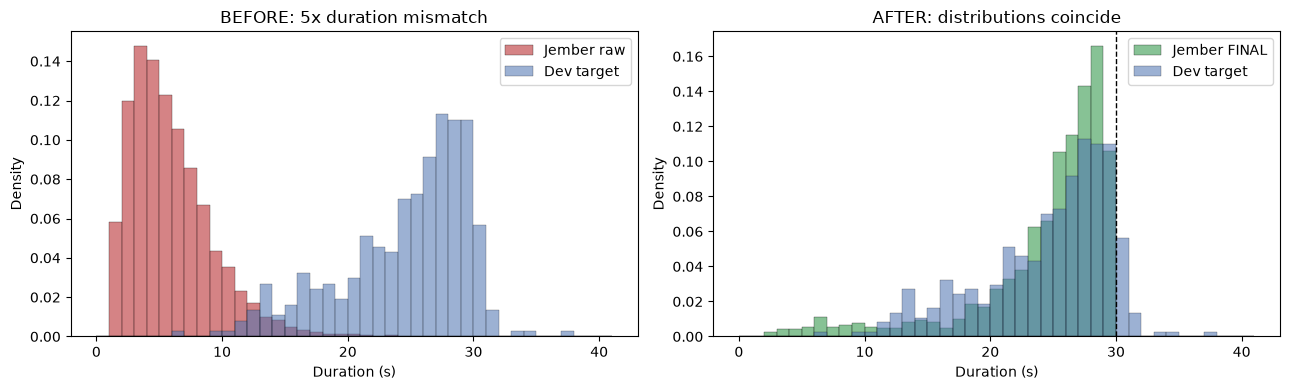


SIDE EFFECT CHECK -- did merging close the sentence-count gap on its own? (section 26b)
  utterances with >1 sentence-final mark:
    Jember raw segments :  14.8%
    Jember FINAL chunks :  95.9%
    Dev (target)        :  92.2%
  --> predicted in section 26b, confirmed here: the register gap WAS a segmentation artefact.


In [52]:
raw_dur    = jember_clean.duration_s
final_dur  = train_kept.duration_s
target_dur = dev_out.duration_s

print(f"  {'':22s} {'n':>6s} {'median':>8s} {'mean':>7s} {'p5':>7s} {'p95':>7s} {'in 15-32 s':>11s} {'>30 s':>7s}")
for name, s in [("Jember raw segments", raw_dur), ("Jember FINAL chunks", final_dur),
                ("Dev raw", dev_out.raw_duration_s), ("Dev FINAL (target)", target_dur)]:
    print(f"  {name:22s} {len(s):6d} {s.median():8.1f} {s.mean():7.1f} {s.quantile(.05):7.1f} "
          f"{s.quantile(.95):7.1f} {((s >= 15) & (s <= 32)).mean()*100:10.1f}% {(s > 30).sum():7d}")
print(f"\n  median gap to target: raw {abs(raw_dur.median() - target_dur.median()):.1f}s "
      f"-> final {abs(final_dur.median() - target_dur.median()):.1f}s")
print(f"  in-band share       : raw {((raw_dur>=15)&(raw_dur<=32)).mean()*100:.1f}% "
      f"-> final {((final_dur>=15)&(final_dur<=32)).mean()*100:.1f}%  (target {((target_dur>=15)&(target_dur<=32)).mean()*100:.1f}%)")
print(f"  chunks over Whisper's 30 s window: {(final_dur > 30).sum()}  (must be 0 after the gate)")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
bins = np.arange(0, 42, 1)
ax[0].hist(raw_dur, bins=bins, density=True, alpha=.7, color="#c44e52", edgecolor="k", lw=.3, label="Jember raw")
ax[0].hist(target_dur, bins=bins, density=True, alpha=.55, color="#4c72b0", edgecolor="k", lw=.3, label="Dev target")
ax[0].set_title("BEFORE: 5x duration mismatch"); ax[0].legend(); ax[0].set_xlabel("Duration (s)")
ax[1].hist(final_dur, bins=bins, density=True, alpha=.7, color="#55a868", edgecolor="k", lw=.3, label="Jember FINAL")
ax[1].hist(target_dur, bins=bins, density=True, alpha=.55, color="#4c72b0", edgecolor="k", lw=.3, label="Dev target")
ax[1].axvline(30, color="k", ls="--", lw=1)
ax[1].set_title("AFTER: distributions coincide"); ax[1].legend(); ax[1].set_xlabel("Duration (s)")
for a in ax: a.set_ylabel("Density")
plt.tight_layout(); plt.show()

print("\nSIDE EFFECT CHECK -- did merging close the sentence-count gap on its own? (section 26b)")
multi = lambda s: s.apply(lambda t: len(re.findall(r"[.!?]", t)) > 1).mean() * 100
print(f"  utterances with >1 sentence-final mark:")
print(f"    Jember raw segments : {multi(jem_raw):5.1f}%")
print(f"    Jember FINAL chunks : {multi(train_kept.text):5.1f}%")
print(f"    Dev (target)        : {multi(dev_out.text):5.1f}%")
print("  --> predicted in section 26b, confirmed here: the register gap WAS a segmentation artefact.")

## 44. Check 3 — text normalisation, before vs after

In [53]:
J_raw_v  = Counter(); [J_raw_v.update(toks(t)) for t in jember_clean.text]
J_fin_v  = Counter(); [J_fin_v.update(toks(t)) for t in train_kept.text]
D_v      = D_vocab
Dtot     = sum(D_v.values())

print("DEV TOKEN COVERAGE BY THE TRAINING VOCABULARY")
print(f"  {'training text':28s} {'types':>7s} {'dev coverage':>13s} {'dev OOV':>9s}")
for name, V in [("Jember RAW", J_raw_v), ("Jember FINAL (normalised)", J_fin_v)]:
    cov = sum(n for w, n in D_v.items() if w in V) / Dtot * 100
    print(f"  {name:28s} {len(V):7,d} {cov:12.2f}% {100-cov:8.2f}%")
gain = (sum(n for w, n in D_v.items() if w in J_fin_v) - sum(n for w, n in D_v.items() if w in J_raw_v)) / Dtot * 100
print(f"  --> {gain:+.2f} percentage points = {gain/100*Dtot:,.0f} dev tokens recovered")

print("\nCROSS-CORPUS SPELLING CONFLICTS REMAINING")
key = lambda w: strip_diacritics(w).lower()
def conflicts(V):
    gj, gd = defaultdict(Counter), defaultdict(Counter)
    for w, n in V.items(): gj[key(w)][w] += n
    for w, n in D_v.items(): gd[key(w)][w] += n
    out = [(k, gd[k].most_common(1)[0][1]) for k in gd
           if k in gj and gj[k].most_common(1)[0][0] != gd[k].most_common(1)[0][0]]
    return len(out), sum(n for _, n in out)
for name, V in [("Jember RAW", J_raw_v), ("Jember FINAL", J_fin_v)]:
    nk, nt = conflicts(V)
    print(f"  {name:14s} {nk:4d} conflicting words, {nt:5,d} dev tokens ({nt/Dtot*100:.2f}% of the denominator)")

print("\nSCORED DISTINCTIONS -- did normalisation destroy anything it should not have?")
checks = [
 ("ALL-CAPS acronym tokens", lambda s: sum(1 for t in s for w in t.split() if is_allcaps(w))),
 ("hyphenated tokens",       lambda s: sum(1 for t in s for w in t.split() if "-" in w.strip('.,?!"'))),
 ("word-attached ellipses",  lambda s: sum(len(re.findall(r"\S\.{3}", t)) for t in s)),
 ("apostrophes",             lambda s: sum(t.count("'") for t in s)),
]
print(f"  {'scored feature':26s} {'Jember raw':>11s} {'Jember final':>13s} {'delta':>8s}")
for name, fn in checks:
    a, b = fn(list(jem_raw)), fn(list(train_kept.text))
    print(f"  {name:26s} {a:11d} {b:13d} {b-a:+8d}")
print("  --> acronyms, hyphens, ellipses and apostrophes survive intact. Only combining marks and")
print("      Unicode punctuation were removed, which is exactly the intent.")

print("\nWHAT NORMALISATION COST US")
lost_e = sum(n for w, n in D_v.items() if "é" in w)
print(f"  dev tokens containing 'é' that we can now never emit: {lost_e} ({lost_e/Dtot*100:.2f}% of the denominator)")
print(f"  against {gain/100*Dtot:,.0f} tokens recovered -- net {gain/100*Dtot - lost_e:+,.0f} tokens.")

DEV TOKEN COVERAGE BY THE TRAINING VOCABULARY
  training text                  types  dev coverage   dev OOV
  Jember RAW                     7,890        78.63%    21.37%
  Jember FINAL (normalised)      7,677        81.53%    18.47%
  --> +2.90 percentage points = 506 dev tokens recovered

CROSS-CORPUS SPELLING CONFLICTS REMAINING
  Jember RAW      153 conflicting words, 1,055 dev tokens (6.04% of the denominator)
  Jember FINAL     39 conflicting words,    78 dev tokens (0.45% of the denominator)

SCORED DISTINCTIONS -- did normalisation destroy anything it should not have?
  scored feature              Jember raw  Jember final    delta


  ALL-CAPS acronym tokens            302           302       +0
  hyphenated tokens                 1961          1961       +0
  word-attached ellipses             766           770       +4
  apostrophes                        250           269      +19
  --> acronyms, hyphens, ellipses and apostrophes survive intact. Only combining marks and
      Unicode punctuation were removed, which is exactly the intent.

WHAT NORMALISATION COST US
  dev tokens containing 'é' that we can now never emit: 53 (0.30% of the denominator)
  against 506 tokens recovered -- net +453 tokens.


## 45. Check 4 — audio metrics, before vs after

In [54]:
print("JEMBER TRAINING CHUNKS -- BEFORE vs AFTER the audio contract")
pairs = [("RMS (dBFS)", "pre_rms_db", "rms_db"), ("SNR (dB)", "pre_snr_db", "snr_db"),
         ("silence fraction", "pre_silence", "silence_frac"),
         ("leading silence (s)", "pre_lead_s", "lead_sil_s"),
         ("trailing silence (s)", "pre_trail_s", "trail_sil_s")]
print(f"  {'metric':22s} {'':>6s} {'p5':>8s} {'median':>8s} {'p95':>8s} {'spread':>8s}")
for label, pre, post in pairs:
    for tag, col in [("before", pre), ("after ", post)]:
        s = train_kept[col]
        print(f"  {label if tag == 'before' else '':22s} {tag:>6s} {s.quantile(.05):8.2f} "
              f"{s.median():8.2f} {s.quantile(.95):8.2f} {s.quantile(.95)-s.quantile(.05):8.2f}")

print(f"\n  THE HEADLINE (R5): training-set RMS spread p5-p95")
print(f"    before {train_kept.pre_rms_db.quantile(.95)-train_kept.pre_rms_db.quantile(.05):5.1f} dB"
      f"   after {train_kept.rms_db.quantile(.95)-train_kept.rms_db.quantile(.05):5.1f} dB"
      f"   dev target {dev_out.rms_db.quantile(.95)-dev_out.rms_db.quantile(.05):5.1f} dB")
print(f"    full range before {train_kept.pre_rms_db.max()-train_kept.pre_rms_db.min():.1f} dB"
      f"  -> after {train_kept.rms_db.max()-train_kept.rms_db.min():.1f} dB")

print(f"\n  EDGE SILENCE (R8) -- matching dev's crop")
print(f"    {'':22s} {'lead median':>12s} {'trail median':>13s} {'lead>1s':>9s} {'hot onset':>10s}")
for name, df in [("Jember before", train_kept.rename(columns={'pre_lead_s':'l','pre_trail_s':'t'})),
                 ("Jember after ", train_kept.rename(columns={'lead_sil_s':'l','trail_sil_s':'t'})),
                 ("Dev after    ", dev_out.rename(columns={'lead_sil_s':'l','trail_sil_s':'t'}))]:
    print(f"    {name:22s} {df.l.median():12.2f} {df.t.median():13.2f} {int((df.l>1).sum()):9d} "
          f"{(df.l <= .01).mean()*100:9.1f}%")
print(f"    total audio removed by edge trimming: {(train.trim_lead_s + train.trim_trail_s).sum():.0f}s "
      f"({(train.trim_lead_s + train.trim_trail_s).sum()/train.raw_duration_s.sum()*100:.2f}% of Jember)")
print(f"\n  BOUNDARY REPAIR (R8) -- the metric padding exists to move")
print(f"    Jember chunks cut mid-word before padding : lead {train_kept.pre_lead_hot.mean()*100:5.1f}%  trail {train_kept.pre_trail_hot.mean()*100:5.1f}%")
print(f"    after padding + trimming                  : lead {(train_kept.lead_sil_s <= .01).mean()*100:5.1f}%  trail {(train_kept.trail_sil_s <= .01).mean()*100:5.1f}%")
print(f"    dev (target)                              : lead {(dev_out.lead_sil_s <= .01).mean()*100:5.1f}%  trail {(dev_out.trail_sil_s <= .01).mean()*100:5.1f}%")

print(f"\n  DAMAGE CHECK -- did loudness normalisation introduce clipping?")
print(f"    chunks with any sample at full scale after processing: {int((train_kept.clip_frac > 0).sum())}")
print(f"    max peak after processing: {train_kept.peak.max():.4f}  (ceiling {10**(CFG['peak_ceiling_dbfs']/20):.4f})")
print(f"    dev max peak after processing: {dev_out.peak.max():.4f}")
print(f"    gain applied: median {train_kept.gain_db.median():+.1f} dB, range {train_kept.gain_db.min():+.1f} to {train_kept.gain_db.max():+.1f} dB")
print(f"    NOTE: SNR is invariant to a scalar gain, so loudness normalisation cannot change it.")
print(f"    The pre/post SNR difference below is entirely a MEASUREMENT effect: the post floor is")
print(f"    re-estimated on the trimmed audio, and trimming removes its quietest frames.")
print(f"      median |SNR change|: {float((train_kept.snr_db - train_kept.pre_snr_db).abs().median()):.2f} dB; "
      f"chunks moving >3 dB: {int((train_kept.snr_db - train_kept.pre_snr_db).abs().gt(3).sum())}")
print(f"      correlation with seconds trimmed: "
      f"{float(np.corrcoef((train_kept.pre_snr_db - train_kept.snr_db), (train_kept.trim_lead_s + train_kept.trim_trail_s))[0,1]):.2f}"
      "   (positive = the trimming explains it)")

print(f"\n  DEV -- the contract must not damage the target either")
print(f"    RMS spread before {dev_out.pre_rms_db.max()-dev_out.pre_rms_db.min():.1f} dB -> after {dev_out.rms_db.max()-dev_out.rms_db.min():.1f} dB")
print(f"    audio removed from dev by edge trimming: {(dev_out.trim_lead_s + dev_out.trim_trail_s).sum():.0f}s "
      f"({(dev_out.trim_lead_s + dev_out.trim_trail_s).sum()/dev_out.raw_duration_s.sum()*100:.2f}%)")
print(f"    dev clips that lost more than 1.0 s in total: {int(((dev_out.trim_lead_s + dev_out.trim_trail_s) > 1).sum())}")
print(f"    dev words per SPEECH second: before {(dev_out.n_words/(dev_out.raw_duration_s*(1-dev_out.pre_silence))).median():.2f} "
      f"-> after {(dev_out.n_words/(dev_out.duration_s*dev_out.speech_frac)).median():.2f}")
print(f"    Jember words per SPEECH second after: {(train_kept.n_words/(train_kept.duration_s*train_kept.speech_frac)).median():.2f}")
print("    --> section 32 warned internal-VAD would widen this gap. Edge-only trimming leaves it")
print("        where it was, which is the intended outcome.")

JEMBER TRAINING CHUNKS -- BEFORE vs AFTER the audio contract
  metric                              p5   median      p95   spread
  RMS (dBFS)             before   -37.23   -26.20   -16.16    21.07
                         after    -27.13   -23.00   -23.00     4.13
  SNR (dB)               before    18.69    31.91    69.52    50.82
                         after     18.22    31.34    66.25    48.03
  silence fraction       before     0.09     0.34     0.64     0.55
                         after      0.11     0.35     0.64     0.53
  leading silence (s)    before     0.00     0.02     0.83     0.83
                         after      0.00     0.02     0.21     0.21
  trailing silence (s)   before     0.00     0.00     1.29     1.29
                         after      0.00     0.01     0.53     0.53

  THE HEADLINE (R5): training-set RMS spread p5-p95
    before  21.1 dB   after   4.1 dB   dev target   3.9 dB
    full range before 33.4 dB  -> after 12.0 dB

  EDGE SILENCE (R8) -- matchin

## 46. Check 5 — spot-check individual examples

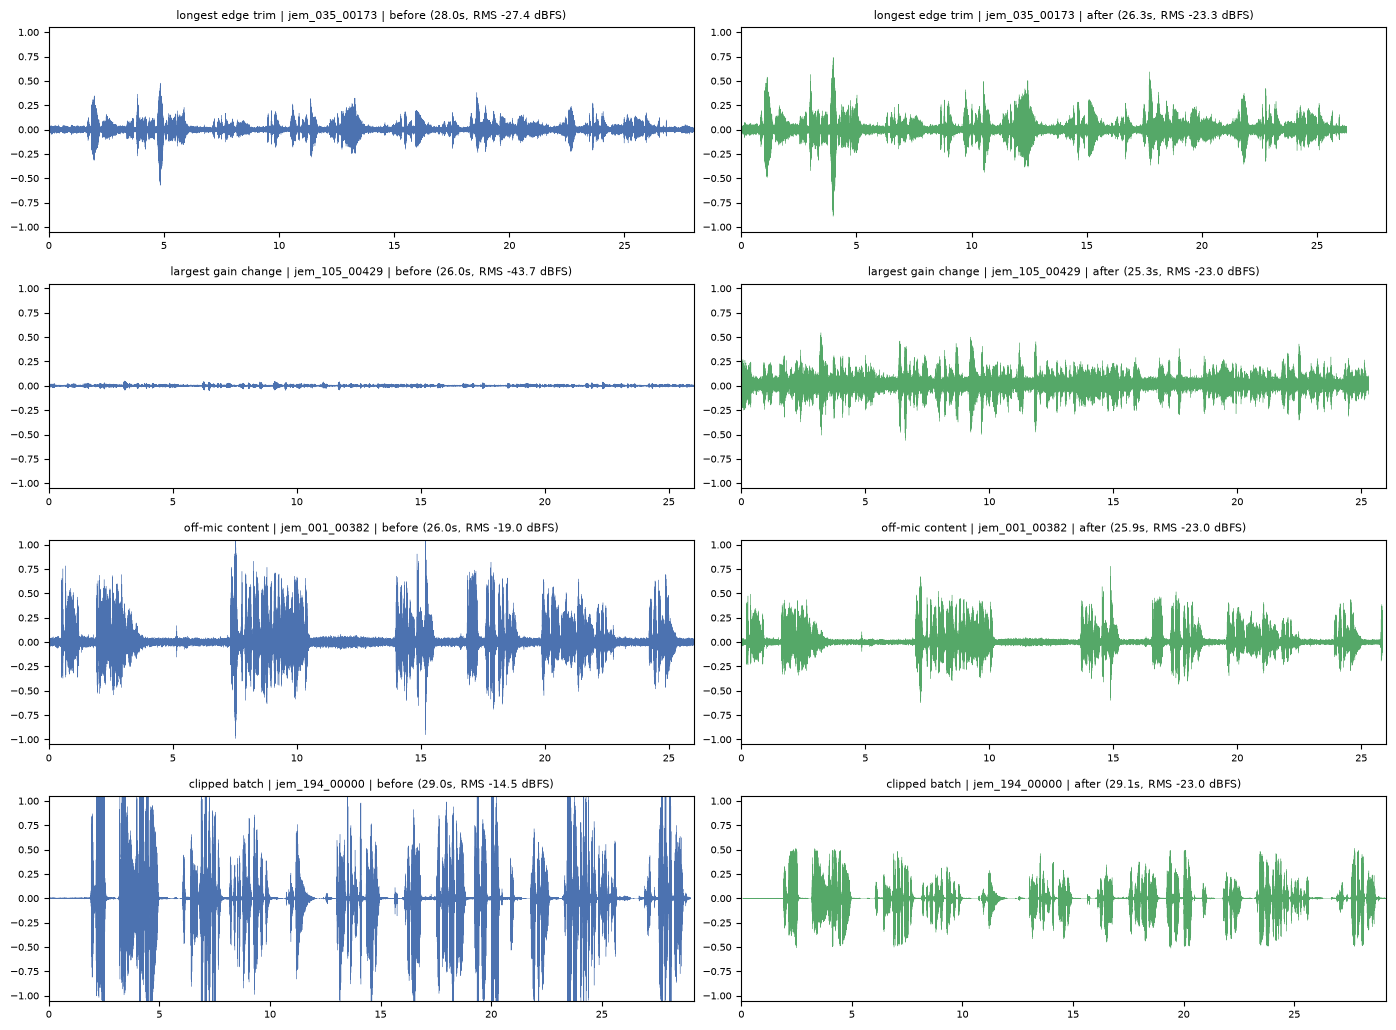

TRANSCRIPT DIFFS -- raw source segments vs the stored training target

  jem_001_00000  (12 segments, 27.2s)
    raw   : Oke. Bismillahirrahmanirrahim. Langsung ae ya, aja suwi-suwi. Soale aku sibuk. Nèngdi tempat wisata alam populer nèng Indonesia? Akèh sih. Indonesia w
    stored: Oke. Bismillahirrahmanirrahim. Langsung ae ya, aja suwi-suwi. Soale aku sibuk. Nengdi tempat wisata alam populer neng Indonesia? Akeh sih. Indonesia w
    changed tokens: [('Nèngdi', 'Nengdi'), ('nèng', 'neng'), ('Akèh', 'Akeh'), ('wakèh.', 'wakeh.'), ('akène.', 'akene.'), ('nèng', 'neng')]

  jem_001_00028  (5 segments, 26.5s)
    raw   : Nah, populer itu, sing populer iku, em, saiki lèk jarèku ya, lèk jarèku ya. Raja Ampat, Papua. Wah, iku..., sip iku, cek sip e. Jare kon, piye cara aw
    stored: Nah, populer itu, sing populer iku, em, saiki lek jareku ya, lek jareku ya. Raja Ampat, Papua. Wah, iku..., sip iku, cek sip e. Jare kon, piye cara aw
    changed tokens: [('lèk', 'lek'), ('jarèku', 'jareku'), (

In [55]:
picks = [
    ("longest edge trim",   train_kept.assign(x=train_kept.trim_lead_s + train_kept.trim_trail_s).x.idxmax()),
    ("largest gain change", train_kept.gain_db.abs().idxmax()),
    ("off-mic content",     (train_kept[train_kept.flag_offmic].index[0] if train_kept.flag_offmic.any() else train_kept.index[0])),
    ("clipped batch",       (train_kept[train_kept.flag_clipped_batch].index[0] if train_kept.flag_clipped_batch.any() else train_kept.index[1])),
]
fig, axes = plt.subplots(len(picks), 2, figsize=(14, 2.6 * len(picks)))
for ax_row, (why, idx) in zip(np.atleast_2d(axes), picks):
    r = train_kept.loc[idx]
    y_sess = decode(JEMBER_AUDIO / f"{int(r.session)}.mp3")
    raw = y_sess[int(r.src_start_s * SR_TARGET):int(r.src_end_s * SR_TARGET)]
    proc, _ = sf.read(OUT / r.path)
    for ax, (y, ttl) in zip(ax_row, [(raw, "before"), (proc, "after")]):
        ax.plot(np.arange(len(y)) / SR_TARGET, y, lw=.25, color="#4c72b0" if ttl == "before" else "#55a868")
        ax.set_ylim(-1.05, 1.05); ax.set_xlim(0, max(len(raw), len(proc)) / SR_TARGET)
        ax.set_title(f"{why} | {r.clip_id} | {ttl} ({len(y)/SR_TARGET:.1f}s, "
                     f"RMS {20*np.log10(max(np.sqrt(np.mean(y**2)),1e-10)):.1f} dBFS)", fontsize=8)
        ax.tick_params(labelsize=7)
plt.tight_layout(); plt.show()

print("TRANSCRIPT DIFFS -- raw source segments vs the stored training target")
shown = 0
for _, r in train_kept.iterrows():
    src = " ".join(jember_df.loc[chunks.loc[r.chunk_idx, "source_rows"], "text"].astype(str))
    if src != r.text:
        print(f"\n  {r.clip_id}  ({r.n_source_segs} segments, {r.duration_s:.1f}s)")
        print(f"    raw   : {src[:150]}")
        print(f"    stored: {r.text[:150]}")
        diff = [(a, b) for a, b in zip(src.split(), r.text.split()) if a != b][:6]
        print(f"    changed tokens: {diff}")
        shown += 1
    if shown >= 4: break

print("\n\nSANITY ASSERTIONS")
probe = train_kept.sample(min(40, len(train_kept)), random_state=0)
bad = []
for _, r in probe.iterrows():
    info = sf.info(str(OUT / r.path))
    if info.samplerate != CFG["sample_rate"]: bad.append((r.clip_id, "sample rate"))
    if info.channels != 1:                    bad.append((r.clip_id, "channels"))
    if abs(info.frames / info.samplerate - r.duration_s) > 0.02: bad.append((r.clip_id, "duration mismatch"))
    if not r.text.strip():                    bad.append((r.clip_id, "empty text"))
print(f"  40 random chunks re-opened from disk: {len(bad)} problems {bad}")
print(f"  every training file is 16 kHz mono FLAC : {not bad}")
print(f"  no chunk exceeds Whisper's 30 s window  : {bool((train_kept.duration_s <= 30).all())}")
print(f"  no combining marks left in training text: "
      f"{not any(unicodedata.category(c) == 'Mn' for t in train_kept.text for c in unicodedata.normalize('NFD', t))}")
print(f"  no unicode punctuation left             : "
      f"{not any(ch in t for t in train_kept.text for ch in UNICODE_PUNCT_MAP)}")
print(f"  dev reference text untouched            : "
      f"{bool((dev_out.sort_values('audio_filename').text.values == dev_df.sort_values('audio_filename').transcript.values).all())}")

## 47. Check 6 — what preprocessing did **not** fix

Recording this explicitly matters more than the wins. Everything below is a live risk going into
model training, and none of it is addressable by data preparation.

In [56]:
J_fin = Counter(); [J_fin.update(toks(t)) for t in train_kept.text]
oov_final = 100 - sum(n for w, n in D_vocab.items() if w in J_fin) / sum(D_vocab.values()) * 100
ind_oov   = 100 - sum(n for w, n in by_lang["ind"].items() if w in J_fin) / sum(by_lang["ind"].values()) * 100
jav_share_train = np.mean([p["jav_share"] for t in train_kept.text if (p := switch_profile(t))])
run_train       = np.mean([p["mean_run"]  for t in train_kept.text if (p := switch_profile(t))])
def _multi(ci):
    v = [rms_by_row[i] for i in chunks.loc[ci, "source_rows"] if i in rms_by_row]
    return len(v) > 1 and float(np.abs(np.diff(v)).max()) > CFG["turn_step_db"]
multi_sp = float(train_kept.chunk_idx.map(_multi).mean()) * 100

unfixed = [
 ("R2  lexical gap",            f"dev OOV still {oov_final:.1f}% ({ind_oov:.1f}% on `ind` clips)",
  "No Indonesian conversational data was added. This is the ceiling, and it is a DATA problem."),
 ("R3  switching granularity",  f"training run length {run_train:.2f} tokens vs dev {dev_cs.mean_run.mean():.2f}",
  "Structural. Mitigate with LoRA / low LR / few epochs, and watch `ind` WER as the guard-rail."),
 ("R3b matrix language",        f"training Javanese share {jav_share_train:.2f} vs dev {dev_cs.jav_share.mean():.2f}",
  "Same cause, same fix. Do not train on Jember alone."),
 ("R7  multi-speaker chunks",   f"{multi_sp:.1f}% of shipped chunks contain a >6 dB level step; dev is 0%",
  "Turn-aware boundaries are written to meta/ but not shipped. Needs a training run to decide."),
 ("R9  unseen acronyms",        f"{len(set(ac_d) - set(ac_j))} of dev's {len(ac_d)} acronym types never occur in training",
  "A post-ASR recaser over a closed acronym set is the only real lever, and must be dev-validated."),
 ("R14 digits",                 f"{sum(v for k, v in cj.items() if k.isdigit())} digit characters remain in training text; dev has 0",
  "No attested Jember-digit -> dev-word mapping exists. Left alone deliberately."),
 ("R16 short clips",            "nothing in dev is under 6.29 s, but the spec advertises 2 s",
  "Unvalidatable locally. Test the inference path on synthetic short clips."),
 ("--  no `jav` dev data",      "0 Javanese-only clips exist",
  "Javanese-only WER cannot be measured. Any claim about it is speculation."),
 ("--  dev is 4 speakers",      f"{dev_df.speaker.nunique()} speakers, {dev_df.convo_id.nunique()} conversations, 1 WER pt = {sum(D_vocab.values())/100:.0f} word errors",
  "Bootstrap every comparison. Treat sub-point moves as noise."),
]
W = 100
print("=" * W); print("WHAT PREPROCESSING DID NOT FIX".center(W)); print("=" * W)
for tag, measured, note in unfixed:
    print(f"\n  {tag}")
    print(f"    measured : {measured}")
    print(f"    note     : {note}")
print("\n" + "=" * W)
print("Full write-up, sources and trade-offs: Preprocess.md")

                                   WHAT PREPROCESSING DID NOT FIX                                   

  R2  lexical gap
    measured : dev OOV still 18.5% (21.5% on `ind` clips)
    note     : No Indonesian conversational data was added. This is the ceiling, and it is a DATA problem.

  R3  switching granularity
    measured : training run length 3.41 tokens vs dev 7.22
    note     : Structural. Mitigate with LoRA / low LR / few epochs, and watch `ind` WER as the guard-rail.

  R3b matrix language
    measured : training Javanese share 0.76 vs dev 0.18
    note     : Same cause, same fix. Do not train on Jember alone.

  R7  multi-speaker chunks
    measured : 20.6% of shipped chunks contain a >6 dB level step; dev is 0%
    note     : Turn-aware boundaries are written to meta/ but not shipped. Needs a training run to decide.

  R9  unseen acronyms
    measured : 18 of dev's 27 acronym types never occur in training
    note     : A post-ASR recaser over a closed acronym set is the onl

## 48. Handoff

`processed/v1/` is complete and validated. `manifest.json` carries the full configuration, the
stage-by-stage row accounting and the `known_unfixed` list, so any later run can be compared to
this one exactly.

**This notebook stops here by design.** No model is loaded, fine-tuned or run. The next step is
Phase 2 of `COMPETITION_ANALYSIS.md` — a zero-shot baseline with correct long-form decoding —
which must happen before any fine-tune, because it is the only way to detect that fine-tuning has
*hurt* Indonesian.

Read `Preprocess.md` first: it records why each stage was chosen over its alternatives, the
research the choices were checked against, and the specific list of things that cannot be validated
without a trained model in the loop.